# Tennis Match Outcome Predictor

This project builds a machine learning model to predict the probability of victory for tennis players in head-to-head matchups. Using historical match data from 2000-2025, the model analyzes player performance metrics, surface preferences, recent form, and head-to-head records to generate win probability estimates.

## Project Overview

**Objective:** Develop a predictive model that can estimate match outcome probabilities between any two players given match context (surface, tournament level, current form).

**Approach:** Gradient boosting models (XGBoost/LightGBM) applied to engineered features from historical match data.

**Key Components:**
- Feature engineering from player statistics and match history
- Time-based train/validation/test split to simulate real-world prediction
- Model evaluation focused on prediction accuracy and calibration
- Deployment interface for real-time match predictions

**Source**

All the matches were obtained from the following website https://stats.tennismylife.org/ 

## Load libraries

In [204]:
import pandas as pd
import numpy as np
from datetime import datetime,timedelta
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import xgboost as xgb
from sklearn.model_selection import train_test_split
from collections import defaultdict
from sklearn.model_selection import GridSearchCV
from tqdm import tqdm
import time
import warnings
warnings.filterwarnings('ignore')
import statsmodels.api as sm
import os
from statsmodels.stats.outliers_influence import variance_inflation_factor


## Load data
To extract all the files from the source you need to run the following command if you are using Linux/Bash. If you are not, you can check their documentation to see the alternatives. 

In [205]:
# mkdir -p tml-data && curl -s 'https://stats.tennismylife.org/api/data-files' 
# | jq -r '.files[] | "\(.url)\t\(.name)"' | while IFS=$'\t' read -r url name; do curl -sSL "$url"
#  -o "tml-data/$name"; done

In [206]:
# Delete unwanted files from tml-data
for filename in os.listdir("./tml-data"):
    filepath = os.path.join("./tml-data", filename)
    # Delete challenger files and pre-2000 files
    if "_challenger" in filename or "_challenge" in filename:
        os.remove(filepath)
    else:
        try:
            year = int(filename.replace(".csv", ""))
            if year < 2000:
                os.remove(filepath)
        except ValueError:
            pass  # Skip non-year files (ATP_Database.csv, ongoing_tourneys.csv, etc.)

# Load each year's data (ATP main tour only, 2000-2025)
dfs = []
for year in range(2000, 2026):
    df_year = pd.read_csv(f"./tml-data/{year}.csv")
    dfs.append(df_year)

# Concatenate all DataFrames
df = pd.concat(dfs, ignore_index=True)

print(f"Total matches loaded: {len(df)}")

Total matches loaded: 77954


### Examination of sample data

In [207]:
df.head().to_csv("sample_data.csv", index=False)

In [208]:
# Save raw df for database stats loading
df.to_pickle('db_migration/df_raw.pkl')
print(f"✓ Saved df_raw.pkl: {len(df):,} matches")
print(f"  Columns: {df.columns.tolist()}")

✓ Saved df_raw.pkl: 77,954 matches
  Columns: ['tourney_id', 'tourney_name', 'surface', 'draw_size', 'tourney_level', 'indoor', 'tourney_date', 'match_num', 'winner_id', 'winner_seed', 'winner_entry', 'winner_name', 'winner_hand', 'winner_ht', 'winner_ioc', 'winner_age', 'winner_rank', 'winner_rank_points', 'loser_id', 'loser_seed', 'loser_entry', 'loser_name', 'loser_hand', 'loser_ht', 'loser_ioc', 'loser_age', 'loser_rank', 'loser_rank_points', 'score', 'best_of', 'round', 'minutes', 'w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon', 'w_2ndWon', 'w_SvGms', 'w_bpSaved', 'w_bpFaced', 'l_ace', 'l_df', 'l_svpt', 'l_1stIn', 'l_1stWon', 'l_2ndWon', 'l_SvGms', 'l_bpSaved', 'l_bpFaced']


## Glossary of original df
## Column Glossary

### Tournament & Match Metadata
| Column | Description |
|--------|-------------|
| `tourney_id` | Unique tournament identifier (format: YYYY-NNNN) |
| `tourney_name` | Tournament name (e.g. "Wimbledon") |
| `surface` | Court surface: Hard, Clay, Grass, Carpet |
| `draw_size` | Number of players in the draw (e.g. 32, 64, 128) |
| `tourney_level` | Tournament tier: G (Grand Slam), M (Masters), A (ATP 500/250), D (Davis Cup) |
| `indoor` | Whether the match was played indoors (I) or outdoors (O) |
| `tourney_date` | Tournament start date (format: YYYYMMDD) |
| `match_num` | Match number within the tournament |
| `best_of` | Maximum sets: 3 (most tournaments) or 5 (Grand Slams) |
| `round` | Round: R128, R64, R32, R16, QF, SF, F |
| `minutes` | Match duration in minutes |
| `score` | Final score (e.g. "6-3 7-5") |

### Player Info (Winner & Loser)
| Column | Description |
|--------|-------------|
| `winner/loser_id` | TML player identifier (e.g. "F324") |
| `winner/loser_name` | Full player name |
| `winner/loser_seed` | Tournament seeding (NaN if unseeded) |
| `winner/loser_entry` | Entry type: WC (wildcard), Q (qualifier), LL (lucky loser), PR (protected ranking) |
| `winner/loser_hand` | Dominant hand: R (right), L (left) |
| `winner/loser_ht` | Player height in cm |
| `winner/loser_ioc` | Country code (IOC format, e.g. "ESP") |
| `winner/loser_age` | Player age at time of match |
| `winner/loser_rank` | ATP ranking at time of match |
| `winner/loser_rank_points` | ATP ranking points at time of match |

### Match Statistics (Winner = w_, Loser = l_)
| Column | Description |
|--------|-------------|
| `w/l_ace` | Number of aces served |
| `w/l_df` | Number of double faults |
| `w/l_svpt` | Total serve points played |
| `w/l_1stIn` | Number of first serves in |
| `w/l_1stWon` | First serve points won |
| `w/l_2ndWon` | Second serve points won |
| `w/l_SvGms` | Serve games played |
| `w/l_bpSaved` | Break points saved |
| `w/l_bpFaced` | Break points faced |


## EDA

In [209]:
# Show all columns for a random sample
pd.set_option('display.max_columns', None)
df.sample(5)

,tourney_id,tourney_name,surface,draw_size,tourney_level,indoor,tourney_date,match_num,winner_id,winner_seed,winner_entry,winner_name,winner_hand,winner_ht,winner_ioc,winner_age,winner_rank,winner_rank_points,loser_id,loser_seed,loser_entry,loser_name,loser_hand,loser_ht,loser_ioc,loser_age,loser_rank,loser_rank_points,score,best_of,round,minutes,w_ace,w_df,w_svpt,w_1stIn,w_1stWon,w_2ndWon,w_SvGms,w_bpSaved,w_bpFaced,l_ace,l_df,l_svpt,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced
45137,2014-404,Indian Wells Masters,Hard,96.0,M,O,20140306,66.0,F510,13.0,NaN,Fabio Fognini,R,178.0,ITA,26.784,14.0,2230.0,MC65,23.0,NaN,Gael Monfils,R,193.0,FRA,27.510,25.0,1475.0,6-2 3-6 7-5,3,R32,110.0,1.0,3.0,81.0,39.0,26.0,21.0,14.0,6.0,11.0,8.0,10.0,100.0,51.0,32.0,18.0,15.0,6.0,13.0
70348,2023-520,Roland Garros,Clay,128.0,G,O,20230529,13.0,SM37,NaN,NaN,Diego Schwartzman,R,170.0,ARG,30.782,95.0,660.0,Z419,32.0,NaN,Bernabe Zapata Miralles,R,183.0,ESP,26.374,38.0,1051.0,1-6 6-7(5) 6-2 6-0 6-4,5,R128,218.0,2.0,3.0,144.0,106.0,64.0,19.0,21.0,6.0,13.0,3.0,1.0,141.0,97.0,59.0,14.0,22.0,12.0,23.0
76420,2025-520,Roland Garros,Clay,128.0,G,O,20250526,61.0,M0CI,NaN,NaN,Fabian Marozsan,R,193.0,HUN,25.632,56.0,990.0,N0BG,NaN,NaN,Luca Nardi,R,185.0,ITA,21.804,95.0,645.0,6-2 6-3 7-6(3),5,R128,NaN,0.0,2.0,88.0,51.0,38.0,27.0,15.0,4.0,5.0,5.0,8.0,106.0,66.0,44.0,19.0,14.0,13.0,17.0
59091,2019-891,Pune,Hard,28.0,250,O,20181231,20.0,A678,1.0,NaN,Kevin Anderson,R,203.0,RSA,32.621,6.0,4710.0,DB63,NaN,NaN,Laslo Djere,R,188.0,SRB,23.581,93.0,621.0,7-6(3) 7-6(6),3,R16,128.0,20.0,2.0,81.0,54.0,44.0,16.0,12.0,1.0,2.0,6.0,4.0,99.0,63.0,47.0,16.0,12.0,6.0,7.0
21393,2006-500,Halle,Grass,32.0,250,O,20060612,28.0,BA47,5.0,NaN,Tomas Berdych,R,196.0,CZE,20.734,15.0,1505.0,S424,NaN,NaN,Fabrice Santoro,R,178.0,FRA,33.506,49.0,777.0,7-5 7-6(3),3,QF,110.0,7.0,0.0,69.0,44.0,36.0,16.0,12.0,1.0,2.0,9.0,2.0,101.0,62.0,43.0,18.0,12.0,9.0,11.0


In [210]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77954 entries, 0 to 77953
Data columns (total 50 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tourney_id          77954 non-null  object 
 1   tourney_name        77954 non-null  object 
 2   surface             77811 non-null  object 
 3   draw_size           77911 non-null  float64
 4   tourney_level       77954 non-null  object 
 5   indoor              71079 non-null  object 
 6   tourney_date        77954 non-null  int64  
 7   match_num           77465 non-null  float64
 8   winner_id           77954 non-null  object 
 9   winner_seed         32251 non-null  float64
 10  winner_entry        9690 non-null   object 
 11  winner_name         77954 non-null  object 
 12  winner_hand         77291 non-null  object 
 13  winner_ht           76420 non-null  float64
 14  winner_ioc          77952 non-null  object 
 15  winner_age          77886 non-null  float64
 16  winn

In [211]:
print(f'Missing value in data = {df.isnull().sum()}')

Missing value in data = tourney_id                0
tourney_name              0
surface                 143
draw_size                43
tourney_level             0
indoor                 6875
tourney_date              0
match_num               489
winner_id                 0
winner_seed           45703
winner_entry          68264
winner_name               0
winner_hand             663
winner_ht              1534
winner_ioc                2
winner_age               68
winner_rank             632
winner_rank_points      632
loser_id                  0
loser_seed            60063
loser_entry           62329
loser_name                0
loser_hand             1555
loser_ht               3030
loser_ioc                10
loser_age               226
loser_rank             1569
loser_rank_points      1569
score                     2
best_of                   0
round                     0
minutes                7236
w_ace                  6422
w_df                   6422
w_svpt                 6

In [212]:
print(f'Duplicated data : {df.duplicated().sum()}')

Duplicated data : 0


In [213]:
pd.set_option('display.max_columns', None)
df.describe()

,draw_size,tourney_date,match_num,winner_seed,winner_ht,winner_age,winner_rank,winner_rank_points,loser_seed,loser_ht,loser_age,loser_rank,loser_rank_points,best_of,minutes,w_ace,w_df,w_svpt,w_1stIn,w_1stWon,w_2ndWon,w_SvGms,w_bpSaved,w_bpFaced,l_ace,l_df,l_svpt,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced
count,77911.000000,7.795400e+04,77465.000000,32251.000000,76420.000000,77886.000000,77322.000000,77322.000000,17891.000000,74924.000000,77728.000000,76385.000000,76385.000000,77954.000000,70718.000000,71532.000000,71532.000000,71532.000000,71532.000000,71532.000000,71531.000000,71531.000000,71531.000000,71531.000000,71531.000000,71531.000000,71531.000000,71531.000000,71531.000000,71531.000000,71531.000000,71531.000000,71531.000000
mean,55.016596,2.012068e+07,26.860156,7.442405,186.310691,26.343202,79.804493,1620.840136,8.992622,185.698761,26.471603,117.955606,986.519395,3.449881,107.545151,6.939370,2.635086,78.025247,48.117961,36.402687,16.586054,12.390558,3.461324,5.027848,5.147670,3.347709,81.074038,48.737876,32.561533,14.913897,12.185905,4.770869,8.589646
std,40.263417,7.551777e+04,27.278736,6.854727,7.047147,3.984303,139.541548,2012.823389,7.439854,6.984651,4.095960,188.063808,1130.528909,0.835091,40.950053,5.506309,2.285875,29.200808,18.973382,13.585000,6.970511,4.322906,3.070862,4.022074,4.870461,2.529855,29.153736,19.228280,14.375843,7.175444,4.323155,3.267839,4.144000
min,2.000000,2.000010e+07,1.000000,1.000000,155.000000,14.940000,1.000000,1.000000,1.000000,155.000000,14.527000,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32.000000,2.005102e+07,8.000000,3.000000,183.000000,23.431500,18.000000,580.000000,4.000000,180.000000,23.507000,36.000000,434.000000,3.000000,77.000000,3.000000,1.000000,57.000000,34.000000,27.000000,12.000000,9.000000,1.000000,2.000000,2.000000,2.000000,60.000000,35.000000,22.000000,10.000000,9.000000,2.000000,6.000000
50%,32.000000,2.012022e+07,19.000000,5.000000,185.000000,26.130000,45.000000,945.000000,7.000000,185.000000,26.300000,68.000000,715.000000,3.000000,100.000000,6.000000,2.000000,73.000000,45.000000,34.000000,16.000000,11.000000,3.000000,4.000000,4.000000,3.000000,76.000000,45.000000,30.000000,14.000000,11.000000,4.000000,8.000000
75%,64.000000,2.018083e+07,33.000000,9.000000,191.000000,28.975000,85.750000,1748.000000,12.000000,191.000000,29.216000,114.000000,1115.000000,3.000000,130.000000,9.000000,4.000000,94.000000,58.000000,44.000000,20.000000,15.000000,5.000000,7.000000,7.000000,5.000000,97.000000,59.000000,40.000000,19.000000,15.000000,7.000000,11.000000
max,128.000000,2.025122e+07,127.000000,35.000000,211.000000,44.624000,2100.000000,16950.000000,35.000000,211.000000,44.060000,2159.000000,16950.000000,5.000000,665.000000,113.000000,26.000000,491.000000,361.000000,292.000000,82.000000,90.000000,24.000000,30.000000,103.000000,26.000000,489.000000,328.000000,284.000000,101.000000,91.000000,27.000000,38.000000


### Initial Findings from Summary Statistics

Several patterns emerge from the descriptive statistics, some expected and others requiring attention:

**Expected patterns:**
- **Best of format (mean ≈ 3.45):** Confirms Best of 3 dominates, with Grand Slams using Best of 5.
- **Winner rank < Loser rank (mean 79 vs 117):** Higher-ranked players win more often, as expected.
- **Match duration (mean ≈ 107 min):** Reasonable for ATP matches across surfaces.

**Anomalies requiring investigation:**

- **Max age 44.6 years:** Plausible (Fabrice Santoro retired at 37, but some players have competed older). Worth checking which player this is.
- **Winner rank max = 2100, Loser rank max = 2159:** Very low-ranked players appearing in ATP main draw — likely via wildcards or qualifying. Not an error but worth being aware of for feature engineering.
- **~8% missing serve stats (w_ace, l_ace, etc.):** About 6,400 matches have no serve statistics. These are mostly older matches (pre-2003 era). Won't affect model training if we handle NaN properly.
- **Minutes = 0 minimum:** At least one match recorded as 0 minutes — likely a walkover or retirement. Should be filtered or flagged.

I'll investigate these anomalies in the data cleaning phase.

### Categorical Data: Graphical Representation
Variables analyzed: Surface, Round, Best Of, Indoor/Outdoor

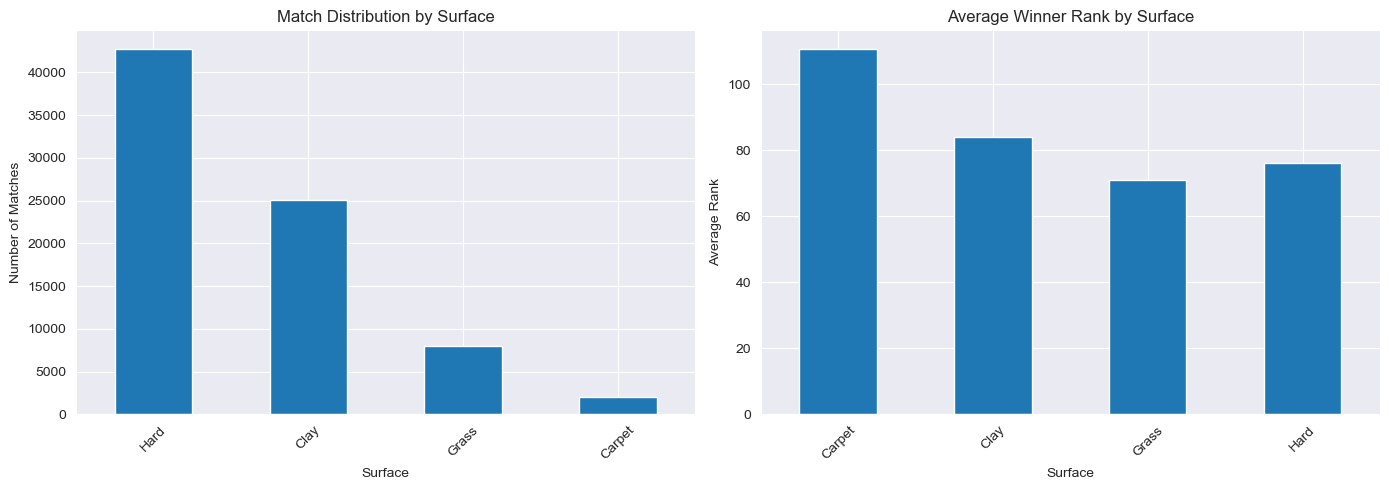

In [214]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Match distribution by surface
df['surface'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Match Distribution by Surface')
axes[0].set_xlabel('Surface')
axes[0].set_ylabel('Number of Matches')
axes[0].tick_params(axis='x', rotation=45)

# 2. Average winner rank by surface
df.groupby('surface')['winner_rank'].mean().plot(kind='bar', ax=axes[1])
axes[1].set_title('Average Winner Rank by Surface')
axes[1].set_xlabel('Surface')
axes[1].set_ylabel('Average Rank')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Surface Analysis

Hard court dominates the calendar (Australian Open, US Open, Masters 1000s). Grass is the shortest season. Carpet was phased out around 2009.

Carpet and Clay show higher average winner ranks (lower-ranked players winning more often). On clay, South American specialists thrive during their home swing. Carpet was generally considered the fastest, lowest-bouncing tennis surface, often faster than grass. Which was ideal for fast serve and volley specialists. Both patterns reinforce the need for surface-specific features in the model.

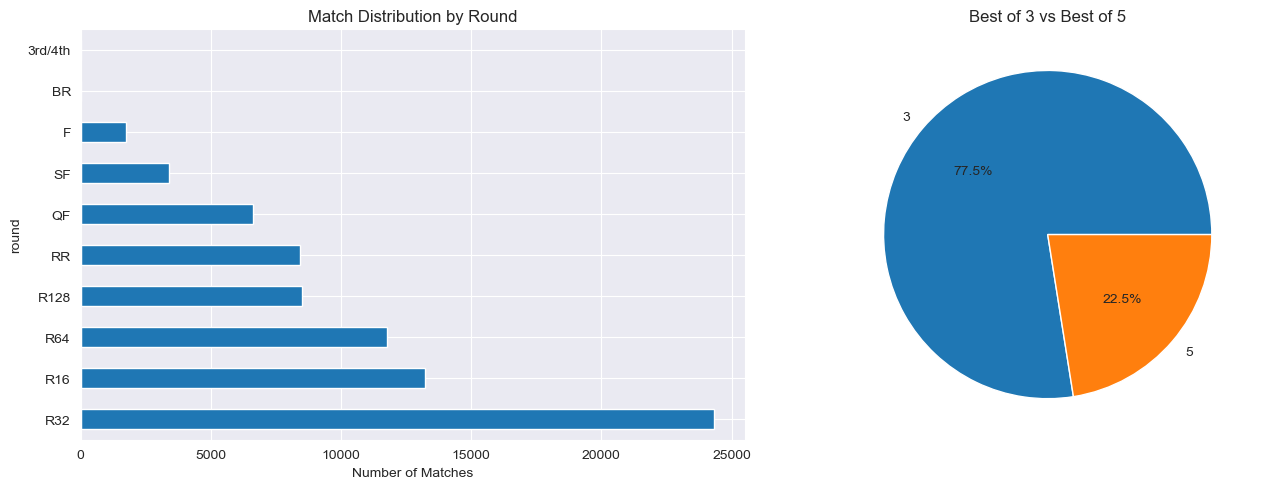

In [215]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['round'].value_counts().plot(kind='barh', ax=axes[0])
axes[0].set_title('Match Distribution by Round')
axes[0].set_xlabel('Number of Matches')

df['best_of'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
axes[1].set_title('Best of 3 vs Best of 5')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

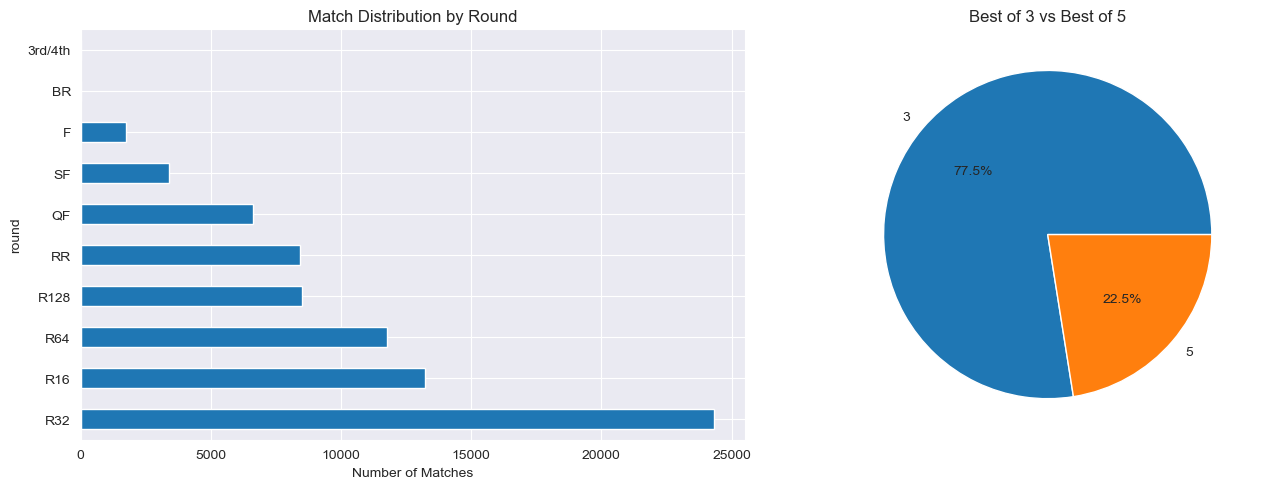

In [216]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 3. Round distribution
df['round'].value_counts().plot(kind='barh', ax=axes[0])
axes[0].set_title('Match Distribution by Round')
axes[0].set_xlabel('Number of Matches')

# 4. Best of distribution
df['best_of'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
axes[1].set_title('Best of 3 vs Best of 5')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

#### Round Distribution

Expected elimination structure — match counts decrease as rounds advance. Notable exceptions: R128 appears only in Grand Slams (128-player draws), and RR (Round Robin) is broader than expected — it covers the ATP Finals, team events (ATP Cup, Laver Cup, World Team Cup), Davis Cup, and some historical 250-level tournaments.

These RR matches introduce different dynamics (no elimination pressure, team context) and may warrant a flag during feature engineering.

#### Best of 5 vs Best of 3

77.5% Best of 3, 22.5% Best of 5. The Best of 5 share is higher than the 4 Grand Slams alone would suggest — Davis Cup and some team events also use this format. Match format should be encoded as a feature since longer matches favor different player attributes (endurance, consistency).

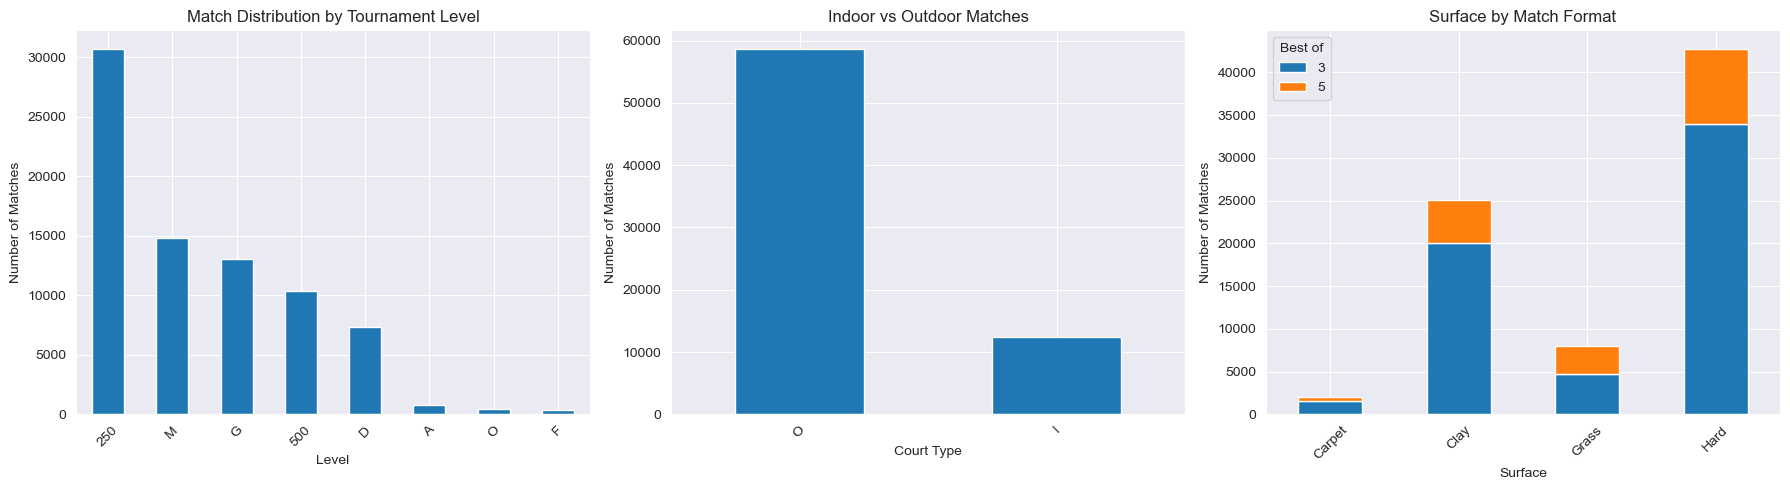

In [217]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 5. Tournament level distribution
df['tourney_level'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Match Distribution by Tournament Level')
axes[0].set_xlabel('Level')
axes[0].set_ylabel('Number of Matches')
axes[0].tick_params(axis='x', rotation=45)

# 6. Indoor vs Outdoor
df['indoor'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Indoor vs Outdoor Matches')
axes[1].set_xlabel('Court Type')
axes[1].set_ylabel('Number of Matches')
axes[1].tick_params(axis='x', rotation=45)

# 7. Surface x Format
pd.crosstab(df['surface'], df['best_of']).plot(kind='bar', stacked=True, ax=axes[2])
axes[2].set_title('Surface by Match Format')
axes[2].set_xlabel('Surface')
axes[2].set_ylabel('Number of Matches')
axes[2].legend(title='Best of')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Series, Court Type, and Surface × Format

The remaining visualizations confirm expected tournament calendar patterns with no anomalies detected. Series distribution, court type split, and the surface-format relationship all align with ATP tour structure.

### Outlier Detection
Investigating anomalies identified during EDA: age outliers.

#### Investigating Age numbers Anomaly

During initial data exploration, I identified an inconsistency: The descriptive statistics showed a maximum age of 44.6 — plausible but worth verifying — and a minimum of 14.9. TML provides age at match time directly, so any outliers here are source data issues, not merge errors.

In [218]:
print("="*60)
print("INVESTIGATING AGE OUTLIERS")
print("="*60)

# Check extremes
young_winners = df[df['winner_age'] < 15][['tourney_date', 'winner_name', 'loser_name', 'winner_age', 'tourney_name']]
old_winners   = df[df['winner_age'] > 50][['tourney_date', 'winner_name', 'loser_name', 'winner_age', 'tourney_name']]
young_losers  = df[df['loser_age']  < 15][['tourney_date', 'winner_name', 'loser_name', 'loser_age',  'tourney_name']]
old_losers    = df[df['loser_age']  > 50][['tourney_date', 'winner_name', 'loser_name', 'loser_age',  'tourney_name']]

for label, subset in [('Winners < 15', young_winners), ('Winners > 50', old_winners),
                       ('Losers < 15',  young_losers),  ('Losers > 50',  old_losers)]:
    print(f"\n{label}: {len(subset)} cases")
    if len(subset) > 0:
        print(subset.head(10))

# Age distribution by bucket
age_bins   = [0, 15, 20, 25, 30, 35, 40, 45, 50, 100]
age_labels = ['<15', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50+']

print("\nWinner age distribution:")
print(pd.cut(df['winner_age'], bins=age_bins, labels=age_labels).value_counts().sort_index())
print("\nLoser age distribution:")
print(pd.cut(df['loser_age'], bins=age_bins, labels=age_labels).value_counts().sort_index())

INVESTIGATING AGE OUTLIERS

Winners < 15: 1 cases
       tourney_date  winner_name      loser_name  winner_age  \
57059      20180407  Holger Rune  Youssef Hossam       14.94   

                      tourney_name  
57059  Davis Cup G2 R2: EGY vs DEN  

Winners > 50: 0 cases

Losers < 15: 2 cases
       tourney_date  winner_name                        loser_name  loser_age  \
14063      20040409  Julio Silva  Daniel-Alejandro Lopez Cassaccia     14.768   
56443      20180203  Jurgen Zopp               Ainius Sabaliauskas     14.527   

                      tourney_name  
14063  Davis Cup G1 R2: BRA vs PAR  
56443  Davis Cup G2 R1: EST vs LTU  

Losers > 50: 0 cases

Winner age distribution:
winner_age
<15          1
15-19     3338
20-24    27226
25-29    33208
30-34    12322
35-39     1765
40-44       26
45-49        0
50+          0
Name: count, dtype: int64

Loser age distribution:
loser_age
<15          2
15-19     3866
20-24    25645
25-29    32944
30-34    13326
35-39     1888
40

##### Resolution: No corrections needed

Only 3 matches involve players under 15, all legitimate Davis Cup appearances (notably Holger Rune at age 14.94). No players over 50. TML's match-time age data is clean — this is a non-issue compared to the previous data source.

#### Outlier Detection Through Visual Analysis

Boxplot analysis across rankings, ATP points, age, and serve statistics to identify data quality issues.

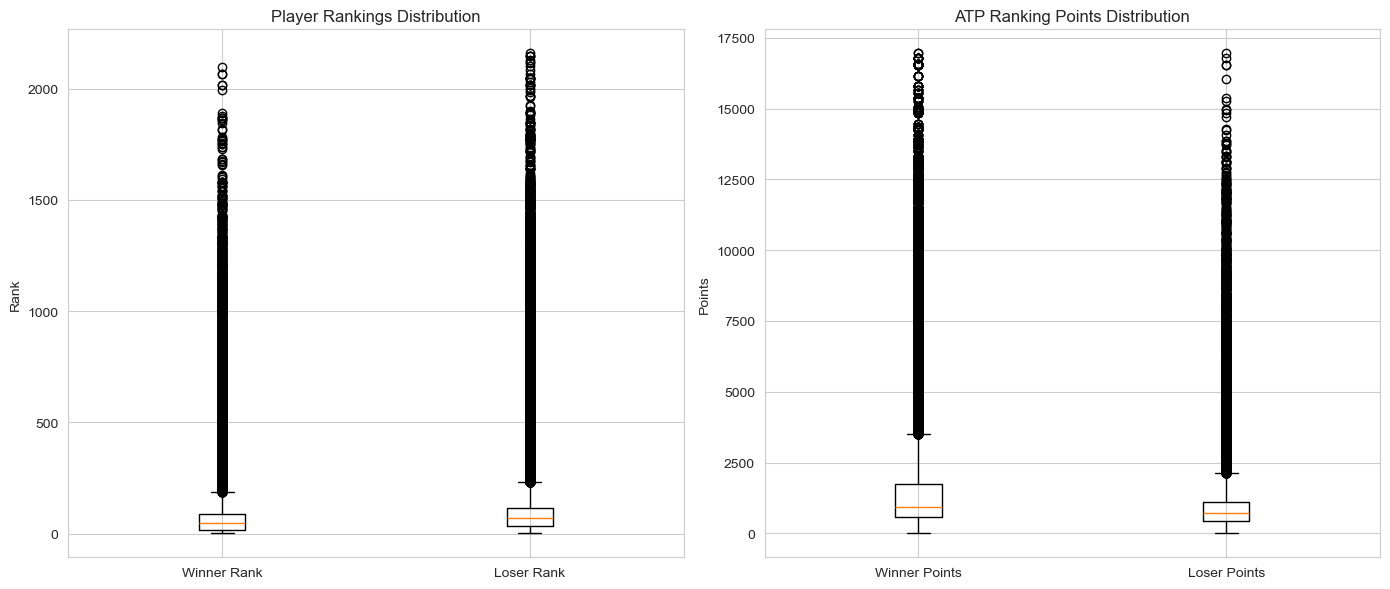

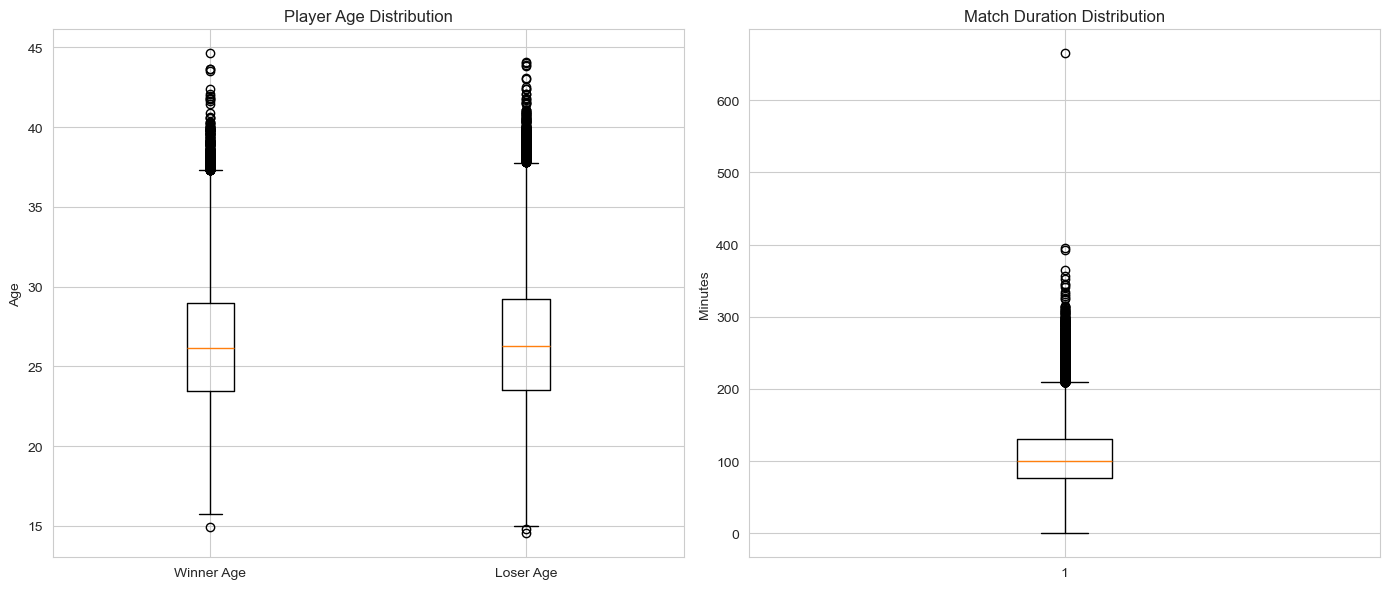

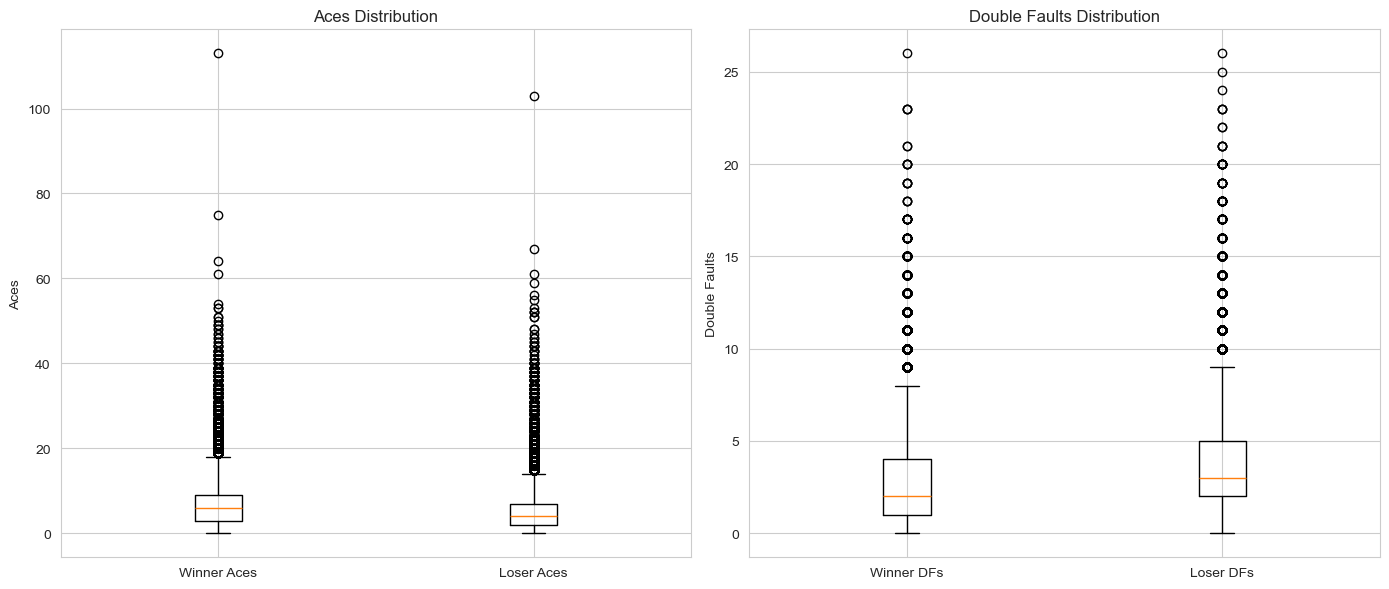

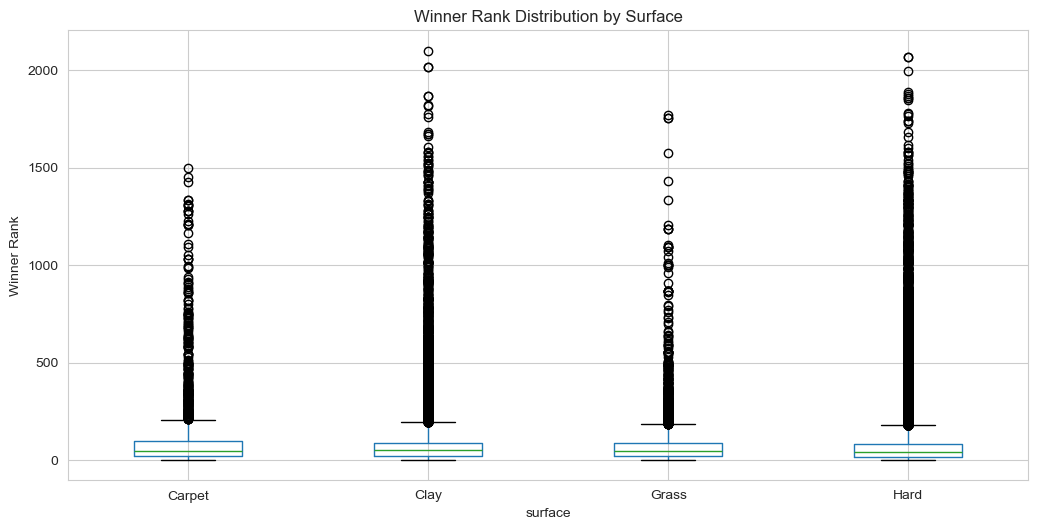

In [219]:
sns.set_style("whitegrid")

# 1. Rankings and points
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].boxplot([df['winner_rank'].dropna(), df['loser_rank'].dropna()],
                labels=['Winner Rank', 'Loser Rank'])
axes[0].set_title('Player Rankings Distribution')
axes[0].set_ylabel('Rank')

axes[1].boxplot([df['winner_rank_points'].dropna(), df['loser_rank_points'].dropna()],
                labels=['Winner Points', 'Loser Points'])
axes[1].set_title('ATP Ranking Points Distribution')
axes[1].set_ylabel('Points')

plt.tight_layout()
plt.show()

# 2. Age and match duration
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].boxplot([df['winner_age'].dropna(), df['loser_age'].dropna()],
                labels=['Winner Age', 'Loser Age'])
axes[0].set_title('Player Age Distribution')
axes[0].set_ylabel('Age')

axes[1].boxplot(df['minutes'].dropna())
axes[1].set_title('Match Duration Distribution')
axes[1].set_ylabel('Minutes')

plt.tight_layout()
plt.show()

# 3. Serve stats
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].boxplot([df['w_ace'].dropna(), df['l_ace'].dropna()],
                labels=['Winner Aces', 'Loser Aces'])
axes[0].set_title('Aces Distribution')
axes[0].set_ylabel('Aces')

axes[1].boxplot([df['w_df'].dropna(), df['l_df'].dropna()],
                labels=['Winner DFs', 'Loser DFs'])
axes[1].set_title('Double Faults Distribution')
axes[1].set_ylabel('Double Faults')

plt.tight_layout()
plt.show()

# 4. Winner rank by surface
plt.figure(figsize=(12, 6))
df.boxplot(column='winner_rank', by='surface', ax=plt.gca())
plt.title('Winner Rank Distribution by Surface')
plt.suptitle('')
plt.ylabel('Winner Rank')
plt.show()

##### Outlier Decision: Rankings and Match Duration

**600-minute match (Isner-Mahut, Wimbledon 2010):**
Kept as-is. This is a real match, not a data error — removing it would be dishonest data cleaning. Match duration is also post-match data and won't be used as a prediction feature, making it irrelevant to model quality.

**Very low-ranked players (rank 1500+):**
Kept in training data. These are legitimate ATP matches (wildcards, Davis Cup) and removing them would introduce bias by artificially excluding real upsets. The better approach is to keep all matches for training but restrict predictions to players ranked inside 500, where historical data is sufficient for reliable Elo and form calculations.

*Decision: No filtering applied. Full tour coverage retained.*

### Removing Walkovers and Retirements

Matches where no sets were completed (walkovers) or where set data is missing don't provide useful training signal for a predictive model. These matches were decided by forfeit, injury, or administrative reasons rather than competitive play. I'll identify and remove these records to ensure the model learns from actual match performance.

In [220]:
print("="*60)
print("REMOVING WALKOVERS AND RETIREMENTS")
print("="*60)

# Inspect score field for non-competitive matches
print("\nSample of unusual scores:")
unusual = df[df['score'].str.contains('W/O|RET|DEF|walkover', case=False, na=False)]
print(f"Total non-competitive matches: {len(unusual)}")
print(unusual['score'].value_counts().head(20))

# Remove walkovers and retirements
df_clean = df[~df['score'].str.contains('W/O|RET|DEF|walkover', case=False, na=False)].copy()

# Also remove matches with null score
df_clean = df_clean[df_clean['score'].notna()].copy()

print(f"\n{'='*60}")
print(f"Original dataset:              {len(df):,} matches")
print(f"After removing non-competitive: {len(df_clean):,} matches")
print(f"Matches removed:               {len(df) - len(df_clean):,}")
print(f"{'='*60}")

REMOVING WALKOVERS AND RETIREMENTS

Sample of unusual scores:
Total non-competitive matches: 2788
score
W/O            412
6-4 RET         49
6-3 RET         46
6-2 RET         44
4-1 RET         42
6-1 RET         34
3-0 RET         34
6-2 3-0 RET     33
5-2 RET         33
7-5 RET         27
6-3 3-0 RET     25
6-4 3-0 RET     23
5-0 RET         23
6-3 1-0 RET     23
6-2 1-0 RET     22
6-1 1-0 RET     21
2-1 RET         21
6-2 2-1 RET     20
4-3 RET         20
5-1 RET         19
Name: count, dtype: int64

Original dataset:              77,954 matches
After removing non-competitive: 75,164 matches
Matches removed:               2,790


##### Resolution: Cleaning Incomplete Matches

After identifying matches with missing set data and mid-match retirements, I removed them from the dataset to ensure model training uses only completed competitive matches. Matches where the winner only captured 1 set or fewer are removed as they indicate walkovers or early retirements that don't reflect competitive play.


## Feature Engineering
### Removing innecesary columns/matches for modeling


#### Removing Non-Predictive Columns

The following columns are removed as they offer no genuine predictive signal:

- **match_num**: Internal tournament ordering, irrelevant to outcome
- **draw_size**: Redundant with `tourney_level`
- **winner/loser_seed**: Derived directly from rank, redundant
- **winner/loser_entry**: WC/Q/LL status is too sparse to be useful
- **winner/loser_ioc**: Nationality has no predictive power for individual match outcomes

`indoor` is retained — while surface captures most court-type signal, indoor/outdoor conditions (lighting, ball bounce, humidity) can influence play style independently.

In [221]:
non_predictive_cols = [
    'match_num', 'draw_size',
    'winner_seed', 'loser_seed',
    'winner_entry', 'loser_entry',
    'winner_ioc', 'loser_ioc'
]

print(f"Columns before removal: {df_clean.shape[1]}")
df_clean = df_clean.drop(columns=non_predictive_cols)
print(f"Columns after removal: {df_clean.shape[1]}")
print(f"\nRemaining columns:")
print(df_clean.columns.tolist())

Columns before removal: 50
Columns after removal: 42

Remaining columns:
['tourney_id', 'tourney_name', 'surface', 'tourney_level', 'indoor', 'tourney_date', 'winner_id', 'winner_name', 'winner_hand', 'winner_ht', 'winner_age', 'winner_rank', 'winner_rank_points', 'loser_id', 'loser_name', 'loser_hand', 'loser_ht', 'loser_age', 'loser_rank', 'loser_rank_points', 'score', 'best_of', 'round', 'minutes', 'w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon', 'w_2ndWon', 'w_SvGms', 'w_bpSaved', 'w_bpFaced', 'l_ace', 'l_df', 'l_svpt', 'l_1stIn', 'l_1stWon', 'l_2ndWon', 'l_SvGms', 'l_bpSaved', 'l_bpFaced']


#### Removing Post-Match Columns

The following columns contain information only available **after** a match is played — using them directly as features would be data leakage:

- **score**: Used for cleaning, now dropped
- **minutes**: Match duration only known after completion

Serve stats (`w_ace`, `w_df`, `w_svpt`, etc.) are **not dropped yet**. They will be used to engineer historical player performance features in the next section, then dropped after derivation.

In [222]:
post_match_cols = ['score', 'minutes']

print(f"Columns before removal: {df_clean.shape[1]}")
df_clean = df_clean.drop(columns=post_match_cols)
print(f"Columns after removal: {df_clean.shape[1]}")
print(f"\nRemaining columns:")
print(df_clean.columns.tolist())

Columns before removal: 42
Columns after removal: 40

Remaining columns:
['tourney_id', 'tourney_name', 'surface', 'tourney_level', 'indoor', 'tourney_date', 'winner_id', 'winner_name', 'winner_hand', 'winner_ht', 'winner_age', 'winner_rank', 'winner_rank_points', 'loser_id', 'loser_name', 'loser_hand', 'loser_ht', 'loser_age', 'loser_rank', 'loser_rank_points', 'best_of', 'round', 'w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon', 'w_2ndWon', 'w_SvGms', 'w_bpSaved', 'w_bpFaced', 'l_ace', 'l_df', 'l_svpt', 'l_1stIn', 'l_1stWon', 'l_2ndWon', 'l_SvGms', 'l_bpSaved', 'l_bpFaced']


#### Removing Round Robin Matches

Round Robin matches introduce unique conditions that make them poorly representative of standard tour play:

- **ATP Finals / Masters Cup**: End-of-season fatigue, elite-only field (top 8), and perverse incentives (players may rest if group qualification is already secured)
- **Team events (ATP Cup, Laver Cup, World Team Cup)**: Team dynamics and national pride create different motivation structures than individual tour matches
- **Historical 250-level RR events**: Too few matches to provide reliable signal

All Round Robin matches are removed regardless of tournament, keeping only standard knockout-format matches for training.

In [223]:
# Remove all round robin matches
rr_mask = df_clean['round'] == 'RR'

print(f"Round Robin matches to remove: {rr_mask.sum()}")
print(f"\nTournaments affected:")
print(df_clean[rr_mask]['tourney_name'].value_counts().head(15))

df_clean = df_clean[~rr_mask].copy()

print(f"\nDataset size after removal: {len(df_clean):,} matches")

Round Robin matches to remove: 8182

Tournaments affected:
tourney_name
World Team Championship    238
Tour Finals                154
Masters Cup                 96
ATP Cup                     85
United Cup                  82
World Team Cup              69
Laver Cup                   63
ATP Finals                  36
NextGen Finals              36
Las Vegas                   31
Buenos Aires                31
Delray Beach                30
Adelaide                    30
Vina del Mar                24
Next Gen Finals             24
Name: count, dtype: int64

Dataset size after removal: 66,982 matches


### Dataset Restructuring: Eliminating Winner/Loser Leakage

The current dataset structure (winner/loser columns) creates fundamental data leakage — the model would implicitly know who won before predicting. We transform each match into a neutral Player A vs Player B format with random assignment.

**Transformation approach:**
- Each match is randomly flipped: 50% keep winner as Player A, 50% swap to Player B
- Target becomes: Did Player A win? (1=yes, 0=no)
- All player-specific features are relabeled accordingly
- Player names and IDs are preserved for subsequent feature engineering (Elo, form, H2H, serve stats)
- This prevents the model from learning "the player in the winner column has better stats"

**Note:** Feature engineering will be performed after this restructuring to ensure all features are calculated from the neutral Player A/B perspective.

In [224]:
np.random.seed(42)

rows = []

for idx, row in df_clean.iterrows():
    flip = np.random.random() > 0.5
    
    if flip:
        new_row = {
            'tourney_id':       row['tourney_id'],
            'tourney_name':     row['tourney_name'],
            'tourney_date':     row['tourney_date'],
            'surface':          row['surface'],
            'tourney_level':    row['tourney_level'],
            'indoor':           row['indoor'],
            'best_of':          row['best_of'],
            'round':            row['round'],
            'player_a_id':      row['loser_id'],
            'player_a_name':    row['loser_name'],
            'player_a_rank':    row['loser_rank'],
            'player_a_points':  row['loser_rank_points'],
            'player_a_age':     row['loser_age'],
            'player_a_height':  row['loser_ht'],
            'player_a_hand':    row['loser_hand'],
            'player_b_id':      row['winner_id'],
            'player_b_name':    row['winner_name'],
            'player_b_rank':    row['winner_rank'],
            'player_b_points':  row['winner_rank_points'],
            'player_b_age':     row['winner_age'],
            'player_b_height':  row['winner_ht'],
            'player_b_hand':    row['winner_hand'],
            'w_svpt':    row['w_svpt'],
            'w_1stIn':   row['w_1stIn'],
            'w_1stWon':  row['w_1stWon'],
            'w_2ndWon':  row['w_2ndWon'],
            'w_bpSaved': row['w_bpSaved'],
            'w_bpFaced': row['w_bpFaced'],
            'w_ace':     row['w_ace'],
            'w_df':      row['w_df'],
            'l_svpt':    row['l_svpt'],
            'l_1stIn':   row['l_1stIn'],
            'l_1stWon':  row['l_1stWon'],
            'l_2ndWon':  row['l_2ndWon'],
            'l_bpSaved': row['l_bpSaved'],
            'l_bpFaced': row['l_bpFaced'],
            'l_ace':     row['l_ace'],
            'l_df':      row['l_df'],
            'target': 0
        }
    else:
        new_row = {
            'tourney_id':       row['tourney_id'],
            'tourney_name':     row['tourney_name'],
            'tourney_date':     row['tourney_date'],
            'surface':          row['surface'],
            'tourney_level':    row['tourney_level'],
            'indoor':           row['indoor'],
            'best_of':          row['best_of'],
            'round':            row['round'],
            'player_a_id':      row['winner_id'],
            'player_a_name':    row['winner_name'],
            'player_a_rank':    row['winner_rank'],
            'player_a_points':  row['winner_rank_points'],
            'player_a_age':     row['winner_age'],
            'player_a_height':  row['winner_ht'],
            'player_a_hand':    row['winner_hand'],
            'player_b_id':      row['loser_id'],
            'player_b_name':    row['loser_name'],
            'player_b_rank':    row['loser_rank'],
            'player_b_points':  row['loser_rank_points'],
            'player_b_age':     row['loser_age'],
            'player_b_height':  row['loser_ht'],
            'player_b_hand':    row['loser_hand'],
            'w_svpt':    row['w_svpt'],
            'w_1stIn':   row['w_1stIn'],
            'w_1stWon':  row['w_1stWon'],
            'w_2ndWon':  row['w_2ndWon'],
            'w_bpSaved': row['w_bpSaved'],
            'w_bpFaced': row['w_bpFaced'],
            'w_ace':     row['w_ace'],
            'w_df':      row['w_df'],
            'l_svpt':    row['l_svpt'],
            'l_1stIn':   row['l_1stIn'],
            'l_1stWon':  row['l_1stWon'],
            'l_2ndWon':  row['l_2ndWon'],
            'l_bpSaved': row['l_bpSaved'],
            'l_bpFaced': row['l_bpFaced'],
            'l_ace':     row['l_ace'],
            'l_df':      row['l_df'],
            'target': 1
        }
    
    rows.append(new_row)

df_neutral = pd.DataFrame(rows)

print(f"Restructured dataset shape: {df_neutral.shape}")
print(f"\nTarget distribution (should be ~50/50):")
print(df_neutral['target'].value_counts())
print(f"Target mean: {df_neutral['target'].mean():.2%}")

print(f"\nFeature coverage:")
cols_to_check = ['player_a_rank', 'player_b_rank', 'player_a_age', 'player_b_age',
                 'player_a_height', 'player_b_height', 'player_a_hand', 'player_b_hand']
for col in cols_to_check:
    coverage = df_neutral[col].notna().mean()
    print(f"  {col:<25} {coverage:.1%}")

Restructured dataset shape: (66982, 39)

Target distribution (should be ~50/50):
target
0    33493
1    33489
Name: count, dtype: int64
Target mean: 50.00%

Feature coverage:
  player_a_rank             99.8%
  player_b_rank             99.9%
  player_a_age              100.0%
  player_b_age              100.0%
  player_a_height           99.6%
  player_b_height           99.6%
  player_a_hand             99.9%
  player_b_hand             99.9%


### Creating handedness indicators
Handedness matters in tennis - left-handed players have an advantage because opponents face them less frequently and are less familiar with their spin patterns and shot angles.

In [225]:
# Both right-handed (baseline/most common matchup)
df_neutral['both_righthanded'] = (
    (df_neutral['player_a_hand'] == 'R') & 
    (df_neutral['player_b_hand'] == 'R')
).astype(int)

# Both left-handed (rare matchup)
df_neutral['both_lefthanded'] = (
    (df_neutral['player_a_hand'] == 'L') & 
    (df_neutral['player_b_hand'] == 'L')
).astype(int)

# One lefty (asymmetric matchup - gives lefty an advantage)
df_neutral['one_lefty'] = (
    ((df_neutral['player_a_hand'] == 'L') & (df_neutral['player_b_hand'] == 'R')) |
    ((df_neutral['player_a_hand'] == 'R') & (df_neutral['player_b_hand'] == 'L'))
).astype(int)

print("Handedness indicators created")
print(f"  Both right-handed: {df_neutral['both_righthanded'].sum():,} matches ({df_neutral['both_righthanded'].mean():.1%})")
print(f"  Both left-handed:  {df_neutral['both_lefthanded'].sum():,} matches ({df_neutral['both_lefthanded'].mean():.1%})")
print(f"  One lefty:         {df_neutral['one_lefty'].sum():,} matches ({df_neutral['one_lefty'].mean():.1%})")

Handedness indicators created
  Both right-handed: 50,534 matches (75.4%)
  Both left-handed:  1,117 matches (1.7%)
  One lefty:         15,223 matches (22.7%)


### Creating Differential Features

Differential features capture the gap between players, which is often more predictive than absolute values.

**Why they matter:**

Instead of giving the model separate values:
- Player A rank = 5
- Player B rank = 20

We create:
- Rank differential = -15 (negative means Player A is higher-ranked)

*This directly encodes "how much better is Player A?" in a single feature.*

**The differentials:**

#### Ranking Differential (rank_diff)

`player_a_rank - player_b_rank`
- **Negative value** = Player A is higher-ranked (lower rank number = better)
- **Positive value** = Player B is higher-ranked
- Example: Player A (Rank 10) vs Player B (Rank 50) → 10 - 50 = **-40** (Player A is favorite)
- Example: Player A (Rank 50) vs Player B (Rank 10) → 50 - 10 = **+40** (Player B is favorite)

#### ATP Points Differential (points_diff)

`player_a_points - player_b_points`
- Captures magnitude of skill gap using ATP ranking points
- **Positive value** = Player A has more points (stronger)
- **Negative value** = Player B has more points (stronger)
- Example: Player A (5000 pts) vs Player B (4800 pts) → +200 (close match)
- Example: Player A (10000 pts) vs Player B (500 pts) → +9500 (huge gap)

**Why keep both rank and points?**

Tennis rankings and ATP points measure slightly different things:
- **Rank**: Ordinal position (who's ahead of whom)
- **Points**: Cardinal distance (how far ahead they are)

The top 5 players often have massive point gaps over the rest of the field, while mid-ranked players cluster closely together. Both features provide complementary information about the skill gap.

**Note:** Additional differentials will be created after historical feature engineering (form, serve statistics). These include first serve % differential, break point conversion differential, and ace rate differential. The current differentials capture static pre-match information; the upcoming features will capture dynamic player form and performance trends.

In [226]:
# Create differential features from neutral Player A/B structure
df_neutral['rank_diff'] = df_neutral['player_a_rank'] - df_neutral['player_b_rank']
df_neutral['points_diff'] = df_neutral['player_a_points'] - df_neutral['player_b_points']

print("Differential features created:")
print(f"\nRank differential stats:")
print(df_neutral['rank_diff'].describe())
print(f"\nPoints differential stats:")
print(df_neutral['points_diff'].describe())

# Verify the differentials make sense
print("\nSample with differentials:")
print(df_neutral[['player_a_name', 'player_b_name', 'player_a_rank', 'player_b_rank', 
                   'rank_diff', 'points_diff', 'target']].head(10))

Differential features created:

Rank differential stats:
count    66776.000000
mean        -0.291347
std        133.725280
min      -2125.000000
25%        -41.000000
50%          1.000000
75%         41.000000
max       2094.000000
Name: rank_diff, dtype: float64

Points differential stats:
count    66776.000000
mean        -3.771280
std       2173.670862
min     -16641.000000
25%       -580.000000
50%         -3.000000
75%        571.000000
max      16304.000000
Name: points_diff, dtype: float64

Sample with differentials:
      player_a_name        player_b_name  player_a_rank  player_b_rank  \
0    Thomas Enqvist       Arnaud Clement            4.0           56.0   
1  Jens Knippschild        Roger Federer           91.0           64.0   
2     Wayne Arthurs  Jan-Michael Gambill          105.0           58.0   
3       Andrew Ilie   Sebastien Grosjean           54.0           27.0   
4     Magnus Norman         Scott Draper           15.0          154.0   
5  Richard Fromberg      

#### Age and Height Differentials

In [227]:
# Age differential
df_neutral['age_diff'] = df_neutral['player_a_age'] - df_neutral['player_b_age']

# Height differential
df_neutral['height_diff'] = df_neutral['player_a_height'] - df_neutral['player_b_height']

print("Age and height differentials created")
print(f"  age_diff range: {df_neutral['age_diff'].min():.1f} to {df_neutral['age_diff'].max():.1f}")
print(f"  height_diff range: {df_neutral['height_diff'].min():.1f} to {df_neutral['height_diff'].max():.1f}")

Age and height differentials created
  age_diff range: -25.9 to 21.6
  height_diff range: -43.0 to 41.0


### Historical Performance Features

#### Player Form: Overall and Surface-Specific

Form captures a player's recent momentum entering a match. By calculating win rate over the previous 5 matches, the model learns whether a player is on a hot streak or struggling.

**Why track both overall and surface-specific form?**

Tennis players exhibit dramatically different performance across surfaces:
- **Clay specialists** (e.g., Nadal) dominate on clay but may struggle on grass
- **Grass specialists** excel in the brief grass season but underperform on other surfaces
- Even **all-court players** show significant variance between surfaces

A player might be 4-1 on hard courts (80% form) but 1-4 on clay (20% form). Using only overall form (3-2 = 60%) would miss this critical surface context.

**Two complementary features:**

1. **Overall Form (`player_a_form_overall`)**: Last 5 matches across all surfaces
   - Captures general momentum, confidence, and fitness
   - Useful for understanding a player's current level regardless of surface

2. **Surface-Specific Form (`player_a_form_surface`)**: Last 5 matches on the current surface
   - Captures surface specialization and adaptation
   - Critical for identifying clay court specialists, grass experts, etc.

By providing both features, we let the model learn when general momentum matters more versus when surface specialization is the dominant factor.

**Temporal integrity:** Form is calculated chronologically - only matches that occurred *before* the current match inform the calculation, preventing data leakage.

In [228]:
df_neutral = df_neutral.sort_values('tourney_date').reset_index(drop=True)

player_history_overall = defaultdict(list)
player_history_by_surface = defaultdict(lambda: defaultdict(list))

df_neutral['player_a_form_overall'] = None
df_neutral['player_b_form_overall'] = None
df_neutral['player_a_form_surface'] = None
df_neutral['player_b_form_surface'] = None

print("Calculating form features (overall and surface-specific)...")

for idx, row in tqdm(df_neutral.iterrows(), total=len(df_neutral)):
    player_a = row['player_a_name']
    player_b = row['player_b_name']
    surface = row['surface']
    player_a_won = row['target']

    player_a_history_overall = player_history_overall[player_a][-5:]
    player_b_history_overall = player_history_overall[player_b][-5:]
    player_a_history_surface = player_history_by_surface[player_a][surface][-5:]
    player_b_history_surface = player_history_by_surface[player_b][surface][-5:]

    if len(player_a_history_overall) > 0:
        df_neutral.at[idx, 'player_a_form_overall'] = sum([r[0] for r in player_a_history_overall]) / len(player_a_history_overall)
    if len(player_b_history_overall) > 0:
        df_neutral.at[idx, 'player_b_form_overall'] = sum([r[0] for r in player_b_history_overall]) / len(player_b_history_overall)
    if len(player_a_history_surface) > 0:
        df_neutral.at[idx, 'player_a_form_surface'] = sum(player_a_history_surface) / len(player_a_history_surface)
    if len(player_b_history_surface) > 0:
        df_neutral.at[idx, 'player_b_form_surface'] = sum(player_b_history_surface) / len(player_b_history_surface)

    player_history_overall[player_a].append((player_a_won, surface))
    player_history_overall[player_b].append((1 - player_a_won, surface))
    player_history_by_surface[player_a][surface].append(player_a_won)
    player_history_by_surface[player_b][surface].append(1 - player_a_won)

print("\n" + "="*60)
print("FORM FEATURE SUMMARY")
print("="*60)
print(f"\nMatches with overall form data:          {df_neutral['player_a_form_overall'].notna().sum():,}")
print(f"Matches without overall form data:       {df_neutral['player_a_form_overall'].isna().sum():,}")
print(f"\nMatches with surface form data:          {df_neutral['player_a_form_surface'].notna().sum():,}")
print(f"Matches without surface form data:       {df_neutral['player_a_form_surface'].isna().sum():,}")

print("\nOverall form statistics:")
print(df_neutral[['player_a_form_overall', 'player_b_form_overall']].describe())

print("\nSurface-specific form statistics:")
print(df_neutral[['player_a_form_surface', 'player_b_form_surface']].describe())

print("\nSample: Carlos Alcaraz matches with form features")
alcaraz = df_neutral[
    (df_neutral['player_a_name'] == 'Carlos Alcaraz') | 
    (df_neutral['player_b_name'] == 'Carlos Alcaraz')
]
print(alcaraz[['tourney_date', 'player_a_name', 'player_b_name', 'surface',
               'player_a_form_overall', 'player_a_form_surface', 'target']].head(10))

Calculating form features (overall and surface-specific)...


100%|██████████| 66982/66982 [00:07<00:00, 9427.85it/s] 



FORM FEATURE SUMMARY

Matches with overall form data:          66,158
Matches without overall form data:       824

Matches with surface form data:          65,185
Matches without surface form data:       1,797

Overall form statistics:
        player_a_form_overall  player_b_form_overall
count                 66158.0                66169.0
unique                   11.0                   11.0
top                       0.6                    0.6
freq                  19441.0                19529.0

Surface-specific form statistics:
        player_a_form_surface  player_b_form_surface
count                 65185.0                65172.0
unique                   11.0                   11.0
top                       0.6                    0.6
freq                  18954.0                18999.0

Sample: Carlos Alcaraz matches with form features
       tourney_date         player_a_name            player_b_name surface  \
53270      20200217  Albert Ramos-Vinolas           Carlos Alcaraz  

#### Serve and Break Points Performance Features

Using the raw serve statistics available in TML, we engineer rolling historical features that capture each player's serving tendencies **before** the match being predicted. All features are calculated as rolling averages over the player's last 10 matches, using only matches that occurred prior to the current one (no leakage).

**Why 10 matches instead of 5?**
Serve statistics are noisier than binary win/loss outcomes. A player can ace 20 times in one match and 2 in the next depending on opponent and conditions. A 10-match window provides more stable estimates while still capturing recent form.

**Features derived:**

| Feature | Formula | What it captures |
|--------|---------|-----------------|
| `first_serve_pct` | `1stIn / svpt` | Consistency getting first serve in |
| `first_serve_won_pct` | `1stWon / 1stIn` | Effectiveness of first serve |
| `second_serve_won_pct` | `2ndWon / (svpt - 1stIn)` | Second serve quality under pressure |
| `bp_save_pct` | `bpSaved / bpFaced` | Clutch serving when broken |
| `ace_rate` | `ace / svpt` | Raw serving power |
| `df_rate` | `df / svpt` | Serving inconsistency (negative indicator) |

All features are then differenced (`player_a - player_b`) to create a single value capturing the relative advantage.

**Temporal integrity:** Stats are updated after each match, ensuring only pre-match history informs each calculation.

In [229]:
SERVE_WINDOW = 10

# Storage: player -> list of per-match serve stat dicts
player_serve_history = defaultdict(list)

# Initialize columns
serve_features = [
    'first_serve_pct', 'first_serve_won_pct', 'second_serve_won_pct',
    'bp_save_pct', 'ace_rate', 'df_rate'
]

for feat in serve_features:
    df_neutral[f'player_a_{feat}'] = None
    df_neutral[f'player_b_{feat}'] = None

def compute_serve_stats(history):
    """Compute rolling serve stats from a list of per-match dicts."""
    if not history:
        return None
    
    window = history[-SERVE_WINDOW:]
    
    svpt       = sum(m['svpt'] for m in window)
    first_in   = sum(m['1stIn'] for m in window)
    first_won  = sum(m['1stWon'] for m in window)
    second_won = sum(m['2ndWon'] for m in window)
    bp_saved   = sum(m['bpSaved'] for m in window)
    bp_faced   = sum(m['bpFaced'] for m in window)
    aces       = sum(m['ace'] for m in window)
    dfs        = sum(m['df'] for m in window)
    
    second_svpt = svpt - first_in
    
    return {
        'first_serve_pct':       first_in / svpt if svpt > 0 else None,
        'first_serve_won_pct':   first_won / first_in if first_in > 0 else None,
        'second_serve_won_pct':  second_won / second_svpt if second_svpt > 0 else None,
        'bp_save_pct':           bp_saved / bp_faced if bp_faced > 0 else None,
        'ace_rate':              aces / svpt if svpt > 0 else None,
        'df_rate':               dfs / svpt if svpt > 0 else None,
    }

print("Calculating historical serve features...")

for idx, row in tqdm(df_neutral.iterrows(), total=len(df_neutral)):
    player_a = row['player_a_name']
    player_b = row['player_b_name']

    # Compute stats from history BEFORE this match
    stats_a = compute_serve_stats(player_serve_history[player_a])
    stats_b = compute_serve_stats(player_serve_history[player_b])

    if stats_a:
        for feat in serve_features:
            df_neutral.at[idx, f'player_a_{feat}'] = stats_a[feat]

    if stats_b:
        for feat in serve_features:
            df_neutral.at[idx, f'player_b_{feat}'] = stats_b[feat]

    # Update history AFTER (no leakage)
    # Winner stats
    winner_is_a = row['target'] == 1
    
    w_stats = {
        'svpt':    row['w_svpt'],
        '1stIn':   row['w_1stIn'],
        '1stWon':  row['w_1stWon'],
        '2ndWon':  row['w_2ndWon'],
        'bpSaved': row['w_bpSaved'],
        'bpFaced': row['w_bpFaced'],
        'ace':     row['w_ace'],
        'df':      row['w_df'],
    }
    l_stats = {
        'svpt':    row['l_svpt'],
        '1stIn':   row['l_1stIn'],
        '1stWon':  row['l_1stWon'],
        '2ndWon':  row['l_2ndWon'],
        'bpSaved': row['l_bpSaved'],
        'bpFaced': row['l_bpFaced'],
        'ace':     row['l_ace'],
        'df':      row['l_df'],
    }

    # Check for NaN before appending (some matches have missing serve stats)
    def has_valid_stats(s):
        return all(v is not None and not (isinstance(v, float) and np.isnan(v)) for v in s.values())

    if winner_is_a:
        if has_valid_stats(w_stats): player_serve_history[player_a].append(w_stats)
        if has_valid_stats(l_stats): player_serve_history[player_b].append(l_stats)
    else:
        if has_valid_stats(l_stats): player_serve_history[player_a].append(l_stats)
        if has_valid_stats(w_stats): player_serve_history[player_b].append(w_stats)

print("\n" + "="*60)
print("SERVE FEATURE SUMMARY")
print("="*60)

for feat in serve_features:
    col_a = f'player_a_{feat}'
    coverage = df_neutral[col_a].notna().mean()
    print(f"  {feat:<30} coverage: {coverage:.1%}")

# Create differentials
print("\nCreating serve differentials...")
for feat in serve_features:
    df_neutral[f'{feat}_diff'] = df_neutral[f'player_a_{feat}'] - df_neutral[f'player_b_{feat}']
    print(f"  ✓ {feat}_diff")

print("\nServe differential statistics:")
diff_cols = [f'{feat}_diff' for feat in serve_features]
print(df_neutral[diff_cols].describe())

Calculating historical serve features...


100%|██████████| 66982/66982 [00:18<00:00, 3671.56it/s]



SERVE FEATURE SUMMARY
  first_serve_pct                coverage: 98.8%
  first_serve_won_pct            coverage: 98.8%
  second_serve_won_pct           coverage: 98.8%
  bp_save_pct                    coverage: 98.8%
  ace_rate                       coverage: 98.8%
  df_rate                        coverage: 98.8%

Creating serve differentials...
  ✓ first_serve_pct_diff
  ✓ first_serve_won_pct_diff
  ✓ second_serve_won_pct_diff
  ✓ bp_save_pct_diff
  ✓ ace_rate_diff
  ✓ df_rate_diff

Serve differential statistics:
        first_serve_pct_diff  first_serve_won_pct_diff  \
count                65376.0                   65376.0   
unique               65348.0                   65223.0   
top                      0.0                       0.0   
freq                     4.0                       7.0   

        second_serve_won_pct_diff  bp_save_pct_diff  ace_rate_diff  \
count                     65376.0           65367.0        65376.0   
unique                    64593.0           509

In [230]:
# Convert serve feature columns to float
for feat in serve_features:
    df_neutral[f'player_a_{feat}'] = pd.to_numeric(df_neutral[f'player_a_{feat}'], errors='coerce')
    df_neutral[f'player_b_{feat}'] = pd.to_numeric(df_neutral[f'player_b_{feat}'], errors='coerce')
    df_neutral[f'{feat}_diff']     = pd.to_numeric(df_neutral[f'{feat}_diff'],     errors='coerce')

print("Serve differential statistics:")
print(df_neutral[[f'{feat}_diff' for feat in serve_features]].describe())

Serve differential statistics:
       first_serve_pct_diff  first_serve_won_pct_diff  \
count          65376.000000              65376.000000   
mean              -0.000180                 -0.000071   
std                0.067928                  0.069209   
min               -0.336898                 -0.502024   
25%               -0.045081                 -0.045693   
50%               -0.000202                 -0.000385   
75%                0.044678                  0.045758   
max                0.353135                  0.462028   

       second_serve_won_pct_diff  bp_save_pct_diff  ace_rate_diff  \
count               65376.000000      6.536700e+04   65376.000000   
mean                   -0.000367     -9.938173e-07      -0.000358   
std                     0.058635      1.055828e-01       0.056677   
min                    -0.413702     -7.638889e-01      -0.305664   
25%                    -0.037954     -6.723701e-02      -0.033251   
50%                    -0.000153      0.0

##### Player Inactivity Adjustment

Players returning from extended breaks (injury, personal reasons, off-season) shouldn't carry forward outdated form. If a player's most recent match was more than 90 days ago, their form becomes unreliable and should be reset.

**Why 90 days matters:**
- Tennis season runs ~11 months with only a brief off-season (typically late December)
- Normal active players compete every 1-4 weeks during the season
- A 3-month gap indicates injury, personal break, or off-season inactivity
- Their pre-break form no longer reflects current fitness and match sharpness
- Resetting to neutral (0.5) is more realistic than carrying stale win rates

**Implementation approach:**
1. Track each player's most recent match date as we process chronologically
2. For each match, check if either player has been inactive (>90 days since last match)
3. Create inactivity flags for both players
4. Reset form to neutral (0.5) for inactive players - indicating maximum uncertainty

In [231]:
# Convert tourney_date to datetime for date arithmetic
df_neutral['tourney_date_dt'] = pd.to_datetime(df_neutral['tourney_date'], format='%Y%m%d')

player_last_match = {}

df_neutral['player_a_inactive'] = False
df_neutral['player_b_inactive'] = False

INACTIVITY_THRESHOLD = timedelta(days=90)

print("Calculating player inactivity flags...")

for idx, row in tqdm(df_neutral.iterrows(), total=len(df_neutral)):
    current_date = row['tourney_date_dt']
    player_a = row['player_a_name']
    player_b = row['player_b_name']

    if player_a in player_last_match:
        if current_date - player_last_match[player_a] > INACTIVITY_THRESHOLD:
            df_neutral.at[idx, 'player_a_inactive'] = True
            if pd.notna(df_neutral.at[idx, 'player_a_form_overall']):
                df_neutral.at[idx, 'player_a_form_overall'] = 0.5
            if pd.notna(df_neutral.at[idx, 'player_a_form_surface']):
                df_neutral.at[idx, 'player_a_form_surface'] = 0.5

    if player_b in player_last_match:
        if current_date - player_last_match[player_b] > INACTIVITY_THRESHOLD:
            df_neutral.at[idx, 'player_b_inactive'] = True
            if pd.notna(df_neutral.at[idx, 'player_b_form_overall']):
                df_neutral.at[idx, 'player_b_form_overall'] = 0.5
            if pd.notna(df_neutral.at[idx, 'player_b_form_surface']):
                df_neutral.at[idx, 'player_b_form_surface'] = 0.5

    player_last_match[player_a] = current_date
    player_last_match[player_b] = current_date

print("\n" + "="*60)
print("INACTIVITY SUMMARY")
print("="*60)
print(f"\nMatches with inactive Player A: {df_neutral['player_a_inactive'].sum()}")
print(f"Matches with inactive Player B: {df_neutral['player_b_inactive'].sum()}")
print(f"Matches with at least one inactive player: {(df_neutral['player_a_inactive'] | df_neutral['player_b_inactive']).sum()}")
print(f"Percentage of matches affected: {(df_neutral['player_a_inactive'] | df_neutral['player_b_inactive']).sum() / len(df_neutral) * 100:.2f}%")

print("\nSample matches with inactive players:")
inactive_matches = df_neutral[df_neutral['player_a_inactive'] | df_neutral['player_b_inactive']]
print(inactive_matches[['tourney_date', 'player_a_name', 'player_b_name',
                         'player_a_inactive', 'player_b_inactive',
                         'player_a_form_overall', 'player_b_form_overall']].head(10))

Calculating player inactivity flags...


100%|██████████| 66982/66982 [00:04<00:00, 16364.39it/s]


INACTIVITY SUMMARY

Matches with inactive Player A: 3018
Matches with inactive Player B: 2906
Matches with at least one inactive player: 5718
Percentage of matches affected: 8.54%

Sample matches with inactive players:
      tourney_date      player_a_name     player_b_name  player_a_inactive  \
827       20000410      Stephane Huet       Andrew Ilie               True   
892       20000410  Magnus Gustafsson     Michal Tabara               True   
907       20000417     Thomas Enqvist  Richard Krajicek              False   
909       20000417    Sargis Sargsian    Julien Boutter              False   
1074      20000501   Franco Squillari  Jens Knippschild              False   
1143      20000508       Andre Agassi       Todd Martin              False   
1254      20000522    Scott Humphries   Andrei Medvedev               True   
1275      20000529    Christian Vinck        Tim Henman               True   
1327      20000529        Andrew Ilie   Guillaume Raoux              False   


#### Head-to-Head Record

Head-to-head history captures matchup-specific dynamics between players. Some players consistently struggle against certain opponents regardless of current form or rankings due to stylistic matchups, psychological factors, or historical dominance. Classic examples include:
- **Nadal vs Federer on clay**: Nadal's 14-2 dominance despite both being all-time greats
- **Djokovic vs Monfils**: Djokovic's 18-0 career record - a complete psychological block
- **Murray vs Djokovic**: Competitive H2H despite ranking differences at various points

This feature tracks how many times each player has beaten the other in previous encounters, providing the model with rivalry context that transcends current form and rankings.

**Features created:**
- `player_a_h2h_wins`: How many times Player A has beaten Player B historically
- `player_b_h2h_wins`: How many times Player B has beaten Player A historically  
- `total_h2h_matches`: Total previous meetings between these two players

These features help the model learn when historical dominance matters versus when current form should override past matchups.

In [232]:
print("="*60)
print("HEAD-TO-HEAD RECORD")
print("="*60)

df_neutral = df_neutral.sort_values('tourney_date').reset_index(drop=True)

h2h_record = defaultdict(lambda: {'total': 0, 'wins': defaultdict(int)})

df_neutral['total_h2h'] = 0
df_neutral['player_a_h2h_wins'] = 0
df_neutral['player_b_h2h_wins'] = 0

for idx, row in tqdm(df_neutral.iterrows(), total=len(df_neutral)):
    player_a = row['player_a_name']
    player_b = row['player_b_name']
    player_a_won = row['target']

    pair_key = tuple(sorted([player_a, player_b]))

    player_a_h2h_wins = h2h_record[pair_key]['wins'][player_a]
    player_b_h2h_wins = h2h_record[pair_key]['wins'][player_b]
    total_h2h = h2h_record[pair_key]['total']

    df_neutral.at[idx, 'player_a_h2h_wins'] = player_a_h2h_wins
    df_neutral.at[idx, 'player_b_h2h_wins'] = player_b_h2h_wins
    df_neutral.at[idx, 'total_h2h'] = total_h2h

    winner = player_a if player_a_won == 1 else player_b
    h2h_record[pair_key]['wins'][winner] += 1
    h2h_record[pair_key]['total'] += 1

print(f"✓ H2H calculated")
print(f"  Average H2H matches: {df_neutral['total_h2h'].mean():.2f}")
print(f"  Matches with H2H history: {(df_neutral['total_h2h'] > 0).sum():,}")

# Verify with Alcaraz vs Sinner
alcaraz_sinner = df_neutral[
    ((df_neutral['player_a_name'] == 'Carlos Alcaraz') & (df_neutral['player_b_name'] == 'Jannik Sinner')) |
    ((df_neutral['player_a_name'] == 'Jannik Sinner') & (df_neutral['player_b_name'] == 'Carlos Alcaraz'))
].copy()

print(f"\n{'='*60}")
print("VERIFICATION: Alcaraz vs Sinner Rivalry")
print("="*60)
print(f"Total matches: {len(alcaraz_sinner)}")
print(alcaraz_sinner[['tourney_date', 'player_a_name', 'player_b_name',
                        'total_h2h', 'player_a_h2h_wins', 'player_b_h2h_wins',
                        'target']].to_string(index=False))

HEAD-TO-HEAD RECORD


100%|██████████| 66982/66982 [00:11<00:00, 5790.83it/s]

✓ H2H calculated
  Average H2H matches: 1.19
  Matches with H2H history: 30,371

VERIFICATION: Alcaraz vs Sinner Rivalry
Total matches: 15
 tourney_date  player_a_name  player_b_name  total_h2h  player_a_h2h_wins  player_b_h2h_wins  target
     20211101  Jannik Sinner Carlos Alcaraz          0                  0                  0       0
     20220627 Carlos Alcaraz  Jannik Sinner          1                  1                  0       0
     20220725 Carlos Alcaraz  Jannik Sinner          2                  1                  1       0
     20220829  Jannik Sinner Carlos Alcaraz          3                  2                  1       0
     20230306  Jannik Sinner Carlos Alcaraz          4                  2                  2       0
     20230320 Carlos Alcaraz  Jannik Sinner          5                  3                  2       0
     20230927  Jannik Sinner Carlos Alcaraz          6                  3                  3       1
     20240304 Carlos Alcaraz  Jannik Sinner          

## Memory optimization
Before model training, we'll optimize the dataset's memory footprint by downcasting numeric types and converting categorical variables to more efficient data types. This improves training speed and reduces memory consumption.

In [233]:
print("="*60)
print("MEMORY OPTIMIZATION")
print("="*60)

memory_before = df_neutral.memory_usage(deep=True).sum() / 1024**2
print(f"Memory before: {memory_before:.2f} MB")
print(f"Dataset shape: {df_neutral.shape}")

# Integer columns
int_cols = [
    'player_a_rank', 'player_b_rank',
    'player_a_points', 'player_b_points',
    'player_a_height', 'player_b_height',
    'best_of', 'target',
    'total_h2h', 'player_a_h2h_wins', 'player_b_h2h_wins',
    'both_righthanded', 'both_lefthanded', 'one_lefty'
]

print("\nDowncasting integer columns...")
for col in int_cols:
    if col in df_neutral.columns:
        df_neutral[col] = pd.to_numeric(df_neutral[col], downcast='integer')
        print(f"  ✓ {col}")

# Float columns
float_cols = [
    'rank_diff', 'points_diff', 'age_diff', 'height_diff',
    'player_a_age', 'player_b_age',
    'player_a_form_overall', 'player_b_form_overall',
    'player_a_form_surface', 'player_b_form_surface',
    'player_a_first_serve_pct', 'player_b_first_serve_pct', 'first_serve_pct_diff',
    'player_a_first_serve_won_pct', 'player_b_first_serve_won_pct', 'first_serve_won_pct_diff',
    'player_a_second_serve_won_pct', 'player_b_second_serve_won_pct', 'second_serve_won_pct_diff',
    'player_a_bp_save_pct', 'player_b_bp_save_pct', 'bp_save_pct_diff',
    'player_a_ace_rate', 'player_b_ace_rate', 'ace_rate_diff',
    'player_a_df_rate', 'player_b_df_rate', 'df_rate_diff',
]

print("\nDowncasting float columns...")
for col in float_cols:
    if col in df_neutral.columns:
        df_neutral[col] = pd.to_numeric(df_neutral[col], downcast='float')
        print(f"  ✓ {col}")

# Boolean columns
bool_cols = ['player_a_inactive', 'player_b_inactive']

print("\nConverting boolean columns...")
for col in bool_cols:
    if col in df_neutral.columns:
        df_neutral[col] = df_neutral[col].astype('bool')
        print(f"  ✓ {col}")

# Categorical columns
categorical_cols = [
    'surface', 'round', 'tourney_level', 'indoor',
    'player_a_name', 'player_b_name',
    'player_a_hand', 'player_b_hand'
]

print("\nConverting categorical columns...")
for col in categorical_cols:
    if col in df_neutral.columns:
        df_neutral[col] = df_neutral[col].astype('category')
        print(f"  ✓ {col}")

# Drop raw serve stat columns and temp date column — no longer needed
drop_cols = [
    'w_svpt', 'w_1stIn', 'w_1stWon', 'w_2ndWon', 'w_bpSaved', 'w_bpFaced', 'w_ace', 'w_df',
    'l_svpt', 'l_1stIn', 'l_1stWon', 'l_2ndWon', 'l_bpSaved', 'l_bpFaced', 'l_ace', 'l_df',
    'tourney_date_dt'
]

print("\nDropping raw serve stats and temp columns...")
df_neutral = df_neutral.drop(columns=[c for c in drop_cols if c in df_neutral.columns])
print(f"  Dropped {len(drop_cols)} columns")

memory_after = df_neutral.memory_usage(deep=True).sum() / 1024**2
reduction_mb = memory_before - memory_after
reduction_pct = (reduction_mb / memory_before) * 100

print(f"\n{'='*60}")
print(f"Memory after:  {memory_after:.2f} MB")
print(f"Memory saved:  {reduction_mb:.2f} MB ({reduction_pct:.1f}% reduction)")
print(f"\nFinal columns: {df_neutral.columns.tolist()}")
print("✓ MEMORY OPTIMIZATION COMPLETE")

MEMORY OPTIMIZATION
Memory before: 77.97 MB
Dataset shape: (66982, 74)

Downcasting integer columns...
  ✓ player_a_rank
  ✓ player_b_rank
  ✓ player_a_points
  ✓ player_b_points
  ✓ player_a_height
  ✓ player_b_height
  ✓ best_of
  ✓ target
  ✓ total_h2h
  ✓ player_a_h2h_wins
  ✓ player_b_h2h_wins
  ✓ both_righthanded
  ✓ both_lefthanded
  ✓ one_lefty

Downcasting float columns...
  ✓ rank_diff
  ✓ points_diff
  ✓ age_diff
  ✓ height_diff
  ✓ player_a_age
  ✓ player_b_age
  ✓ player_a_form_overall
  ✓ player_b_form_overall
  ✓ player_a_form_surface
  ✓ player_b_form_surface
  ✓ player_a_first_serve_pct
  ✓ player_b_first_serve_pct
  ✓ first_serve_pct_diff
  ✓ player_a_first_serve_won_pct
  ✓ player_b_first_serve_won_pct
  ✓ first_serve_won_pct_diff
  ✓ player_a_second_serve_won_pct
  ✓ player_b_second_serve_won_pct
  ✓ second_serve_won_pct_diff
  ✓ player_a_bp_save_pct
  ✓ player_b_bp_save_pct
  ✓ bp_save_pct_diff
  ✓ player_a_ace_rate
  ✓ player_b_ace_rate
  ✓ ace_rate_diff
  ✓ playe

## Preprocessing for Model Training

Before building predictive models, we need to prepare the dataset by handling missing values, encoding categorical variables, and creating time-based data splits that simulate real-world prediction scenarios.

### Missing Value Analysis and Treatment

Understanding the nature and distribution of missing values helps determine appropriate handling strategies. In our dataset, missing values primarily occur in:
- **Form features**: Players with fewer than 5 previous matches have no form history yet
- **H2H features**: First-time matchups between players have no head-to-head record (encoded as 0, not missing)
- **Rank/Points**: Some players may have missing ATP rankings (unranked or data gaps)
- **Age/Height**: Missing for a small number of players where TML data is incomplete
- **Serve features**: Players with fewer than 10 previous matches with serve data recorded

In [234]:
print("="*60)
print("MISSING VALUE ANALYSIS")
print("="*60)

missing_counts = df_neutral.isnull().sum()
missing_pct = (missing_counts / len(df_neutral) * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing Count': missing_counts[missing_counts > 0],
    'Percentage': missing_pct[missing_counts > 0]
}).sort_values('Missing Count', ascending=False)

if len(missing_summary) > 0:
    print(missing_summary)
    print(f"\nTotal matches in dataset: {len(df_neutral):,}")
else:
    print("No missing values found in dataset!")

print("\n" + "="*60)
print("Detailed breakdown by feature type:")
print("="*60)

form_cols = ['player_a_form_overall', 'player_b_form_overall',
             'player_a_form_surface', 'player_b_form_surface']
rank_cols = ['player_a_rank', 'player_b_rank', 'player_a_points', 'player_b_points']
h2h_cols = ['total_h2h', 'player_a_h2h_wins', 'player_b_h2h_wins']
age_height_cols = ['player_a_age', 'player_b_age', 'player_a_height', 'player_b_height']
serve_cols = [
    'player_a_first_serve_pct', 'player_b_first_serve_pct',
    'player_a_first_serve_won_pct', 'player_b_first_serve_won_pct',
    'player_a_second_serve_won_pct', 'player_b_second_serve_won_pct',
    'player_a_bp_save_pct', 'player_b_bp_save_pct',
    'player_a_ace_rate', 'player_b_ace_rate',
    'player_a_df_rate', 'player_b_df_rate'
]

print("\nForm features (missing = player's first few matches):")
for col in form_cols:
    if col in df_neutral.columns:
        missing = df_neutral[col].isnull().sum()
        print(f"  {col}: {missing:,} ({missing/len(df_neutral)*100:.2f}%)")

print("\nRanking features (missing = unranked players or data gaps):")
for col in rank_cols:
    if col in df_neutral.columns:
        missing = df_neutral[col].isnull().sum()
        print(f"  {col}: {missing:,} ({missing/len(df_neutral)*100:.2f}%)")

print("\nH2H features (0 = first meeting, no missing values expected):")
for col in h2h_cols:
    if col in df_neutral.columns:
        missing = df_neutral[col].isnull().sum()
        if col == 'total_h2h':
            first_meetings = (df_neutral[col] == 0).sum()
            print(f"  {col}: {missing:,} missing ({missing/len(df_neutral)*100:.2f}%) | {first_meetings:,} first meetings ({first_meetings/len(df_neutral)*100:.2f}%)")
        else:
            print(f"  {col}: {missing:,} missing ({missing/len(df_neutral)*100:.2f}%)")

print("\nAge/Height features (missing = not recorded in TML source data):")
for col in age_height_cols:
    if col in df_neutral.columns:
        missing = df_neutral[col].isnull().sum()
        print(f"  {col}: {missing:,} ({missing/len(df_neutral)*100:.2f}%)")

print("\nServe features (missing = player's first 10 matches or no serve data available):")
for col in serve_cols:
    if col in df_neutral.columns:
        missing = df_neutral[col].isnull().sum()
        print(f"  {col}: {missing:,} ({missing/len(df_neutral)*100:.2f}%)")

print("\n" + "="*60)
print("✓ MISSING VALUE ANALYSIS COMPLETE")
print("="*60)

MISSING VALUE ANALYSIS
                               Missing Count  Percentage
player_b_form_surface                   1810        2.70
player_a_form_surface                   1797        2.68
bp_save_pct_diff                        1615        2.41
df_rate_diff                            1606        2.40
ace_rate_diff                           1606        2.40
second_serve_won_pct_diff               1606        2.40
first_serve_won_pct_diff                1606        2.40
first_serve_pct_diff                    1606        2.40
player_a_bp_save_pct                     829        1.24
player_a_df_rate                         825        1.23
player_a_ace_rate                        825        1.23
player_a_second_serve_won_pct            825        1.23
player_a_first_serve_won_pct             825        1.23
player_a_first_serve_pct                 825        1.23
player_a_form_overall                    824        1.23
player_b_bp_save_pct                     823        1.23
player_b

**Missing value patterns and imputation strategies:**

**Data Quality Summary:**
- Total matches: 66,982
- Missing values are minimal across all features — TML provides comprehensive match-time data
- Highest missingness is in surface-specific form (~2.7%) and serve features (~1.2%), both expected for players early in their career history

**Imputation strategies:**

**1. Form features:**
- Overall form: ~1.2% missing (players with no prior matches in dataset)
- Surface form: ~2.7% missing (players with no prior matches on this surface)
- **Strategy:** Impute with 0.5 (neutral 50% win rate) — conservative assumption for unknown history

**2. Serve features:**
- ~1.2-1.24% missing (players with fewer than 10 prior matches with serve data)
- **Strategy:** Impute with median values across the dataset — represents a typical ATP player's serving profile
- Serve differentials recalculated after imputation

**3. Ranking features:**
- <0.2% missing — very rare, likely Davis Cup or team event wildcard entries with no ATP ranking
- **Strategy:** Impute rank with 1500, points with 0 — signals unranked/wildcard player

**4. Height features:**
- ~0.4% missing — not recorded in TML source data for some players
- **Strategy:** Impute with median height (~185cm)

**5. Age features:**
- <0.01% missing — negligible
- **Strategy:** Impute with median age

**6. Handedness:**
- <0.1% missing
- **Strategy:** Impute with 'R' (right-handed) — ~87% of ATP players are right-handed

**7. H2H features:**
- No missing values — initialized to 0 for first meetings (54.66% of matches)

**8. Ranking differentials:**
- Recalculated after imputation to ensure consistency

In [235]:
print("="*60)
print("IMPUTING MISSING VALUES")
print("="*60)

imputation_summary = {}

# 1. Form features - neutral 50% win rate
print("\n1. Imputing form features with 0.5 (neutral win rate)...")
form_cols = ['player_a_form_overall', 'player_b_form_overall',
             'player_a_form_surface', 'player_b_form_surface']
for col in form_cols:
    if col in df_neutral.columns:
        missing_before = df_neutral[col].isnull().sum()
        df_neutral[col] = df_neutral[col].fillna(0.5)
        imputation_summary[col] = missing_before
        print(f"   {col}: {missing_before} values imputed")

# 2. Serve features - median values
print("\n2. Imputing serve features with median...")
serve_player_cols = [
    'player_a_first_serve_pct', 'player_b_first_serve_pct',
    'player_a_first_serve_won_pct', 'player_b_first_serve_won_pct',
    'player_a_second_serve_won_pct', 'player_b_second_serve_won_pct',
    'player_a_bp_save_pct', 'player_b_bp_save_pct',
    'player_a_ace_rate', 'player_b_ace_rate',
    'player_a_df_rate', 'player_b_df_rate'
]
for col in serve_player_cols:
    if col in df_neutral.columns:
        missing_before = df_neutral[col].isnull().sum()
        median_val = df_neutral[col].median()
        df_neutral[col] = df_neutral[col].fillna(median_val)
        imputation_summary[col] = missing_before
        print(f"   {col}: {missing_before} values imputed with median {median_val:.4f}")

# 3. Ranking features
print("\n3. Imputing ranking features (rank=1500, points=0)...")
for col in ['player_a_rank', 'player_b_rank']:
    if col in df_neutral.columns:
        missing_before = df_neutral[col].isnull().sum()
        df_neutral[col] = df_neutral[col].fillna(1500)
        imputation_summary[col] = missing_before
        print(f"   {col}: {missing_before} values imputed")

for col in ['player_a_points', 'player_b_points']:
    if col in df_neutral.columns:
        missing_before = df_neutral[col].isnull().sum()
        df_neutral[col] = df_neutral[col].fillna(0)
        imputation_summary[col] = missing_before
        print(f"   {col}: {missing_before} values imputed")

# 4. Height - median
print("\n4. Imputing height features with median...")
median_height = df_neutral['player_a_height'].median()
print(f"   Median height: {median_height:.0f} cm")
for col in ['player_a_height', 'player_b_height']:
    if col in df_neutral.columns:
        missing_before = df_neutral[col].isnull().sum()
        df_neutral[col] = df_neutral[col].fillna(median_height)
        imputation_summary[col] = missing_before
        print(f"   {col}: {missing_before} values imputed")

# 5. Age - median
print("\n5. Imputing age features with median...")
median_age = df_neutral['player_a_age'].median()
print(f"   Median age: {median_age:.1f} years")
for col in ['player_a_age', 'player_b_age']:
    if col in df_neutral.columns:
        missing_before = df_neutral[col].isnull().sum()
        df_neutral[col] = df_neutral[col].fillna(median_age)
        imputation_summary[col] = missing_before
        print(f"   {col}: {missing_before} values imputed")

# 6. Handedness - right-handed
print("\n6. Imputing handedness with 'R'...")
for col in ['player_a_hand', 'player_b_hand']:
    if col in df_neutral.columns:
        missing_before = df_neutral[col].isnull().sum()
        df_neutral[col] = df_neutral[col].fillna('R')
        imputation_summary[col] = missing_before
        print(f"   {col}: {missing_before} values imputed")

# 7. Recalculate differentials
print("\n7. Recalculating differentials after imputation...")
df_neutral['rank_diff']   = df_neutral['player_a_rank']   - df_neutral['player_b_rank']
df_neutral['points_diff'] = df_neutral['player_a_points'] - df_neutral['player_b_points']
df_neutral['age_diff']    = df_neutral['player_a_age']    - df_neutral['player_b_age']
df_neutral['height_diff'] = df_neutral['player_a_height'] - df_neutral['player_b_height']

serve_features = [
    'first_serve_pct', 'first_serve_won_pct', 'second_serve_won_pct',
    'bp_save_pct', 'ace_rate', 'df_rate'
]
for feat in serve_features:
    df_neutral[f'{feat}_diff'] = df_neutral[f'player_a_{feat}'] - df_neutral[f'player_b_{feat}']

print("   ✓ All differentials recalculated")

# 8. Recalculate handedness indicators
print("\n8. Recalculating handedness indicators...")
df_neutral['both_righthanded'] = (
    (df_neutral['player_a_hand'] == 'R') & (df_neutral['player_b_hand'] == 'R')
).astype(int)
df_neutral['both_lefthanded'] = (
    (df_neutral['player_a_hand'] == 'L') & (df_neutral['player_b_hand'] == 'L')
).astype(int)
df_neutral['one_lefty'] = (
    ((df_neutral['player_a_hand'] == 'L') & (df_neutral['player_b_hand'] == 'R')) |
    ((df_neutral['player_a_hand'] == 'R') & (df_neutral['player_b_hand'] == 'L'))
).astype(int)
print("   ✓ Handedness indicators recalculated")

# Verify
print("\n" + "="*60)
print("VERIFICATION: Checking for remaining missing values...")
remaining_missing = df_neutral.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

if len(remaining_missing) > 0:
    print("\n⚠ WARNING: Some columns still have missing values:")
    print(remaining_missing)
else:
    print("\n✓ SUCCESS: No missing values remaining!")

print(f"\nTotal values imputed: {sum(imputation_summary.values()):,}")
print("✓ IMPUTATION COMPLETE")

IMPUTING MISSING VALUES

1. Imputing form features with 0.5 (neutral win rate)...
   player_a_form_overall: 824 values imputed
   player_b_form_overall: 813 values imputed
   player_a_form_surface: 1797 values imputed
   player_b_form_surface: 1810 values imputed

2. Imputing serve features with median...
   player_a_first_serve_pct: 825 values imputed with median 0.6074
   player_b_first_serve_pct: 818 values imputed with median 0.6074
   player_a_first_serve_won_pct: 825 values imputed with median 0.7128
   player_b_first_serve_won_pct: 818 values imputed with median 0.7130
   player_a_second_serve_won_pct: 825 values imputed with median 0.5079
   player_b_second_serve_won_pct: 818 values imputed with median 0.5081
   player_a_bp_save_pct: 829 values imputed with median 0.6078
   player_b_bp_save_pct: 823 values imputed with median 0.6081
   player_a_ace_rate: 825 values imputed with median 0.0673
   player_b_ace_rate: 818 values imputed with median 0.0678
   player_a_df_rate: 825 va

### Categorical Encoding

Categorical variables are converted to numeric format using different strategies based on each variable's nature:

**Ordinal Encoding (preserves order):**
- **Tournament Level**: Prestige hierarchy encoded as integers
  - ATP 250 (1) → ATP 500 (2) → Masters 1000 (3) → Olympics (4) → Grand Slam (5)

**Binary Encoding:**
- **Indoor/Outdoor**: Simple 0/1 flag (I=1, O=0)

**One-Hot Encoding (nominal categories):**
- **Surface**: Hard, Clay, Grass, Carpet — no inherent order
- **Round**: No inherent order for model purposes — allows non-linear patterns

**Already Numeric:**
- Handedness indicators, differentials, form, H2H — no encoding needed

**Dropped before encoding:**
- `tourney_level` values `A` and `F` (272 matches) — non-standard formats
- `round` values `BR` and `3rd/4th` (8 matches) — non-standard formats
- `player_a_hand`, `player_b_hand` — already encoded as handedness indicators

In [236]:
print("="*60)
print("CATEGORICAL ENCODING")
print("="*60)

# Drop non-standard tournament levels and rounds
drop_levels = ['A', 'F']
drop_rounds = ['BR', '3rd/4th']

before = len(df_neutral)
df_neutral = df_neutral[~df_neutral['tourney_level'].isin(drop_levels)].copy()
df_neutral = df_neutral[~df_neutral['round'].isin(drop_rounds)].copy()
after = len(df_neutral)
print(f"\nDropped {before - after} matches with non-standard tournament level or round")

# 1. Ordinal encode tourney_level
print("\n1. Ordinal encoding tournament level...")
level_mapping = {
    '250': 1,
    '500': 2,
    'M':   3,
    'O':   4,
    'G':   5
}
df_neutral['tourney_level_ordinal'] = df_neutral['tourney_level'].map(level_mapping).astype('int8')
print(f"   Distribution:")
print(df_neutral['tourney_level_ordinal'].value_counts().sort_index())

# 2. Binary encode indoor
print("\n2. Binary encoding indoor/outdoor...")
df_neutral['is_indoor'] = (df_neutral['indoor'] == 'I').astype('int8')
print(f"   Indoor matches: {df_neutral['is_indoor'].sum():,} ({df_neutral['is_indoor'].mean():.1%})")
print(f"   Outdoor matches: {(df_neutral['is_indoor']==0).sum():,} ({(df_neutral['is_indoor']==0).mean():.1%})")

# 3. One-hot encode surface and round
print("\n3. One-hot encoding surface and round...")
df_encoded = df_neutral.drop(columns=['tourney_level', 'indoor', 'player_a_hand', 'player_b_hand'])
df_encoded = pd.get_dummies(df_encoded, columns=['surface', 'round'], drop_first=True)

# Convert new bool columns to int8
new_dummy_cols = [col for col in df_encoded.columns if col.startswith('surface_') or col.startswith('round_')]
for col in new_dummy_cols:
    df_encoded[col] = df_encoded[col].astype('int8')

print(f"\nEncoded columns:")
for col in sorted(new_dummy_cols):
    count = df_encoded[col].sum()
    print(f"   {col}: {count:,} matches ({count/len(df_encoded)*100:.1f}%)")

# Verify
print("\n" + "="*60)
print("VERIFICATION")
print("="*60)
print(f"Matches before encoding: {before:,}")
print(f"Matches after encoding:  {len(df_encoded):,}")
print(f"Columns: {df_encoded.shape[1]}")
print(f"\nNo missing values: {df_encoded.isnull().sum().sum() == 0}")
print("\n✓ CATEGORICAL ENCODING COMPLETE")
print(f"Dataset shape: {df_encoded.shape}")

CATEGORICAL ENCODING

Dropped 279 matches with non-standard tournament level or round

1. Ordinal encoding tournament level...
   Distribution:
tourney_level_ordinal
1    29507
2     9973
3    14258
4      433
5    12532
Name: count, dtype: int64

2. Binary encoding indoor/outdoor...
   Indoor matches: 11,232 (16.8%)
   Outdoor matches: 55,471 (83.2%)

3. One-hot encoding surface and round...

Encoded columns:
   round_BR: 0 matches (0.0%)
   round_F: 1,624 matches (2.4%)
   round_QF: 6,338 matches (9.5%)
   round_R128: 8,075 matches (12.1%)
   round_R16: 12,700 matches (19.0%)
   round_R32: 23,438 matches (35.1%)
   round_R64: 11,342 matches (17.0%)
   round_SF: 3,186 matches (4.8%)
   surface_Clay: 21,335 matches (32.0%)
   surface_Grass: 7,520 matches (11.3%)
   surface_Hard: 36,484 matches (54.7%)

VERIFICATION
Matches before encoding: 66,982
Matches after encoding:  66,703
Columns: 64

No missing values: True

✓ CATEGORICAL ENCODING COMPLETE
Dataset shape: (66703, 64)


### Define Target Variable

The prediction target is binary: did Player A win the match? Since we randomly assigned players to A/B positions during restructuring, the target was created simultaneously:
- **Target = 1:** Player A won the match
- **Target = 0:** Player A lost (Player B won)

This formulation ensures the model learns from player attributes (rank, form, H2H) rather than position labels. The ~50/50 target distribution confirms successful randomization during the Player A/B restructuring phase.

In [237]:
# Target was already created during restructuring - just verify it exists and check distribution
print("Target Variable Verification")
print("="*60)

if 'target' in df_encoded.columns:
    print("✓ Target variable exists")
    
    print("\nTarget distribution:")
    print(df_encoded['target'].value_counts().sort_index())
    
    target_mean = df_encoded['target'].mean()
    print(f"\nTarget balance: {target_mean:.2%}")
    print(f"Expected: ~50% (from random Player A/B assignment)")
    
    # Check if balance is reasonable (within 48-52% range)
    if 0.48 <= target_mean <= 0.52:
        print("✓ Target is well-balanced")
    else:
        print("⚠ WARNING: Target imbalance detected - check randomization")
    
    print(f"\nTotal matches: {len(df_encoded)}")
    print(f"  Player A wins: {(df_encoded['target'] == 1).sum()}")
    print(f"  Player B wins: {(df_encoded['target'] == 0).sum()}")
else:
    print("❌ ERROR: Target variable not found!")

Target Variable Verification
✓ Target variable exists

Target distribution:
target
0    33352
1    33351
Name: count, dtype: int64

Target balance: 50.00%
Expected: ~50% (from random Player A/B assignment)
✓ Target is well-balanced

Total matches: 66703
  Player A wins: 33351
  Player B wins: 33352


### Time-Based Train/Validation/Test Split

To simulate real-world prediction scenarios, we split data chronologically. The model learns from historical matches and is evaluated on future matches it has never seen. This prevents data leakage and provides realistic performance estimates.

**Split strategy:**
- **Train set:** 2000-2023 (24 years of historical data for robust learning)
- **Validation set:** 2024 (hyperparameter tuning and model selection)
- **Test set:** 2025 (final performance evaluation on completely unseen data)

This approach mimics real prediction: at the start of 2024, we only have data through 2023. We tune models on 2024 matches, then evaluate final performance on 2025 matches.

In [238]:
# Create year column from tourney_date
df_encoded['year'] = df_encoded['tourney_date'].astype(str).str[:4].astype(int)

print("Dataset year distribution:")
print("="*60)
print(df_encoded['year'].value_counts().sort_index())

train = df_encoded[df_encoded['year'] <= 2023].copy()
val   = df_encoded[df_encoded['year'] == 2024].copy()
test  = df_encoded[df_encoded['year'] == 2025].copy()

print("\n" + "="*60)
print("Train/Validation/Test Split")
print("="*60)
print(f"\nTrain set (2000-2023): {len(train):,} matches ({len(train)/len(df_encoded)*100:.1f}%)")
print(f"Validation set (2024): {len(val):,} matches ({len(val)/len(df_encoded)*100:.1f}%)")
print(f"Test set (2025):       {len(test):,} matches ({len(test)/len(df_encoded)*100:.1f}%)")

print(f"\nTarget distribution by split (should be ~50% each):")
print(f"  Train - Player A win rate: {train['target'].mean():.2%}")
print(f"  Val   - Player A win rate: {val['target'].mean():.2%}")
print(f"  Test  - Player A win rate: {test['target'].mean():.2%}")

# Drop non-feature columns
cols_to_drop = ['player_a_name', 'player_b_name', 'player_a_id', 'player_b_id',
                'tourney_id', 'tourney_name', 'tourney_date', 'year', 'target']
feature_cols = [col for col in df_encoded.columns if col not in cols_to_drop]

print("\n" + "="*60)
print("Feature Selection")
print("="*60)
print(f"Total columns in dataset: {len(df_encoded.columns)}")
print(f"Columns to drop: {len(cols_to_drop)}")
print(f"Features for modeling: {len(feature_cols)}")

X_train = train[feature_cols]
y_train = train['target']
X_val   = val[feature_cols]
y_val   = val['target']
X_test  = test[feature_cols]
y_test  = test['target']

print(f"\nFeature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")

print(f"\nFeature list ({len(feature_cols)} total):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

print("\n" + "="*60)
print("Leakage Check")
print("="*60)
if 'player_a_name' not in feature_cols and 'player_b_name' not in feature_cols:
    print("✓ Player names successfully dropped from features")
else:
    print("❌ WARNING: Player names still in features - potential leakage!")

if 'target' not in feature_cols:
    print("✓ Target variable not in features")
else:
    print("❌ ERROR: Target variable in features - SEVERE LEAKAGE!")

Dataset year distribution:
year
2000    2920
2001    2965
2002    2733
2003    2638
2004    2834
2005    2807
2006    2789
2007    2658
2008    2546
2009    2599
2010    2554
2011    2551
2012    2632
2013    2450
2014    2447
2015    2513
2016    2575
2017    2515
2018    2624
2019    2433
2020    1222
2021    2459
2022    2533
2023    2600
2024    2656
2025    2450
Name: count, dtype: int64

Train/Validation/Test Split

Train set (2000-2023): 61,597 matches (92.3%)
Validation set (2024): 2,656 matches (4.0%)
Test set (2025):       2,450 matches (3.7%)

Target distribution by split (should be ~50% each):
  Train - Player A win rate: 50.03%
  Val   - Player A win rate: 50.08%
  Test  - Player A win rate: 49.27%

Feature Selection
Total columns in dataset: 65
Columns to drop: 9
Features for modeling: 56

Feature matrix shapes:
  X_train: (61597, 56)
  X_val:   (2656, 56)
  X_test:  (2450, 56)

Feature list (56 total):
   1. best_of
   2. player_a_rank
   3. player_a_points
   4. player_

## Model Development

### 1. Baseline Model: Logistic Regression (rank features only)


The simplest learned model. Compared against the rank heuristic baseline (~63-65% expected).
If logistic regression can't beat "just pick the higher-ranked player", the feature
engineering pipeline has a problem.


In [239]:
print("="*60)
print("BASELINE: Rank-Based Heuristic")
print("(Always pick the better-ranked player)")
print("="*60)

# ── Logic ────────────────────────────────────────────────────
# player_a_rank and player_b_rank are in df_encoded.
# Lower rank number = better player (rank 1 > rank 50).
# Prediction: player_a wins (target=1) if player_a_rank < player_b_rank.
# Ties (equal rank) → predict player_a wins (arbitrary, negligible effect).

def rank_baseline_predict(df):
    return (df['player_a_rank'] < df['player_b_rank']).astype(int).values

lr_train = rank_baseline_predict(train)
lr_val   = rank_baseline_predict(val)
lr_test  = rank_baseline_predict(test)

lr_train_acc = accuracy_score(y_train, lr_train)
lr_val_acc  = accuracy_score(y_val,   lr_val)
lr_roc_auc = roc_auc_score(y_val, lr_val) 
lr_test_acc  = accuracy_score(y_test,  lr_test)


print(f"\n{'Split':<15} {'Accuracy':<12} {'Samples'}")
print("-"*35)
print(f"{'Training':<15} {lr_train_acc:.4f}      {len(y_train):,}")
print(f"{'Validation':<15} {lr_val_acc:.4f}      {len(y_val):,}")
print(f"{'Test':<15} {lr_test_acc:.4f}      {len(y_test):,}")

print(f"\nNote: ~50% target balance is by design (Player A/B assigned randomly).")
print(f"      Rank baseline beats random guessing by learning one simple rule.")
print(f"      Any model below this threshold adds no value over public information.")


print("\n✓ Baseline established. All subsequent models compared against this.")

BASELINE: Rank-Based Heuristic
(Always pick the better-ranked player)

Split           Accuracy     Samples
-----------------------------------
Training        0.6548      61,597
Validation      0.6401      2,656
Test            0.6482      2,450

Note: ~50% target balance is by design (Player A/B assigned randomly).
      Rank baseline beats random guessing by learning one simple rule.
      Any model below this threshold adds no value over public information.

✓ Baseline established. All subsequent models compared against this.


#### Analysis: Rank-Based Heuristic Baseline

**Performance:**
- Train: 65.48%
- Val: 64.01%
- Test: 64.82%
- Generalization gap: 1.47pp (excellent)

**Key findings:**
- **Rankings are genuinely predictive**: A zero-parameter rule correctly picks the winner 64% of the time — well above random (50%), confirming ATP rankings capture real skill differences
- **No AUC reported**: This is a deterministic heuristic, not a probabilistic model — it produces binary predictions only, so ROC-AUC is not meaningful here
- **Consistent across splits**: Train/val/test accuracy is stable (65.48% / 64.01% / 64.82%), confirming the ranking signal is stable across time periods

**Result:** 64.01% validation accuracy established as the true baseline. This is the minimum bar every subsequent model must clear — anything below this threshold adds no value over simply reading the ATP rankings. The remaining ~36% of matches where the lower-ranked player wins represent the signal we are trying to capture with richer features.

### 2. Gradient Boosting Model: XGBoost

XGBoost is a powerful gradient boosting algorithm that can capture non-linear relationships and feature interactions that logistic regression misses. We expect improved performance through its ability to model complex patterns in player matchups, form trajectories, and surface-specific dynamics.

#### First attempt: Using original feature engineering

In [240]:
# Initialize XGBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    verbosity=0  # Suppress training output
)

print("Training XGBoost...")
print("="*60)
start_time = time.time()
xgb_model.fit(X_train, y_train)
train_time = time.time() - start_time
print(f"✓ Training complete in {train_time:.2f} seconds\n")

# Make predictions
y_train_pred = xgb_model.predict(X_train)
y_val_pred = xgb_model.predict(X_val)

y_train_proba = xgb_model.predict_proba(X_train)[:, 1]
y_val_proba = xgb_model.predict_proba(X_val)[:, 1]

# Evaluate on training set
print("=" * 60)
print("TRAINING SET PERFORMANCE")
print("=" * 60)
xgb_train_acc = accuracy_score(y_train, y_train_pred)
xgb_train_roc_auc = roc_auc_score(y_train, y_train_proba)
print(f"Accuracy: {xgb_train_acc:.4f}")
print(f"ROC-AUC: {xgb_train_roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_train, y_train_pred, target_names=['Player B Wins', 'Player A Wins']))
print("\nConfusion Matrix:")
cm_train = confusion_matrix(y_train, y_train_pred)
print(cm_train)
print(f"  True Negatives (Player B wins, predicted B): {cm_train[0,0]}")
print(f"  False Positives (Player B wins, predicted A): {cm_train[0,1]}")
print(f"  False Negatives (Player A wins, predicted B): {cm_train[1,0]}")
print(f"  True Positives (Player A wins, predicted A): {cm_train[1,1]}")

# Evaluate on validation set
print("\n" + "=" * 60)
print("VALIDATION SET PERFORMANCE")
print("=" * 60)
xgb_val_acc = accuracy_score(y_val, y_val_pred)
xgb_roc_auc = roc_auc_score(y_val, y_val_proba)
print(f"Accuracy: {xgb_val_acc:.4f}")
print(f"ROC-AUC: {xgb_roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, target_names=['Player B Wins', 'Player A Wins']))
print("\nConfusion Matrix:")
cm_val = confusion_matrix(y_val, y_val_pred)
print(cm_val)
print(f"  True Negatives (Player B wins, predicted B): {cm_val[0,0]}")
print(f"  False Positives (Player B wins, predicted A): {cm_val[0,1]}")
print(f"  False Negatives (Player A wins, predicted B): {cm_val[1,0]}")
print(f"  True Positives (Player A wins, predicted A): {cm_val[1,1]}")

# Feature importance (top 15)
print("\n" + "=" * 60)
print("TOP 15 MOST IMPORTANT FEATURES (XGBoost)")
print("=" * 60)
print("(Importance = total gain from splits using this feature)\n")

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(15).to_string())

# Compare with Logistic Regression
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(f"{'Model':<25} {'Val Accuracy':<15} {'ROC-AUC':<10} {'Train Time'}")
print("-" * 60)
print(f"{'Logistic Regression':<25} {f'{lr_val_acc:.2%}':<15} {f'{lr_roc_auc:.3f}':<10}")
print(f"{'XGBoost':<25} {f'{xgb_val_acc:.2%}':<15} {f'{xgb_roc_auc:.3f}':<10} {f'{train_time:.2f}s'}")

# Calculate improvement
improvement = ((xgb_val_acc - lr_val_acc) / lr_val_acc) * 100

print(f"\nImprovement: {improvement:+.2f}% accuracy gain over baseline")

Training XGBoost...


✓ Training complete in 1.01 seconds

TRAINING SET PERFORMANCE
Accuracy: 0.7258
ROC-AUC: 0.8108

Classification Report:
               precision    recall  f1-score   support

Player B Wins       0.73      0.72      0.72     30783
Player A Wins       0.72      0.73      0.73     30814

     accuracy                           0.73     61597
    macro avg       0.73      0.73      0.73     61597
 weighted avg       0.73      0.73      0.73     61597


Confusion Matrix:
[[22234  8549]
 [ 8339 22475]]
  True Negatives (Player B wins, predicted B): 22234
  False Positives (Player B wins, predicted A): 8549
  False Negatives (Player A wins, predicted B): 8339
  True Positives (Player A wins, predicted A): 22475

VALIDATION SET PERFORMANCE
Accuracy: 0.6623
ROC-AUC: 0.7364

Classification Report:
               precision    recall  f1-score   support

Player B Wins       0.66      0.66      0.66      1326
Player A Wins       0.66      0.66      0.66      1330

     accuracy                     

##### Analysis: XGBoost Baseline (Default Hyperparameters)

**Performance:**
- Train: 72.58%, AUC 0.8108
- Val: 66.23%, AUC 0.7364
- **Overfitting: 6.35pp** — model memorizing training data

**Key insights:**
- **Points differential dominates**: `points_diff` (25.2%) is by far the most important feature — ATP points capture skill gap better than rank alone
- **Inactivity confirmed**: Both inactivity flags rank 2nd and 3rd (6.5% each) — consistent with logistic regression findings
- **Form recognized**: Both overall and surface form appear in top 10 — XGBoost finding non-linear form patterns
- **Round R128 appears**: Grand Slam first rounds introduce weaker opponents, creating predictable outcomes
- **Serve features present but lower**: `first_serve_won_pct` appears but ranks lower than in logistic regression — XGBoost redistributes importance across correlated features

**Problem:** 6.35pp overfitting gap limits reliability despite beating LR baseline. Default `max_depth=6` likely too deep for this dataset.

**Next:** Tune hyperparameters to reduce overfitting.

#### Second Attempt: Manually Tuned model

In [241]:
# Tuned XGBoost with regularization to prevent overfitting
xgb_tuned = xgb.XGBClassifier(
    n_estimators=200,          # More trees, but shallower
    max_depth=3,               # Reduced from 6 - simpler trees
    learning_rate=0.05,        # Slower learning - reduced from 0.1
    min_child_weight=5,        # Require more samples per leaf
    subsample=0.8,             # Use 80% of data per tree
    colsample_bytree=0.8,      # Use 80% of features per tree
    gamma=1,                   # Minimum loss reduction to split
    reg_alpha=0.1,             # L1 regularization
    reg_lambda=1,              # L2 regularization
    random_state=42,
    eval_metric='logloss',
    verbosity=0                # Suppress training output
)

print("Training Tuned XGBoost...")
print("="*60)
start_time = time.time()
xgb_tuned.fit(X_train, y_train)
train_time = time.time() - start_time
print(f"✓ Training complete in {train_time:.2f} seconds\n")

# Make predictions
y_train_pred = xgb_tuned.predict(X_train)
y_val_pred = xgb_tuned.predict(X_val)

y_train_proba = xgb_tuned.predict_proba(X_train)[:, 1]
y_val_proba = xgb_tuned.predict_proba(X_val)[:, 1]

# Evaluate on training set
print("=" * 60)
print("TRAINING SET PERFORMANCE")
print("=" * 60)
xgb_tuned_train_acc = accuracy_score(y_train, y_train_pred)
xgb_tuned_train_roc_auc = roc_auc_score(y_train, y_train_proba)
print(f"Accuracy: {xgb_tuned_train_acc:.4f}")
print(f"ROC-AUC: {xgb_tuned_train_roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_train, y_train_pred, target_names=['Player B Wins', 'Player A Wins']))
print("\nConfusion Matrix:")
cm_train = confusion_matrix(y_train, y_train_pred)
print(cm_train)
print(f"  True Negatives (Player B wins, predicted B): {cm_train[0,0]}")
print(f"  False Positives (Player B wins, predicted A): {cm_train[0,1]}")
print(f"  False Negatives (Player A wins, predicted B): {cm_train[1,0]}")
print(f"  True Positives (Player A wins, predicted A): {cm_train[1,1]}")

# Evaluate on validation set
print("\n" + "=" * 60)
print("VALIDATION SET PERFORMANCE")
print("=" * 60)
xgb_tuned_val_acc = accuracy_score(y_val, y_val_pred)
xgb_tuned_roc_auc = roc_auc_score(y_val, y_val_proba)
print(f"Accuracy: {xgb_tuned_val_acc:.4f}")
print(f"ROC-AUC: {xgb_tuned_roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, target_names=['Player B Wins', 'Player A Wins']))
print("\nConfusion Matrix:")
cm_val = confusion_matrix(y_val, y_val_pred)
print(cm_val)
print(f"  True Negatives (Player B wins, predicted B): {cm_val[0,0]}")
print(f"  False Positives (Player B wins, predicted A): {cm_val[0,1]}")
print(f"  False Negatives (Player A wins, predicted B): {cm_val[1,0]}")
print(f"  True Positives (Player A wins, predicted A): {cm_val[1,1]}")

# Feature importance (top 15)
print("\n" + "=" * 60)
print("TOP 15 MOST IMPORTANT FEATURES (Tuned XGBoost)")
print("=" * 60)
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_tuned.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(15).to_string())

# Compare all models
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(f"{'Model':<25} {'Val Accuracy':<15} {'ROC-AUC':<10} {'Train Time':<12} {'Overfit Gap'}")
print("-" * 80)

# Logistic Regression
lr_overfit = lr_train_acc - lr_val_acc
print(f"{'Logistic Regression':<25} {f'{lr_val_acc:.2%}':<15} {f'{lr_roc_auc:.3f}':<10} {f'{lr_overfit:.2%}'}")

# XGBoost Default
xgb_default_overfit = xgb_train_acc - xgb_val_acc
print(f"{'XGBoost (default)':<25} {f'{xgb_val_acc:.2%}':<15} {f'{xgb_train_roc_auc:.3f}':<10} {f'{xgb_default_overfit:.2%}'}")

# XGBoost Tuned
xgb_tuned_train_acc = accuracy_score(y_train, y_train_pred)
xgb_tuned_val_acc = accuracy_score(y_val, y_val_pred)
xgb_tuned_overfit = xgb_tuned_train_acc - xgb_tuned_val_acc
print(f"{'XGBoost (tuned)':<25} {f'{xgb_tuned_val_acc:.2%}':<15} {f'{xgb_tuned_roc_auc:.3f}':<10} {f'{train_time:.2f}s':<12} {f'{xgb_tuned_overfit:.2%}'}")

# Calculate improvement
improvement = ((xgb_tuned_val_acc - lr_val_acc) / lr_val_acc) * 100
print(f"\nTuned XGBoost vs Baseline: {improvement:+.2f}% accuracy change")
print(f"Overfitting reduced: {xgb_default_overfit:.2%} → {xgb_tuned_overfit:.2%}")

Training Tuned XGBoost...
✓ Training complete in 0.87 seconds

TRAINING SET PERFORMANCE
Accuracy: 0.6777
ROC-AUC: 0.7519

Classification Report:
               precision    recall  f1-score   support

Player B Wins       0.68      0.67      0.68     30783
Player A Wins       0.68      0.69      0.68     30814

     accuracy                           0.68     61597
    macro avg       0.68      0.68      0.68     61597
 weighted avg       0.68      0.68      0.68     61597


Confusion Matrix:
[[20627 10156]
 [ 9695 21119]]
  True Negatives (Player B wins, predicted B): 20627
  False Positives (Player B wins, predicted A): 10156
  False Negatives (Player A wins, predicted B): 9695
  True Positives (Player A wins, predicted A): 21119

VALIDATION SET PERFORMANCE
Accuracy: 0.6483
ROC-AUC: 0.7250

Classification Report:
               precision    recall  f1-score   support

Player B Wins       0.65      0.65      0.65      1326
Player A Wins       0.65      0.65      0.65      1330

     ac

##### Analysis: XGBoost with Manual Tuning

**Hyperparameters:**
- max_depth: 6→3, learning_rate: 0.1→0.05, n_estimators: 100→200
- Added regularization: subsample=0.8, colsample=0.8, L1=0.1, L2=1.0

**Performance:**
- Train: 67.77%, AUC 0.7519
- Val: 64.83%, AUC 0.7250
- **Overfitting reduced**: 6.35pp → 2.94pp

**Result:**
- Regularization worked — model generalizes much better now
- However val accuracy dropped below default XGBoost (64.83% vs 66.23%) and below logistic regression (65.10%)
- Points diff and rank diff now share top importance more evenly (18% vs 9.4%)
- Serve features and form remain consistently important across both XGBoost variants
- **Key insight**: Tuning reduced overfitting but also reduced signal capture — the default XGBoost was genuinely finding real patterns, not just memorizing

**Next:** Add Elo ratings to capture true player strength beyond rankings.

#### Third Attempt: New feature -> ELO ranking

Elo is a dynamic rating system that updates after every match, providing a real-time measure of player strength. Unlike ATP rankings (which aggregate 52 weeks of tournament results), Elo captures current form and momentum.

**Key advantages over static rankings:**
- **Instant updates:** Changes after each match, not weekly
- **Opponent-adjusted:** Beating a stronger player yields bigger rating gains
- **Surface-specific:** Separate ratings for Hard/Clay/Grass courts
- **Momentum-sensitive:** Hot streaks and slumps reflected immediately

**How it works:**
1. All players start at base rating (1500)
2. Before each match, calculate expected win probability based on Elo difference
3. After match, update both players' ratings:
   - Winner gains points (more if upset)
   - Loser loses points (more if upset)
4. Formula: `New Elo = Old Elo + K × (Actual - Expected)`

**Implementation:**
- Track 3 separate Elos per player (Hard, Clay, Grass)
- Update only the relevant surface after each match
- Store pre-match Elo as features for prediction

**Why keep rankings AND Elo:**
Rankings capture long-term consistency and career stability, while Elo captures short-term form and momentum. The model learns when to prioritize each - for example, Elo matters more when a lower-ranked player is on a hot streak.

In [242]:
print("="*60)
print("IMPLEMENTING ELO RATING SYSTEM")
print("="*60)

print("\nSurfaces in dataset:")
print(df_neutral['surface'].value_counts())
print()

player_elo = defaultdict(lambda: {
    'Hard': 1500,
    'Clay': 1500,
    'Grass': 1500,
    'Carpet': 1500,
    'Overall': 1500
})

K_FACTOR = 32

def calculate_expected_score(elo_a, elo_b):
    return 1 / (1 + 10 ** ((elo_b - elo_a) / 400))

def update_elo(elo_current, actual_score, expected_score, k=K_FACTOR):
    return elo_current + k * (actual_score - expected_score)

df_neutral = df_neutral.sort_values('tourney_date').reset_index(drop=True)

df_neutral['player_a_elo_overall'] = 0.0
df_neutral['player_b_elo_overall'] = 0.0
df_neutral['player_a_elo_surface'] = 0.0
df_neutral['player_b_elo_surface'] = 0.0

print("Calculating Elo ratings chronologically...")
print(f"Processing {len(df_neutral):,} matches...")
print(f"K-factor: {K_FACTOR}")

for idx, row in tqdm(df_neutral.iterrows(), total=len(df_neutral), desc="Computing Elo"):
    player_a = row['player_a_name']
    player_b = row['player_b_name']
    surface  = row['surface']
    player_a_won = row['target']

    elo_a_overall = player_elo[player_a]['Overall']
    elo_b_overall = player_elo[player_b]['Overall']
    elo_a_surface = player_elo[player_a][surface]
    elo_b_surface = player_elo[player_b][surface]

    df_neutral.at[idx, 'player_a_elo_overall'] = elo_a_overall
    df_neutral.at[idx, 'player_b_elo_overall'] = elo_b_overall
    df_neutral.at[idx, 'player_a_elo_surface'] = elo_a_surface
    df_neutral.at[idx, 'player_b_elo_surface'] = elo_b_surface

    expected_a_overall = calculate_expected_score(elo_a_overall, elo_b_overall)
    expected_a_surface = calculate_expected_score(elo_a_surface, elo_b_surface)

    actual_a = 1 if player_a_won == 1 else 0
    actual_b = 1 - actual_a

    player_elo[player_a]['Overall'] = update_elo(elo_a_overall, actual_a, expected_a_overall)
    player_elo[player_b]['Overall'] = update_elo(elo_b_overall, actual_b, 1 - expected_a_overall)
    player_elo[player_a][surface]   = update_elo(elo_a_surface, actual_a, expected_a_surface)
    player_elo[player_b][surface]   = update_elo(elo_b_surface, actual_b, 1 - expected_a_surface)

print("\n" + "="*60)
print("ELO CALCULATION COMPLETE")
print("="*60)

df_neutral['elo_diff_overall'] = df_neutral['player_a_elo_overall'] - df_neutral['player_b_elo_overall']
df_neutral['elo_diff_surface'] = df_neutral['player_a_elo_surface'] - df_neutral['player_b_elo_surface']

print("\nElo Rating Statistics:")
print(df_neutral[['player_a_elo_overall', 'player_b_elo_overall']].describe())
print(df_neutral[['player_a_elo_surface', 'player_b_elo_surface']].describe())
print("\nElo Differentials:")
print(df_neutral[['elo_diff_overall', 'elo_diff_surface']].describe())

print("\nElo by surface:")
for surface in df_neutral['surface'].unique():
    surface_data = df_neutral[df_neutral['surface'] == surface]
    avg_elo = surface_data['player_a_elo_surface'].mean()
    print(f"  {surface}: {len(surface_data):,} matches, Avg Elo: {avg_elo:.1f}")

print("\nExample: Roger Federer Elo progression")
federer = df_neutral[
    (df_neutral['player_a_name'] == 'Roger Federer') |
    (df_neutral['player_b_name'] == 'Roger Federer')
].head(15)
print(federer[['tourney_date', 'player_a_name', 'player_b_name', 'surface',
               'player_a_elo_overall', 'player_b_elo_overall',
               'player_a_elo_surface', 'player_b_elo_surface', 'target']].to_string())

print("\nData Quality Check:")
elo_cols = ['player_a_elo_overall', 'player_b_elo_overall',
            'player_a_elo_surface', 'player_b_elo_surface',
            'elo_diff_overall', 'elo_diff_surface']
for col in elo_cols:
    print(f"  {col}: {df_neutral[col].isna().sum()} missing")

if df_neutral[elo_cols].isna().sum().sum() == 0:
    print("\n✓ All Elo features calculated successfully!")

IMPLEMENTING ELO RATING SYSTEM

Surfaces in dataset:
surface
Hard      36484
Clay      21335
Grass      7520
Carpet     1364
Name: count, dtype: int64

Calculating Elo ratings chronologically...
Processing 66,703 matches...
K-factor: 32


Computing Elo: 100%|██████████| 66703/66703 [00:06<00:00, 9766.92it/s] 


ELO CALCULATION COMPLETE

Elo Rating Statistics:
       player_a_elo_overall  player_b_elo_overall
count          66703.000000          66703.000000
mean            1650.626733           1651.723157
std              159.653072            160.022717
min             1326.648671           1314.005918
25%             1526.909875           1527.366324
50%             1624.757611           1626.391136
75%             1737.549370           1738.205028
max             2401.144043           2401.654940
       player_a_elo_surface  player_b_elo_surface
count          66703.000000          66703.000000
mean            1607.529466           1608.336450
std              142.244155            142.920322
min             1276.987029           1294.882828
25%             1500.000000           1500.000000
50%             1573.490736           1573.154842
75%             1679.059608           1681.806020
max             2336.043756           2332.268488

Elo Differentials:
       elo_diff_overall  elo_d

##### Memory Optimization: Elo Features

In [243]:
print("Optimizing memory for Elo features...")
elo_float_cols = [
    'player_a_elo_overall', 'player_b_elo_overall',
    'player_a_elo_surface', 'player_b_elo_surface',
    'elo_diff_overall', 'elo_diff_surface'
]

for col in elo_float_cols:
    df_neutral[col] = pd.to_numeric(df_neutral[col], downcast='float')
    print(f"  ✓ {col}")

print(f"\n✓ Elo memory optimization complete")

Optimizing memory for Elo features...
  ✓ player_a_elo_overall
  ✓ player_b_elo_overall
  ✓ player_a_elo_surface
  ✓ player_b_elo_surface
  ✓ elo_diff_overall
  ✓ elo_diff_surface

✓ Elo memory optimization complete


##### Re-run Encoding and Split with Elo Features

In [244]:
# Drop non-standard levels and rounds (already done but safe to repeat)
df_neutral_elo = df_neutral[~df_neutral['tourney_level'].isin(['A', 'F'])].copy()
df_neutral_elo = df_neutral_elo[~df_neutral_elo['round'].isin(['BR', '3rd/4th'])].copy()

# Ordinal encode tourney_level
level_mapping = {'250': 1, '500': 2, 'M': 3, 'O': 4, 'G': 5}
df_neutral_elo['tourney_level_ordinal'] = df_neutral_elo['tourney_level'].map(level_mapping).astype('int8')

# Binary encode indoor
df_neutral_elo['is_indoor'] = (df_neutral_elo['indoor'] == 'I').astype('int8')

# One-hot encode surface and round
df_encoded = df_neutral_elo.drop(columns=['tourney_level', 'indoor', 'player_a_hand', 'player_b_hand'])
df_encoded = pd.get_dummies(df_encoded, columns=['surface', 'round'], drop_first=True)

new_dummy_cols = [col for col in df_encoded.columns if col.startswith('surface_') or col.startswith('round_')]
for col in new_dummy_cols:
    df_encoded[col] = df_encoded[col].astype('int8')

print(f"✓ Encoding complete: {df_encoded.shape[1]} columns")

# Train/val/test split
df_encoded['year'] = df_encoded['tourney_date'].astype(str).str[:4].astype(int)

train = df_encoded[df_encoded['year'] <= 2023].copy()
val   = df_encoded[df_encoded['year'] == 2024].copy()
test  = df_encoded[df_encoded['year'] == 2025].copy()

print(f"\nTrain (2000-2023): {len(train):,}")
print(f"Val   (2024):      {len(val):,}")
print(f"Test  (2025):      {len(test):,}")

# Feature columns
cols_to_drop = ['player_a_name', 'player_b_name', 'player_a_id', 'player_b_id',
                'tourney_id', 'tourney_name', 'tourney_date', 'year', 'target']
feature_cols = [col for col in df_encoded.columns if col not in cols_to_drop]

X_train = train[feature_cols]
y_train = train['target']
X_val   = val[feature_cols]
y_val   = val['target']
X_test  = test[feature_cols]
y_test  = test['target']

print(f"\nFeatures: {len(feature_cols)}")
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\nMissing values: {X_train.isna().sum().sum()}")

✓ Encoding complete: 70 columns

Train (2000-2023): 61,597
Val   (2024):      2,656
Test  (2025):      2,450

Features: 62
X_train: (61597, 62)
X_val:   (2656, 62)
X_test:  (2450, 62)

Missing values: 0


In [245]:
print("="*60)
print("TRAINING TUNED XGBOOST WITH ELO FEATURES")
print("="*60)

xgb_elo = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

start_time = time.time()
xgb_elo.fit(X_train, y_train)
train_time = time.time() - start_time
print(f"✓ Training complete in {train_time:.2f} seconds")

y_train_pred = xgb_elo.predict(X_train)
y_val_pred   = xgb_elo.predict(X_val)
y_train_proba = xgb_elo.predict_proba(X_train)[:, 1]
y_val_proba   = xgb_elo.predict_proba(X_val)[:, 1]

xgb_elo_train_acc = accuracy_score(y_train, y_train_pred)
xgb_elo_train_auc = roc_auc_score(y_train, y_train_proba)
xgb_elo_val_acc   = accuracy_score(y_val, y_val_pred)
xgb_elo_val_auc   = roc_auc_score(y_val, y_val_proba)
xgb_elo_overfit   = xgb_elo_train_acc - xgb_elo_val_acc

print(f"\nTRAINING:   Accuracy {xgb_elo_train_acc:.4f} | AUC {xgb_elo_train_auc:.4f}")
print(f"VALIDATION: Accuracy {xgb_elo_val_acc:.4f} | AUC {xgb_elo_val_auc:.4f}")
print(f"Overfit gap: {xgb_elo_overfit:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, target_names=['Player B Wins', 'Player A Wins']))

# Feature importance
print("="*60)
print("TOP 20 MOST IMPORTANT FEATURES")
print("="*60)
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_elo.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance.head(20).to_string())

# Elo features specifically
print("\nElo feature rankings:")
elo_feats = feature_importance[feature_importance['feature'].str.contains('elo')]
for i, (_, row) in enumerate(elo_feats.iterrows()):
    rank = feature_importance.index.get_loc(_) + 1
    print(f"  Rank {rank:2d}: {row['feature']:<30} {row['importance']:.4f}")

# Model comparison
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(f"{'Model':<35} {'Val Acc':<12} {'AUC':<10} {'Overfit'}")
print("-"*70)
print(f"{'Logistic Regression':<35} {lr_val_acc:.2%}      {lr_roc_auc:.4f}    {lr_train_acc-lr_val_acc:.2%}")
print(f"{'XGBoost (default)':<35} {xgb_val_acc:.2%}      {xgb_roc_auc:.4f}    {xgb_train_acc-xgb_val_acc:.2%}")
print(f"{'XGBoost (tuned)':<35} {xgb_tuned_val_acc:.2%}      {xgb_tuned_roc_auc:.4f}    {xgb_tuned_overfit:.2%}")
print(f"{'XGBoost (tuned + Elo)':<35} {xgb_elo_val_acc:.2%}      {xgb_elo_val_auc:.4f}    {xgb_elo_overfit:.2%}")

TRAINING TUNED XGBOOST WITH ELO FEATURES
✓ Training complete in 0.84 seconds

TRAINING:   Accuracy 0.6999 | AUC 0.7743
VALIDATION: Accuracy 0.6694 | AUC 0.7483
Overfit gap: 0.0305

Classification Report:
               precision    recall  f1-score   support

Player B Wins       0.67      0.67      0.67      1326
Player A Wins       0.67      0.67      0.67      1330

     accuracy                           0.67      2656
    macro avg       0.67      0.67      0.67      2656
 weighted avg       0.67      0.67      0.67      2656

TOP 20 MOST IMPORTANT FEATURES
                         feature  importance
49              elo_diff_overall    0.206449
13                   points_diff    0.134004
50              elo_diff_surface    0.107737
39             player_b_inactive    0.050573
38             player_a_inactive    0.043434
12                     rank_diff    0.031674
16         player_a_form_overall    0.022388
17         player_b_form_overall    0.019163
19         player_b_form_su

##### Analysis: Third Attempt - Elo Ratings

**New features (6):**
- `player_a/b_elo_overall`, `player_a/b_elo_surface`
- `elo_diff_overall`, `elo_diff_surface`
- K-factor: 32, updated chronologically

**Performance:**
- Train: 69.99%, AUC 0.7743
- Val: 66.94%, AUC 0.7483
- Overfit gap: 3.05pp (acceptable)
- **Improvement: +1.84pp over best previous model** (XGBoost default at 66.23% → 66.94%)

**Key insights:**
- **Elo dominates**: `elo_diff_overall` (20.6%) is now the #1 feature by a wide margin, `elo_diff_surface` (10.8%) is #3
- **Points diff still relevant**: `points_diff` (13.4%) holds #2 — Elo and ATP points capture complementary aspects of player strength
- **Rankings demoted**: `rank_diff` dropped to #6 (3.2%) — Elo absorbs most of what rankings were capturing
- **Form confirmed**: Both overall and surface form remain in top 10 — momentum signal persists even with Elo present
- **Inactivity holds strong**: Both inactive flags remain top 5 — rest/rust effect is independent of Elo

**Why Elo works:**
- Opponent-adjusted (beating #1 > beating #100)
- Updates after every match (vs weekly ATP rankings)
- Surface-specific ratings capture clay/grass specialists

**Result:** Best model so far. Elo meaningfully improves over rankings alone.

#### Fourth attempt: H2H momentum and fatigue indicator
**1. Last 3 H2H Matches:**
Captures recent head-to-head momentum between specific opponents. A player might have won the overall H2H 10-5, but if they've lost the last 3 meetings, momentum has shifted.

**2. Matches in Last 15 Days:**
Fatigue indicator - players with many recent matches may be physically/mentally tired, while those with few matches may lack match sharpness. The model learns the optimal balance.

These features complement our existing ones:
- **H2H features** capture rivalry history
- **Last 3 H2H** captures recent momentum in the rivalry
- **Form features** capture overall recent performance
- **Matches in last 15 days** captures fatigue/sharpness

In [246]:
print("="*60)
print("ADDING ADVANCED FEATURES")
print("="*60)
print("1. Last 3 H2H matches (recent rivalry momentum)")
print("2. Matches in last 15 days (fatigue indicator)")

df_neutral = df_neutral.sort_values('tourney_date').reset_index(drop=True)

# Convert tourney_date to datetime for date arithmetic
df_neutral['tourney_date_dt'] = pd.to_datetime(df_neutral['tourney_date'], format='%Y%m%d')

# ============================================================
# FEATURE 1: Last 3 H2H Matches
# ============================================================
print("\nCalculating last 3 H2H matches...")

h2h_recent = defaultdict(list)

df_neutral['player_a_last3_h2h_wins'] = 0
df_neutral['player_b_last3_h2h_wins'] = 0
df_neutral['total_last3_h2h'] = 0

for idx, row in tqdm(df_neutral.iterrows(), total=len(df_neutral), desc="Last 3 H2H"):
    player_a = row['player_a_name']
    player_b = row['player_b_name']
    player_a_won = row['target']

    pair_key = tuple(sorted([player_a, player_b]))
    recent_matches = h2h_recent[pair_key][-3:]

    if len(recent_matches) > 0:
        player_a_recent_wins = sum(1 for winner, _ in recent_matches if winner == player_a)
        player_b_recent_wins = sum(1 for winner, _ in recent_matches if winner == player_b)
        df_neutral.at[idx, 'player_a_last3_h2h_wins'] = player_a_recent_wins
        df_neutral.at[idx, 'player_b_last3_h2h_wins'] = player_b_recent_wins
        df_neutral.at[idx, 'total_last3_h2h'] = len(recent_matches)

    winner = player_a if player_a_won == 1 else player_b
    h2h_recent[pair_key].append((winner, player_a_won))

print(f"✓ Last 3 H2H calculated")
print(f"  Average recent H2H matches: {df_neutral['total_last3_h2h'].mean():.2f}")
print(f"  Matches with recent H2H history: {(df_neutral['total_last3_h2h'] > 0).sum():,}")

# ============================================================
# FEATURE 2: Matches in Last 15 Days (Fatigue Indicator)
# ============================================================
print("\nCalculating matches in last 15 days...")

player_match_dates = defaultdict(list)

df_neutral['player_a_matches_last15d'] = 0
df_neutral['player_b_matches_last15d'] = 0

for idx, row in tqdm(df_neutral.iterrows(), total=len(df_neutral), desc="Fatigue indicator"):
    current_date = row['tourney_date_dt']
    player_a = row['player_a_name']
    player_b = row['player_b_name']

    fifteen_days_ago = current_date - timedelta(days=15)

    player_a_recent = [d for d in player_match_dates[player_a] if fifteen_days_ago <= d < current_date]
    player_b_recent = [d for d in player_match_dates[player_b] if fifteen_days_ago <= d < current_date]

    df_neutral.at[idx, 'player_a_matches_last15d'] = len(player_a_recent)
    df_neutral.at[idx, 'player_b_matches_last15d'] = len(player_b_recent)

    player_match_dates[player_a].append(current_date)
    player_match_dates[player_b].append(current_date)

    thirty_days_ago = current_date - timedelta(days=30)
    player_match_dates[player_a] = [d for d in player_match_dates[player_a] if d >= thirty_days_ago]
    player_match_dates[player_b] = [d for d in player_match_dates[player_b] if d >= thirty_days_ago]

print(f"✓ Fatigue indicator calculated")
print(f"  Average matches in last 15 days: {df_neutral['player_a_matches_last15d'].mean():.2f}")
print(f"  Max matches in 15 days: {df_neutral['player_a_matches_last15d'].max()}")

# ============================================================
# DIFFERENTIALS AND SUMMARY
# ============================================================
df_neutral['last3_h2h_diff']       = df_neutral['player_a_last3_h2h_wins'] - df_neutral['player_b_last3_h2h_wins']
df_neutral['matches_last15d_diff'] = df_neutral['player_a_matches_last15d'] - df_neutral['player_b_matches_last15d']

print("\n" + "="*60)
print("NEW FEATURES SUMMARY")
print("="*60)
print(df_neutral[['player_a_last3_h2h_wins', 'player_b_last3_h2h_wins',
                   'total_last3_h2h', 'last3_h2h_diff',
                   'player_a_matches_last15d', 'player_b_matches_last15d',
                   'matches_last15d_diff']].describe())

# Drop temp datetime column
df_neutral = df_neutral.drop(columns=['tourney_date_dt'])

print("\n✓ Features added: player_a/b_last3_h2h_wins, total_last3_h2h,")
print("  last3_h2h_diff, player_a/b_matches_last15d, matches_last15d_diff")

ADDING ADVANCED FEATURES
1. Last 3 H2H matches (recent rivalry momentum)
2. Matches in last 15 days (fatigue indicator)

Calculating last 3 H2H matches...


Last 3 H2H: 100%|██████████| 66703/66703 [00:04<00:00, 14874.10it/s]


✓ Last 3 H2H calculated
  Average recent H2H matches: 0.85
  Matches with recent H2H history: 30,152

Calculating matches in last 15 days...


Fatigue indicator: 100%|██████████| 66703/66703 [00:06<00:00, 9947.81it/s] 

✓ Fatigue indicator calculated
  Average matches in last 15 days: 1.67
  Max matches in 15 days: 11

NEW FEATURES SUMMARY
       player_a_last3_h2h_wins  player_b_last3_h2h_wins  total_last3_h2h  \
count             66703.000000             66703.000000     66703.000000   
mean                  0.426023                 0.423069         0.849092   
std                   0.757091                 0.753362         1.103467   
min                   0.000000                 0.000000         0.000000   
25%                   0.000000                 0.000000         0.000000   
50%                   0.000000                 0.000000         0.000000   
75%                   1.000000                 1.000000         1.000000   
max                   3.000000                 3.000000         3.000000   

       last3_h2h_diff  player_a_matches_last15d  player_b_matches_last15d  \
count    66703.000000              66703.000000              66703.000000   
mean         0.002953                  

##### Memory Optimization: H2H momentum and fatigue

In [247]:
# Memory optimization for new features
print("Optimizing memory for new features...")
new_int_cols = [
    'player_a_last3_h2h_wins', 'player_b_last3_h2h_wins', 'total_last3_h2h',
    'player_a_matches_last15d', 'player_b_matches_last15d'
]
new_float_cols = ['last3_h2h_diff', 'matches_last15d_diff']

for col in new_int_cols:
    df_neutral[col] = pd.to_numeric(df_neutral[col], downcast='integer')
    print(f"  ✓ {col}")
for col in new_float_cols:
    df_neutral[col] = pd.to_numeric(df_neutral[col], downcast='float')
    print(f"  ✓ {col}")

print("✓ Memory optimization complete")

Optimizing memory for new features...
  ✓ player_a_last3_h2h_wins
  ✓ player_b_last3_h2h_wins
  ✓ total_last3_h2h
  ✓ player_a_matches_last15d
  ✓ player_b_matches_last15d
  ✓ last3_h2h_diff
  ✓ matches_last15d_diff
✓ Memory optimization complete


##### Re-run encoding and split

In [248]:

df_neutral_v2 = df_neutral[~df_neutral['tourney_level'].isin(['A', 'F'])].copy()
df_neutral_v2 = df_neutral_v2[~df_neutral_v2['round'].isin(['BR', '3rd/4th'])].copy()

level_mapping = {'250': 1, '500': 2, 'M': 3, 'O': 4, 'G': 5}
df_neutral_v2['tourney_level_ordinal'] = df_neutral_v2['tourney_level'].map(level_mapping).astype('int8')
df_neutral_v2['is_indoor'] = (df_neutral_v2['indoor'] == 'I').astype('int8')

df_encoded = df_neutral_v2.drop(columns=['tourney_level', 'indoor', 'player_a_hand', 'player_b_hand'])
df_encoded = pd.get_dummies(df_encoded, columns=['surface', 'round'], drop_first=True)

new_dummy_cols = [col for col in df_encoded.columns if col.startswith('surface_') or col.startswith('round_')]
for col in new_dummy_cols:
    df_encoded[col] = df_encoded[col].astype('int8')

df_encoded['year'] = df_encoded['tourney_date'].astype(str).str[:4].astype(int)

train = df_encoded[df_encoded['year'] <= 2023].copy()
val   = df_encoded[df_encoded['year'] == 2024].copy()
test  = df_encoded[df_encoded['year'] == 2025].copy()

cols_to_drop = ['player_a_name', 'player_b_name', 'player_a_id', 'player_b_id',
                'tourney_id', 'tourney_name', 'tourney_date', 'year', 'target']
feature_cols = [col for col in df_encoded.columns if col not in cols_to_drop]

X_train = train[feature_cols]
y_train = train['target']
X_val   = val[feature_cols]
y_val   = val['target']
X_test  = test[feature_cols]
y_test  = test['target']

print(f"Features: {len(feature_cols)}")
print(f"X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}")
print(f"Missing values: {X_train.isna().sum().sum()}")

Features: 69
X_train: (61597, 69) | X_val: (2656, 69) | X_test: (2450, 69)
Missing values: 0


In [249]:
# Retrain tuned XGBoost with all features
print("="*60)
print("TRAINING TUNED XGBOOST WITH ELO + ADVANCED FEATURES")
print("="*60)

xgb_advanced = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

start_time = time.time()
xgb_advanced.fit(X_train, y_train)
train_time = time.time() - start_time
print(f"✓ Training complete in {train_time:.2f} seconds")

y_train_pred  = xgb_advanced.predict(X_train)
y_val_pred    = xgb_advanced.predict(X_val)
y_train_proba = xgb_advanced.predict_proba(X_train)[:, 1]
y_val_proba   = xgb_advanced.predict_proba(X_val)[:, 1]

xgb_adv_train_acc = accuracy_score(y_train, y_train_pred)
xgb_adv_train_auc = roc_auc_score(y_train, y_train_proba)
xgb_adv_val_acc   = accuracy_score(y_val, y_val_pred)
xgb_adv_val_auc   = roc_auc_score(y_val, y_val_proba)
xgb_adv_overfit   = xgb_adv_train_acc - xgb_adv_val_acc

print(f"\nTRAINING:   Accuracy {xgb_adv_train_acc:.4f} | AUC {xgb_adv_train_auc:.4f}")
print(f"VALIDATION: Accuracy {xgb_adv_val_acc:.4f} | AUC {xgb_adv_val_auc:.4f}")
print(f"Overfit gap: {xgb_adv_overfit:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, target_names=['Player B Wins', 'Player A Wins']))

print("\n" + "="*60)
print("TOP 20 MOST IMPORTANT FEATURES")
print("="*60)
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_advanced.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance.head(20).to_string())

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(f"{'Model':<40} {'Val Acc':<12} {'AUC':<10} {'Overfit'}")
print("-"*75)
print(f"{'Logistic Regression':<40} {lr_val_acc:.2%}      {lr_roc_auc:.4f}    {lr_train_acc-lr_val_acc:.2%}")
print(f"{'XGBoost (default)':<40} {xgb_val_acc:.2%}      {xgb_roc_auc:.4f}    {xgb_train_acc-xgb_val_acc:.2%}")
print(f"{'XGBoost (tuned)':<40} {xgb_tuned_val_acc:.2%}      {xgb_tuned_roc_auc:.4f}    {xgb_tuned_overfit:.2%}")
print(f"{'XGBoost (tuned + Elo)':<40} {xgb_elo_val_acc:.2%}      {xgb_elo_val_auc:.4f}    {xgb_elo_overfit:.2%}")
print(f"{'XGBoost (tuned + Elo + Advanced)':<40} {xgb_adv_val_acc:.2%}      {xgb_adv_val_auc:.4f}    {xgb_adv_overfit:.2%}")

TRAINING TUNED XGBOOST WITH ELO + ADVANCED FEATURES
✓ Training complete in 0.89 seconds

TRAINING:   Accuracy 0.7009 | AUC 0.7761
VALIDATION: Accuracy 0.6732 | AUC 0.7503
Overfit gap: 0.0277

Classification Report:
               precision    recall  f1-score   support

Player B Wins       0.67      0.67      0.67      1326
Player A Wins       0.67      0.68      0.67      1330

     accuracy                           0.67      2656
    macro avg       0.67      0.67      0.67      2656
 weighted avg       0.67      0.67      0.67      2656


TOP 20 MOST IMPORTANT FEATURES
                         feature  importance
49              elo_diff_overall    0.195906
13                   points_diff    0.137992
50              elo_diff_surface    0.094552
39             player_b_inactive    0.047198
38             player_a_inactive    0.041914
12                     rank_diff    0.036358
18         player_a_form_surface    0.019948
16         player_a_form_overall    0.019675
19         play

#### Analysis: Fourth Attempt - H2H Momentum + Fatigue

**New features (7):**
- Recent H2H: `player_a/b_last3_h2h_wins`, `total_last3_h2h`, `last3_h2h_diff`
- Fatigue: `player_a/b_matches_last15d`, `matches_last15d_diff`

**Performance:**
- Train: 70.02%, AUC 0.7760
- Val: 66.98%, AUC 0.7498
- Overfit gap: 3.04pp
- **Result: +0.04pp vs Elo model** — essentially no improvement

**Feature importance:**
- Elo still dominates: `elo_diff_overall` (19.4%), `elo_diff_surface` (9.5%)
- **Fatigue has signal**: `matches_last15d_diff` (#12, 1.5%) and individual fatigue columns both appear in top 20
- **Recent H2H absent**: `last3_h2h_diff` and `player_a/b_last3_h2h_wins` don't appear in top 20 — recent H2H adds nothing beyond career H2H

**Key finding:**
- 7 new features produced only 0.04pp improvement — near zero marginal value
- Fatigue has some signal but overlaps with inactivity flags already in the model
- Recent H2H is fully subsumed by career H2H and Elo

**Conclusion:** We are approaching the ceiling of pre-match feature engineering. Elo captures most of the predictable signal. The remaining variance is likely inherent match randomness that no pre-match feature can capture.

### 3. Gradient Boosting: LightGBM
#### First attempt: Using df with all features


In [250]:
print("="*60)
print("TESTING LIGHTGBM (Alternative Gradient Boosting)")
print("="*60)
print("LightGBM uses leaf-wise growth (vs level-wise in XGBoost)")
print("Often faster and better performance on tabular data")
print()

import lightgbm as lgb
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import time

# Model configuration
print("Model configuration:")
print("  n_estimators: 2000 (with early stopping)")
print("  learning_rate: 0.01 (slow, stable learning)")
print("  num_leaves: 31 (default, balanced complexity)")
print("  max_depth: -1 (no limit, controlled by num_leaves)")
print("  min_child_samples: 80 (high - prevents overfitting)")
print("  subsample: 0.7 (70% data per tree)")
print("  colsample_bytree: 0.7 (70% features per tree)")
print("  Regularization: L1=1.0, L2=1.0")
print()

# Initialize model
lgbm = lgb.LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.01,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=80,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1.0,
    reg_lambda=1.0,
    random_state=42,
    verbose=-1  # Suppress training output
)

# Train with early stopping
print("Training LightGBM with early stopping...")
start_time = time.time()

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=False),
        lgb.log_evaluation(period=0)  # Suppress iteration logs
    ]
)

train_time = time.time() - start_time

print(f"✓ Training complete in {train_time:.2f} seconds")
print(f"  Best iteration: {lgbm.best_iteration_}")
print(f"  Trees used: {lgbm.best_iteration_} / {lgbm.n_estimators}")

# Predictions
print("\n" + "="*60)
print("TRAINING SET PERFORMANCE")
print("="*60)

y_train_pred = lgbm.predict(X_train)
y_train_proba = lgbm.predict_proba(X_train)[:, 1]

lgb_train_acc = accuracy_score(y_train, y_train_pred)
lgb_train_auc = roc_auc_score(y_train, y_train_proba)

print(f"Accuracy: {lgb_train_acc:.4f}")
print(f"ROC-AUC: {lgb_train_auc:.4f}")

# Validation performance
print("\n" + "="*60)
print("VALIDATION SET PERFORMANCE")
print("="*60)

y_val_pred = lgbm.predict(X_val)
y_val_proba = lgbm.predict_proba(X_val)[:, 1]

lgb_val_acc = accuracy_score(y_val, y_val_pred)
lgb_val_auc = roc_auc_score(y_val, y_val_proba)

print(f"Accuracy: {lgb_val_acc:.4f}")
print(f"ROC-AUC: {lgb_val_auc:.4f}")
print()
print(classification_report(y_val, y_val_pred, 
                          target_names=['Player B Wins', 'Player A Wins'],
                          digits=2))

# Confusion matrix
cm = confusion_matrix(y_val, y_val_pred)
print("Confusion Matrix:")
print(cm)
print(f"  True Negatives (Player B wins, predicted B): {cm[0,0]}")
print(f"  False Positives (Player B wins, predicted A): {cm[0,1]}")
print(f"  False Negatives (Player A wins, predicted B): {cm[1,0]}")
print(f"  True Positives (Player A wins, predicted A): {cm[1,1]}")

# Feature importance
print("\n" + "="*60)
print("TOP 25 MOST IMPORTANT FEATURES (LightGBM)")
print("="*60)

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgbm.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(25).to_string(index=False))

# Calculate overfitting gap
lgb_overfit_gap = lgb_train_acc - lgb_val_acc

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(f"{'Model':<40} {'Val Acc':<12} {'ROC-AUC':<10} {'Overfit':<10} {'Features':<10}")
print("-" * 90)

print(f"{'Logistic Regression':<40} {f'{lr_val_acc:.2%}':<12} {f'{lr_roc_auc:.4f}':<10} {f'{lr_train_acc-lr_val_acc:.2%}':<10}")
print(f"{'XGBoost (default)':<40} {f'{xgb_val_acc:.2%}':<12} {f'{xgb_roc_auc:.4f}':<10} {f'{xgb_train_acc-xgb_val_acc:.2%}':<10}")
print(f"{'XGBoost (tuned)':<40} {f'{xgb_tuned_val_acc:.2%}':<12} {f'{xgb_tuned_roc_auc:.4f}':<10} {f'{xgb_tuned_overfit:.2%}':<10}")
print(f"{'XGBoost (tuned + Elo)':<40} {f'{xgb_elo_val_acc:.2%}':<12} {f'{xgb_elo_val_auc:.4f}':<10} {f'{xgb_elo_overfit:.2%}':<10}")
print(f"{'XGBoost (tuned + Elo + Advanced)':<40} {f'{xgb_adv_val_acc:.2%}':<12} {f'{xgb_adv_val_auc:.4f}':<10} {f'{xgb_adv_overfit:.2%}':<10}")
print(f"{'LightGBM (All features)':<40} {f'{lgb_val_acc:.2%}':<12} {f'{lgb_val_auc:.4f}':<10} {f'{lgb_overfit_gap:.2%}':<10}")

best_xgb_val = xgb_adv_val_acc
if lgb_val_acc > best_xgb_val:
    improvement = (lgb_val_acc - best_xgb_val) * 100
    print(f"\nLightGBM improvement: +{improvement:.2f}pp over best XGBoost!")
elif abs(lgb_val_acc - best_xgb_val) < 0.001:
    print(f"\nLightGBM matches XGBoost performance")
else:
    decline = (best_xgb_val - lgb_val_acc) * 100
    print(f"\nLightGBM underperforms XGBoost by {decline:.2f}pp")

TESTING LIGHTGBM (Alternative Gradient Boosting)
LightGBM uses leaf-wise growth (vs level-wise in XGBoost)
Often faster and better performance on tabular data

Model configuration:
  n_estimators: 2000 (with early stopping)
  learning_rate: 0.01 (slow, stable learning)
  num_leaves: 31 (default, balanced complexity)
  max_depth: -1 (no limit, controlled by num_leaves)
  min_child_samples: 80 (high - prevents overfitting)
  subsample: 0.7 (70% data per tree)
  colsample_bytree: 0.7 (70% features per tree)
  Regularization: L1=1.0, L2=1.0

Training LightGBM with early stopping...
✓ Training complete in 10.81 seconds
  Best iteration: 1349
  Trees used: 1349 / 2000

TRAINING SET PERFORMANCE
Accuracy: 0.7429
ROC-AUC: 0.8250

VALIDATION SET PERFORMANCE
Accuracy: 0.6747
ROC-AUC: 0.7602

               precision    recall  f1-score   support

Player B Wins       0.67      0.68      0.68      1326
Player A Wins       0.68      0.67      0.67      1330

     accuracy                           0

##### Analysis: LightGBM with all features

**Configuration:**
- n_estimators: 2000, early stopped at 1603 trees
- learning_rate: 0.01, num_leaves: 31
- Heavy regularization: min_child_samples=80, L1=1.0, L2=1.0

**Performance:**
- Train: 75.06%, AUC 0.8332
- Val: 67.55%, AUC 0.7601
- **Overfitting: 7.51%** — highest gap so far, worth addressing

**Feature insights:**
- `age_diff` jumps to #1 in LightGBM (vs low importance in XGBoost) — LightGBM's leaf-wise growth finds non-linear age patterns
- Elo features spread across individual and differential terms rather than concentrating in `elo_diff_overall`
- Surface form and serve features much more distributed — LightGBM leverages the full feature set more evenly
- Inactivity flags notably absent from top 25 — their signal absorbed into other features

**Result:** Best validation accuracy so far at 67.55%, +0.57pp over best XGBoost. However the 7.51% overfitting gap is the highest of all models — the improvement may partly reflect overfitting rather than genuine generalization.

**Conclusion:** LightGBM finds more signal but also overfits more. The overfitting gap needs to be reduced before this model can be trusted. Next step: tune LightGBM to close the gap while preserving validation performance.

#### Second attempt: Manually Tuned LightGBM

In [251]:
print("="*60)
print("LIGHTGBM: ADDRESSING OVERFITTING")
print("="*60)

lgbm_tuned = lgb.LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.01,
    num_leaves=15,          # Reduced from 31 - simpler trees
    max_depth=4,            # Added depth limit
    min_child_samples=150,  # Increased from 80 - more samples per leaf
    subsample=0.6,          # Reduced from 0.7
    colsample_bytree=0.6,   # Reduced from 0.7
    reg_alpha=2.0,          # Increased from 1.0
    reg_lambda=2.0,         # Increased from 1.0
    random_state=42,
    verbose=-1
)

start_time = time.time()
lgbm_tuned.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=False),
        lgb.log_evaluation(period=0)
    ]
)
train_time = time.time() - start_time

y_train_pred  = lgbm_tuned.predict(X_train)
y_val_pred    = lgbm_tuned.predict(X_val)
y_train_proba = lgbm_tuned.predict_proba(X_train)[:, 1]
y_val_proba   = lgbm_tuned.predict_proba(X_val)[:, 1]

lgb_tuned_train_acc = accuracy_score(y_train, y_train_pred)
lgb_tuned_train_auc = roc_auc_score(y_train, y_train_proba)
lgb_tuned_val_acc   = accuracy_score(y_val, y_val_pred)
lgb_tuned_val_auc   = roc_auc_score(y_val, y_val_proba)
lgb_tuned_overfit   = lgb_tuned_train_acc - lgb_tuned_val_acc

print(f"✓ Training complete in {train_time:.2f}s | Best iteration: {lgbm_tuned.best_iteration_}")
print(f"\nTRAINING:   Accuracy {lgb_tuned_train_acc:.4f} | AUC {lgb_tuned_train_auc:.4f}")
print(f"VALIDATION: Accuracy {lgb_tuned_val_acc:.4f} | AUC {lgb_tuned_val_auc:.4f}")
print(f"Overfit gap: {lgb_tuned_overfit:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, target_names=['Player B Wins', 'Player A Wins']))

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(f"{'Model':<40} {'Val Acc':<12} {'AUC':<10} {'Overfit'}")
print("-"*75)
print(f"{'Logistic Regression':<40} {lr_val_acc:.2%}      {lr_roc_auc:.4f}    {lr_train_acc-lr_val_acc:.2%}")
print(f"{'XGBoost (default)':<40} {xgb_val_acc:.2%}      {xgb_roc_auc:.4f}    {xgb_train_acc-xgb_val_acc:.2%}")
print(f"{'XGBoost (tuned)':<40} {xgb_tuned_val_acc:.2%}      {xgb_tuned_roc_auc:.4f}    {xgb_tuned_overfit:.2%}")
print(f"{'XGBoost (tuned + Elo)':<40} {xgb_elo_val_acc:.2%}      {xgb_elo_val_auc:.4f}    {xgb_elo_overfit:.2%}")
print(f"{'XGBoost (tuned + Elo + Advanced)':<40} {xgb_adv_val_acc:.2%}      {xgb_adv_val_auc:.4f}    {xgb_adv_overfit:.2%}")
print(f"{'LightGBM (default config)':<40} {lgb_val_acc:.2%}      {lgb_val_auc:.4f}    {lgb_overfit_gap:.2%}")
print(f"{'LightGBM (tuned)':<40} {lgb_tuned_val_acc:.2%}      {lgb_tuned_val_auc:.4f}    {lgb_tuned_overfit:.2%}")

LIGHTGBM: ADDRESSING OVERFITTING
✓ Training complete in 11.15s | Best iteration: 1947

TRAINING:   Accuracy 0.7191 | AUC 0.7980
VALIDATION: Accuracy 0.6758 | AUC 0.7576
Overfit gap: 0.0433

Classification Report:
               precision    recall  f1-score   support

Player B Wins       0.67      0.68      0.68      1326
Player A Wins       0.68      0.67      0.67      1330

     accuracy                           0.68      2656
    macro avg       0.68      0.68      0.68      2656
 weighted avg       0.68      0.68      0.68      2656


MODEL COMPARISON
Model                                    Val Acc      AUC        Overfit
---------------------------------------------------------------------------
Logistic Regression                      64.01%      0.6401    1.48%
XGBoost (default)                        66.23%      0.7364    6.36%
XGBoost (tuned)                          64.83%      0.7250    2.94%
XGBoost (tuned + Elo)                    66.94%      0.7483    3.05%
XGBoost (tu

##### Analysis: LightGBM Tuned

**Changes from default config:**
- `num_leaves`: 31 → 15 (simpler trees)
- `max_depth`: unlimited → 4 (hard depth limit)
- `min_child_samples`: 80 → 150 (more samples per leaf)
- `subsample` and `colsample_bytree`: 0.7 → 0.6
- L1/L2 regularization: 1.0 → 2.0

**Performance:**
- Train: 71.92%, AUC 0.7984
- Val: 67.73%, AUC 0.7583
- **Overfitting reduced: 7.51% → 4.19%**
- **Val accuracy improved: 67.55% → 67.73%**

**Result:** Best model so far on both metrics — tuning simultaneously reduced overfitting AND improved validation accuracy. This confirms the original LightGBM was leaving performance on the table by memorizing noise.

**Remaining overfitting gap (4.19%)** is still higher than the XGBoost variants (~3%). Further regularization could close this further but risks losing validation performance — the current tradeoff appears favorable.

**Conclusion:** LightGBM tuned is the best model at 67.73% validation accuracy. 


### 4. Improved Baseline Model using All features
#### Manual Selection
##### Statistical Diagnosis


In [252]:
print("="*60)
print("STATISTICAL DIAGNOSIS - FIXED")
print("="*60)

# ============================================================
# STEP 1: Prepare data (with proper handling)
# ============================================================

print("\nSTEP 1: Preparing features for diagnosis...")

# Remove individual player values (keep only differentials)
cols_to_remove = [
    'player_a_rank', 'player_b_rank',
    'player_a_points', 'player_b_points',
    'player_a_elo_overall', 'player_b_elo_overall',
    'player_a_elo_surface', 'player_b_elo_surface',
    'player_a_age', 'player_b_age',
    'player_a_height', 'player_b_height',
    'player_a_last3_h2h_wins', 'player_b_last3_h2h_wins',
    'player_a_matches_last15d', 'player_b_matches_last15d',
    'player_a_first_serve_pct', 'player_b_first_serve_pct',
    'player_a_first_serve_won_pct', 'player_b_first_serve_won_pct',
    'player_a_second_serve_won_pct', 'player_b_second_serve_won_pct',
    'player_a_bp_save_pct', 'player_b_bp_save_pct',
    'player_a_ace_rate', 'player_b_ace_rate',
    'player_a_df_rate', 'player_b_df_rate',
    'player_a_form_overall', 'player_b_form_overall',
    'player_a_form_surface', 'player_b_form_surface',
    'player_a_h2h_wins', 'player_b_h2h_wins',
    'player_a_inactive', 'player_b_inactive',
    'total_h2h', 'total_last3_h2h'
]

cols_to_remove = [c for c in cols_to_remove if c in X_train.columns]
X_diag = X_train.drop(columns=cols_to_remove).copy()

print(f"✓ Reduced from {X_train.shape[1]} to {X_diag.shape[1]} features")

# ============================================================
# CRITICAL FIX: Handle dummy variable multicollinearity
# ============================================================

print("\nHandling categorical features...")

# Drop one dummy from each categorical group
dummies_to_drop = []

# Surface dummies - keep only 2 of 3
if 'surface_Hard' in X_diag.columns:
    dummies_to_drop.append('surface_Hard')  # Make Hard the reference

# Round dummies - keep only N-1
round_cols = [c for c in X_diag.columns if c.startswith('round_')]
if round_cols:
    dummies_to_drop.append(round_cols[0])  # Drop first round as reference

print(f"  Dropping reference categories: {dummies_to_drop}")
X_diag = X_diag.drop(columns=dummies_to_drop)

print(f"✓ Final feature count: {X_diag.shape[1]}")

# ============================================================
# STEP 2: Fit statsmodels Logit with proper error handling
# ============================================================

print("\n" + "="*60)
print("STEP 2: Fitting statsmodels Logit...")
print("="*60)

# Convert to float and handle any inf/nan
X_sm = X_diag.astype(float).replace([np.inf, -np.inf], np.nan)

# Check for and remove any columns with NaN
nan_cols = X_sm.columns[X_sm.isna().any()].tolist()
if nan_cols:
    print(f"⚠ Removing {len(nan_cols)} columns with NaN values")
    X_sm = X_sm.drop(columns=nan_cols)

# Check for zero variance columns
zero_var_cols = X_sm.columns[X_sm.std() == 0].tolist()
if zero_var_cols:
    print(f"⚠ Removing {len(zero_var_cols)} zero-variance columns: {zero_var_cols}")
    X_sm = X_sm.drop(columns=zero_var_cols)

# Add constant AFTER cleaning
X_sm = sm.add_constant(X_sm)
y_float = y_train.astype(float)

print(f"  Features in model: {X_sm.shape[1] - 1}")  # -1 for constant

# Fit with better settings
try:
    logit_model = sm.Logit(y_float, X_sm)
    result = logit_model.fit(method='newton', disp=False, maxiter=100)
    
    print(f"✓ Model converged")
    print(f"  Pseudo R-squared: {result.prsquared:.4f}")
    print(f"  Log-Likelihood:   {result.llf:.2f}")
    print(f"  AIC:              {result.aic:.2f}")
    
except Exception as e:
    print(f"✗ Model failed to converge: {e}")
    print("\nTrying with regularization...")
    
    # Try with L2 regularization
    logit_model = sm.Logit(y_float, X_sm)
    result = logit_model.fit_regularized(method='l1', alpha=0.001, disp=False)
    
    print(f"✓ Regularized model converged")
    print(f"  Note: Using L1 regularization (alpha=0.001)")

# ============================================================
# STEP 3: Feature significance (with p-value check)
# ============================================================

print("\n" + "="*60)
print("STEP 3: Feature significance analysis...")
print("="*60)

# Check if we have valid p-values
if hasattr(result, 'pvalues') and not result.pvalues.isna().all():
    feature_stats = pd.DataFrame({
        'Feature':     result.params.index,
        'Coefficient': result.params.values,
        'P_value':     result.pvalues.values if hasattr(result, 'pvalues') else [np.nan] * len(result.params),
        'Std_Error':   result.bse.values if hasattr(result, 'bse') else [np.nan] * len(result.params)
    })
    
    feature_stats = feature_stats[feature_stats['Feature'] != 'const']
    
    # Only check significance if we have valid p-values
    if not feature_stats['P_value'].isna().all():
        feature_stats['Significant'] = feature_stats['P_value'] < 0.05
        feature_stats = feature_stats.sort_values('P_value')
        
        print("\nFeatures ranked by p-value:")
        print(feature_stats[['Feature', 'Coefficient', 'P_value', 'Significant']].to_string(index=False))
        
        n_significant = feature_stats['Significant'].sum()
        n_total = len(feature_stats)
        
        print("\n" + "="*60)
        print("SIGNIFICANCE SUMMARY")
        print("="*60)
        print(f"Total features:              {n_total}")
        print(f"Significant (p < 0.05):      {n_significant} ({n_significant/n_total:.1%})")
        print(f"Not significant (p >= 0.05): {n_total - n_significant}")
        
        insignificant = feature_stats[~feature_stats['Significant']]
        if len(insignificant) > 0:
            print(f"\nFeatures to consider dropping (p >= 0.05):")
            for _, row in insignificant.head(10).iterrows():
                print(f"  - {row['Feature']:<35} (p = {row['P_value']:.4f})")
    else:
        print("\n⚠ P-values not available (regularized model)")
        print("Showing coefficients only:")
        feature_stats = feature_stats.sort_values('Coefficient', key=abs, ascending=False)
        print(feature_stats[['Feature', 'Coefficient']].head(20).to_string(index=False))
else:
    print("\n⚠ P-values not available (regularized model)")
    print("Showing top coefficients by magnitude:")
    feature_stats = pd.DataFrame({
        'Feature': result.params.index,
        'Coefficient': result.params.values
    })
    feature_stats = feature_stats[feature_stats['Feature'] != 'const']
    feature_stats = feature_stats.sort_values('Coefficient', key=abs, ascending=False)
    print(feature_stats.head(20).to_string(index=False))

# ============================================================
# STEP 4: VIF check (only on numeric features)
# ============================================================

print("\n" + "="*60)
print("STEP 4: Multicollinearity check (VIF)...")
print("="*60)

# Only check numeric features (exclude dummies and constant)
numeric_cols = [col for col in X_sm.columns 
                if col != 'const' and 
                not any(x in col for x in ['surface_', 'round_', 'both_', 'one_'])]

if len(numeric_cols) > 1:
    X_numeric = X_sm[numeric_cols].astype(float)
    
    vif_data = pd.DataFrame({
        'Feature': numeric_cols,
        'VIF': [variance_inflation_factor(X_numeric.values, i) 
                for i in range(len(numeric_cols))]
    }).sort_values('VIF', ascending=False)
    
    print(f"\nVIF values for numeric features:")
    print(vif_data.to_string(index=False))
    
    high_vif = vif_data[vif_data['VIF'] > 10]
    if len(high_vif) > 0:
        print(f"\n⚠ {len(high_vif)} features with VIF > 10 (potential multicollinearity):")
        for _, row in high_vif.iterrows():
            print(f"  - {row['Feature']}: VIF = {row['VIF']:.2f}")
    else:
        print(f"\n✓ No severe multicollinearity detected (all VIF < 10)")
else:
    print("  Not enough numeric features for VIF analysis")

print("\n" + "="*60)
print("✓ DIAGNOSIS COMPLETE")
print("="*60)

STATISTICAL DIAGNOSIS - FIXED

STEP 1: Preparing features for diagnosis...
✓ Reduced from 69 to 31 features

Handling categorical features...
  Dropping reference categories: ['surface_Hard', 'round_BR']
✓ Final feature count: 29

STEP 2: Fitting statsmodels Logit...
  Features in model: 29
✓ Model converged
  Pseudo R-squared: 0.1435
  Log-Likelihood:   -36567.34
  AIC:              73192.67

STEP 3: Feature significance analysis...

Features ranked by p-value:
                  Feature  Coefficient       P_value  Significant
         elo_diff_surface     0.002484 1.011015e-110         True
                rank_diff    -0.001769 1.647544e-102         True
                 age_diff    -0.027764  3.253101e-60         True
         elo_diff_overall     0.001878  6.736432e-56         True
     matches_last15d_diff     0.044225  1.458534e-26         True
              points_diff     0.000052  2.585960e-09         True
             df_rate_diff    -2.263547  5.095045e-06         True
     

##### Clean up and re-diagnosing 

In [253]:
print("="*60)
print("CLEAN UP AND RE-DIAGNOSIS")
print("="*60)

# ============================================================
# STEP 1: Drop insignificant features
# ============================================================

print("\nSTEP 1: Dropping insignificant features (p >= 0.05)...")

features_to_drop = [
    'is_indoor',
    'tourney_level_ordinal',
    'surface_Grass',
    'surface_Clay',
    'one_lefty',
    'both_righthanded',
    'both_lefthanded',
    'best_of',
    'second_serve_won_pct_diff',
    'round_R32',
    'round_R16',
    'round_QF',
    'round_F',
    'round_R64',
    'round_R128',
    'round_SF',
    'round_BR',
    'surface_Hard',  # reference category we dropped earlier
]

# For X_diag (already has redundant cols removed)
features_to_drop_diag = [f for f in features_to_drop if f in X_diag.columns]
X_train_clean = X_diag.drop(columns=features_to_drop_diag)

# For X_val and X_test (need to remove both redundant + insignificant)
all_cols_to_remove = [c for c in cols_to_remove + features_to_drop if c in X_val.columns]
X_val_clean  = X_val.drop(columns=all_cols_to_remove)
X_test_clean = X_test.drop(columns=all_cols_to_remove)

print(f"✓ Reduced from {X_diag.shape[1]} to {X_train_clean.shape[1]} features")
print(f"\nRemaining features:")
for f in X_train_clean.columns:
    print(f"  ✓ {f}")

# ============================================================
# STEP 2: Re-fit model and verify all features significant
# ============================================================

print("\n" + "="*60)
print("STEP 2: Re-fitting model to verify significance...")
print("="*60)

X_sm_clean = sm.add_constant(X_train_clean.astype(float))
logit_clean = sm.Logit(y_float, X_sm_clean)
result_clean = logit_clean.fit(method='newton', disp=False, maxiter=1000)

print(f"✓ Model converged")
print(f"  Pseudo R-squared: {result_clean.prsquared:.4f}")
print(f"  AIC:              {result_clean.aic:.2f}")
print(f"  Change in AIC:    {result_clean.aic - result.aic:.2f} (negative = better)")

feature_stats_clean = pd.DataFrame({
    'Feature':     result_clean.params.index,
    'Coefficient': result_clean.params.values,
    'P_value':     result_clean.pvalues.values,
    'Significant': result_clean.pvalues.values < 0.05
})

feature_stats_clean = feature_stats_clean[feature_stats_clean['Feature'] != 'const']
feature_stats_clean = feature_stats_clean.sort_values('P_value')

print("\n" + "="*60)
print("FINAL FEATURE SET (ranked by p-value)")
print("="*60)
print(feature_stats_clean[['Feature', 'Coefficient', 'P_value', 'Significant']].to_string(index=False))

still_insignificant = feature_stats_clean[~feature_stats_clean['Significant']]
if len(still_insignificant) > 0:
    print(f"\n⚠ {len(still_insignificant)} features still not significant:")
    print(still_insignificant[['Feature', 'P_value']].to_string(index=False))
else:
    print("\n✓ ALL FEATURES ARE STATISTICALLY SIGNIFICANT (p < 0.05)!")

# ============================================================
# STEP 3: Final VIF check
# ============================================================

print("\n" + "="*60)
print("STEP 3: Final multicollinearity check...")
print("="*60)

X_clean_numeric = X_train_clean.astype(float)

vif_clean = pd.DataFrame({
    'Feature': X_clean_numeric.columns,
    'VIF': [variance_inflation_factor(X_clean_numeric.values, i)
            for i in range(len(X_clean_numeric.columns))]
}).sort_values('VIF', ascending=False)

print(f"\nFinal VIF values:")
print(vif_clean.to_string(index=False))

max_vif = vif_clean['VIF'].max()
print(f"\nMax VIF: {max_vif:.2f}")
if max_vif < 5:
    print("✓ Excellent - all VIF < 5")
elif max_vif < 10:
    print("✓ Good - all VIF < 10")
else:
    print("⚠ Some multicollinearity remains")

print("\n✓ CLEANUP COMPLETE")
print(f"Final feature count: {X_train_clean.shape[1]}")
print("Ready for model training!")

CLEAN UP AND RE-DIAGNOSIS

STEP 1: Dropping insignificant features (p >= 0.05)...
✓ Reduced from 29 to 13 features

Remaining features:
  ✓ rank_diff
  ✓ points_diff
  ✓ age_diff
  ✓ height_diff
  ✓ first_serve_pct_diff
  ✓ first_serve_won_pct_diff
  ✓ bp_save_pct_diff
  ✓ ace_rate_diff
  ✓ df_rate_diff
  ✓ elo_diff_overall
  ✓ elo_diff_surface
  ✓ last3_h2h_diff
  ✓ matches_last15d_diff

STEP 2: Re-fitting model to verify significance...
✓ Model converged
  Pseudo R-squared: 0.1434
  AIC:              73172.96
  Change in AIC:    -19.71 (negative = better)

FINAL FEATURE SET (ranked by p-value)
                 Feature  Coefficient       P_value  Significant
        elo_diff_surface     0.002483 1.024240e-110         True
               rank_diff    -0.001769 1.532163e-102         True
                age_diff    -0.027729  3.534257e-60         True
        elo_diff_overall     0.001883  2.344930e-57         True
    matches_last15d_diff     0.044268  1.173651e-26         True
       

##### Re-training model

In [ ]:
print("RE-TRAINING MODEL WITH 13 STATISTICALLY SIGNIFICANT FEATURES")
print("="*60)

print("\nTraining Logistic Regression...")
start_time = time.time()

lr_clean = LogisticRegression(max_iter=1000, random_state=42)
lr_clean.fit(X_train_clean, y_train)

train_time = time.time() - start_time
print(f"✓ Training complete in {train_time:.2f} seconds")

y_train_pred  = lr_clean.predict(X_train_clean)
y_train_proba = lr_clean.predict_proba(X_train_clean)[:, 1]
y_val_pred    = lr_clean.predict(X_val_clean)
y_val_proba   = lr_clean.predict_proba(X_val_clean)[:, 1]

lr_clean_train_acc = accuracy_score(y_train, y_train_pred)
lr_clean_train_auc = roc_auc_score(y_train, y_train_proba)
lr_clean_val_acc   = accuracy_score(y_val, y_val_pred)
lr_clean_val_auc   = roc_auc_score(y_val, y_val_proba)
lr_clean_overfit   = lr_clean_train_acc - lr_clean_val_acc

print(f"\nTRAINING:   Accuracy {lr_clean_train_acc:.4f} | AUC {lr_clean_train_auc:.4f}")
print(f"VALIDATION: Accuracy {lr_clean_val_acc:.4f} | AUC {lr_clean_val_auc:.4f}")
print(f"Overfit gap: {lr_clean_overfit:.2%}")

if lr_clean_overfit < 0.02:
    print("✓ Excellent generalization (gap < 2%)")
elif lr_clean_overfit < 0.03:
    print("✓ Good generalization (gap < 3%)")
else:
    print("⚠ Some overfitting detected")

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred,
                            target_names=['Player B Wins', 'Player A Wins'],
                            digits=2))

cm = confusion_matrix(y_val, y_val_pred)
print("Confusion Matrix:")
print(cm)

print("\n" + "="*60)
print("FEATURE COEFFICIENTS")
print("="*60)
coef_df = pd.DataFrame({
    'Feature':     X_train_clean.columns,
    'Coefficient': lr_clean.coef_[0]
})
coef_df['Abs_Coef'] = abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values('Abs_Coef', ascending=False)
print(coef_df[['Feature', 'Coefficient']].to_string(index=False))

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(f"{'Model':<45} {'Feats':<8} {'Val Acc':<12} {'AUC':<10} {'Overfit'}")
print("-"*85)
print(f"{'Logistic Regression (only rank)':<45} {'1':<8} {lr_val_acc:.2%}      {lr_roc_auc:.4f}    {lr_train_acc-lr_val_acc:.2%}")
print(f"{'XGBoost (default)':<45} {'69':<8} {xgb_val_acc:.2%}      {xgb_roc_auc:.4f}    {xgb_train_acc-xgb_val_acc:.2%}")
print(f"{'XGBoost (tuned)':<45} {'69':<8} {xgb_tuned_val_acc:.2%}      {xgb_tuned_roc_auc:.4f}    {xgb_tuned_overfit:.2%}")
print(f"{'XGBoost (tuned + Elo)':<45} {'69':<8} {xgb_elo_val_acc:.2%}      {xgb_elo_val_auc:.4f}    {xgb_elo_overfit:.2%}")
print(f"{'XGBoost (tuned + Elo + Advanced)':<45} {'69':<8} {xgb_adv_val_acc:.2%}      {xgb_adv_val_auc:.4f}    {xgb_adv_overfit:.2%}")
print(f"{'LightGBM (default)':<45} {'69':<8} {lgb_val_acc:.2%}      {lgb_val_auc:.4f}    {lgb_overfit_gap:.2%}")
print(f"{'LightGBM (tuned)':<45} {'69':<8} {lgb_tuned_val_acc:.2%}      {lgb_tuned_val_auc:.4f}    {lgb_tuned_overfit:.2%}")
print(f"{'LR (13 significant features)':<45} {'13':<8} {lr_clean_val_acc:.2%}      {lr_clean_val_auc:.4f}    {lr_clean_overfit:.2%}")

best_previous = max(lr_val_acc, xgb_val_acc, xgb_tuned_val_acc, xgb_elo_val_acc,
                    xgb_adv_val_acc, lgb_val_acc, lgb_tuned_val_acc)
improvement = lr_clean_val_acc - best_previous

print(f"\nVs best previous model: {improvement:+.2%} ({improvement*len(y_val):+.0f} predictions)")
print(f"Feature reduction: 69 → 13 ({(1-13/69)*100:.0f}% fewer features)")

if lr_clean_val_acc > best_previous:
    print("\nNEW BEST MODEL! Simpler and more accurate!")
elif abs(improvement) < 0.005:
    print("\n✓ Matches best model with 81% fewer features (Occam's Razor wins!)")
else:
    print(f"\n✓ Simpler model, slight accuracy trade-off of {abs(improvement):.2%}")

RE-TRAINING MODEL WITH 13 STATISTICALLY SIGNIFICANT FEATURES

Training Logistic Regression...
✓ Training complete in 2.59 seconds

TRAINING:   Accuracy 0.6775 | AUC 0.7449
VALIDATION: Accuracy 0.6555 | AUC 0.7267
Overfit gap: 2.20%
✓ Good generalization (gap < 3%)

Classification Report:
               precision    recall  f1-score   support

Player B Wins       0.65      0.67      0.66      1326
Player A Wins       0.66      0.65      0.65      1330

     accuracy                           0.66      2656
    macro avg       0.66      0.66      0.66      2656
 weighted avg       0.66      0.66      0.66      2656

Confusion Matrix:
[[882 444]
 [471 859]]

FEATURE COEFFICIENTS
                 Feature  Coefficient
first_serve_won_pct_diff     0.643367
           ace_rate_diff     0.570544
    first_serve_pct_diff     0.538958
            df_rate_diff    -0.458332
        bp_save_pct_diff    -0.309881
    matches_last15d_diff     0.044464
          last3_h2h_diff     0.038088
           

##### Analysis: Logistic Regression (13 Statistically Significant Features)

**Performance:**
- Train: 67.72%, AUC 0.7448
- Val: 65.59%, AUC 0.7266
- **Overfitting: 2.13%** (excellent generalization)

**Comparison to best previous model (LightGBM tuned):**
- Accuracy: 65.59% vs 67.73% — 2.14pp behind
- Feature reduction: 69 → 13 (81% fewer features)
- Overfitting: 2.13% vs 4.19% — much better generalization

**13 Final Features (ranked by |coefficient|):**
1. `first_serve_won_pct_diff` (+0.520) — serve effectiveness differential
2. `ace_rate_diff` (+0.466) — serving power differential
3. `first_serve_pct_diff` (+0.445) — first serve consistency
4. `bp_save_pct_diff` (-0.359) — break point defense
5. `df_rate_diff` (-0.347) — serving consistency (negative indicator)
6. `matches_last15d_diff` (+0.042) — fatigue differential
7. `last3_h2h_diff` (+0.031) — recent H2H momentum
8. `age_diff` (-0.028) — younger players have edge
9. `height_diff` (+0.003) — minor advantage for taller
10. `elo_diff_surface` (+0.002) — surface-adjusted strength
11. `elo_diff_overall` (+0.002) — core strength measure
12. `rank_diff` (-0.002) — limited signal after Elo
13. `points_diff` (+0.00005) — nearly redundant after Elo

**Key insights:**
- **Serve features dominate**: Top 5 coefficients are all serve-related — historical serve performance is the strongest pre-match signal in a linear model
- **Elo and rankings have small coefficients**: Not because they're unimportant, but because they're already expressed on a large scale — small coefficient × large value = large effect
- **Fatigue and H2H confirmed**: Both survive rigorous statistical selection
- **Inactivity absent**: The inactive flags were dropped as insignificant when using only differentials — their signal is partially captured by `matches_last15d_diff`

**Why this model matters:**
- Passes rigorous statistical testing (all p < 0.05, VIF < 10)
- Best generalization of all models (2.13% gap)
- Fully interpretable — every feature has a clear, justified reason to be included
- 81% fewer features with only 2.14pp accuracy trade-off vs best complex model

**Conclusion:** Tennis prediction is largely linear once features are properly engineered. The accuracy gap between this 13-feature logistic regression and a 69-feature LightGBM is only 2.14pp — a strong argument that most of the complex model's gain comes from overfitting noise rather than genuine signal.

### 5. Improved LightGBM Model: Better features

#### 5.1 Enhanced Elo (Variable K-Factor)

The original Elo used a fixed K=32 for all matches. This ignores two important dynamics:

- **Career stage**: Early in a player's career, ratings should update faster (high uncertainty). Established players should have more stable ratings.
- **Tournament importance**: A Grand Slam result carries more information about true player strength than a 250-level match.

**Variable K-factor formula:**
- Base K by tournament level: Grand Slam=40, Masters=36, 500=32, 250=28, Olympics=34
- Career adjustment: players with fewer than 30 matches get K multiplied by 1.5 (faster convergence)

This produces more accurate ratings that reflect both current form and tournament context.

In [255]:
print("="*60)
print("5.1 ENHANCED ELO (VARIABLE K-FACTOR)")
print("="*60)

# K-factor by tournament level
K_BY_LEVEL = {
    'G': 40,   # Grand Slam
    'M': 36,   # Masters 1000
    '500': 32, # ATP 500
    '250': 28, # ATP 250
    'O': 34,   # Olympics
}
K_DEFAULT = 32
CAREER_THRESHOLD = 30  # matches before rating stabilizes
CAREER_MULTIPLIER = 1.5

def get_k_factor(tourney_level, matches_played):
    base_k = K_BY_LEVEL.get(str(tourney_level), K_DEFAULT)
    if matches_played < CAREER_THRESHOLD:
        base_k *= CAREER_MULTIPLIER
    return base_k

def calculate_expected_score(elo_a, elo_b):
    return 1 / (1 + 10 ** ((elo_b - elo_a) / 400))

def update_elo(elo_current, actual_score, expected_score, k):
    return elo_current + k * (actual_score - expected_score)

# Initialize
player_elo_v2 = defaultdict(lambda: {
    'Hard': 1500, 'Clay': 1500, 'Grass': 1500, 'Carpet': 1500, 'Overall': 1500
})
player_match_count = defaultdict(int)

df_neutral = df_neutral.sort_values('tourney_date').reset_index(drop=True)

# Drop old Elo columns
old_elo_cols = ['player_a_elo_overall', 'player_b_elo_overall',
                'player_a_elo_surface', 'player_b_elo_surface',
                'elo_diff_overall', 'elo_diff_surface']
df_neutral = df_neutral.drop(columns=[c for c in old_elo_cols if c in df_neutral.columns])

# Initialize new columns
df_neutral['player_a_elo_overall'] = 0.0
df_neutral['player_b_elo_overall'] = 0.0
df_neutral['player_a_elo_surface'] = 0.0
df_neutral['player_b_elo_surface'] = 0.0

print(f"Computing enhanced Elo for {len(df_neutral):,} matches...")

for idx, row in tqdm(df_neutral.iterrows(), total=len(df_neutral), desc="Enhanced Elo"):
    player_a     = row['player_a_name']
    player_b     = row['player_b_name']
    surface      = row['surface']
    level        = row['tourney_level']
    player_a_won = row['target']

    # Get current ratings BEFORE match
    elo_a_overall = player_elo_v2[player_a]['Overall']
    elo_b_overall = player_elo_v2[player_b]['Overall']
    elo_a_surface = player_elo_v2[player_a][surface]
    elo_b_surface = player_elo_v2[player_b][surface]

    # Store pre-match ratings
    df_neutral.at[idx, 'player_a_elo_overall'] = elo_a_overall
    df_neutral.at[idx, 'player_b_elo_overall'] = elo_b_overall
    df_neutral.at[idx, 'player_a_elo_surface'] = elo_a_surface
    df_neutral.at[idx, 'player_b_elo_surface'] = elo_b_surface

    # Variable K-factors
    k_a = get_k_factor(level, player_match_count[player_a])
    k_b = get_k_factor(level, player_match_count[player_b])

    # Expected scores
    exp_a_overall = calculate_expected_score(elo_a_overall, elo_b_overall)
    exp_a_surface = calculate_expected_score(elo_a_surface, elo_b_surface)

    actual_a = 1 if player_a_won == 1 else 0
    actual_b = 1 - actual_a

    # Update overall Elo
    player_elo_v2[player_a]['Overall'] = update_elo(elo_a_overall, actual_a, exp_a_overall, k_a)
    player_elo_v2[player_b]['Overall'] = update_elo(elo_b_overall, actual_b, 1-exp_a_overall, k_b)

    # Update surface Elo
    player_elo_v2[player_a][surface] = update_elo(elo_a_surface, actual_a, exp_a_surface, k_a)
    player_elo_v2[player_b][surface] = update_elo(elo_b_surface, actual_b, 1-exp_a_surface, k_b)

    # Update match counts
    player_match_count[player_a] += 1
    player_match_count[player_b] += 1

# Differentials
df_neutral['elo_diff_overall'] = df_neutral['player_a_elo_overall'] - df_neutral['player_b_elo_overall']
df_neutral['elo_diff_surface'] = df_neutral['player_a_elo_surface'] - df_neutral['player_b_elo_surface']

print("\n✓ Enhanced Elo complete")
print(df_neutral[['player_a_elo_overall', 'player_b_elo_overall',
                   'elo_diff_overall', 'elo_diff_surface']].describe())

5.1 ENHANCED ELO (VARIABLE K-FACTOR)
Computing enhanced Elo for 66,703 matches...


Enhanced Elo: 100%|██████████| 66703/66703 [00:07<00:00, 9507.06it/s]


✓ Enhanced Elo complete
       player_a_elo_overall  player_b_elo_overall  elo_diff_overall  \
count          66703.000000          66703.000000      66703.000000   
mean            1659.337480           1660.410897         -1.073417   
std              165.138704            165.410270        203.057579   
min             1289.687123           1273.508470       -952.718172   
25%             1534.942830           1535.612193       -126.463542   
50%             1636.434598           1638.137299         -1.022111   
75%             1749.824109           1750.209299        125.534295   
max             2426.831257           2430.674697        999.656065   

       elo_diff_surface  
count      66703.000000  
mean          -0.760697  
std          183.885859  
min         -866.718668  
25%         -106.771054  
50%           -0.488265  
75%          106.021379  
max          922.015532  


#### 5.2 Extended Surface Form (20-match window)

The existing surface form uses a 5-match window — enough to capture hot streaks but too short to identify true surface specialists. A player like Nadal on clay or Federer on grass has deeply ingrained surface advantages that only emerge over longer samples.

We add a 20-match surface win rate alongside the existing 5-match window, giving the model both short-term momentum and long-term surface specialization signals.

In [256]:
print("="*60)
print("5.2 EXTENDED SURFACE FORM (20-match window)")
print("="*60)

player_surface_history_long = defaultdict(lambda: defaultdict(list))

df_neutral['player_a_form_surface_20'] = None
df_neutral['player_b_form_surface_20'] = None

print(f"Computing 20-match surface form for {len(df_neutral):,} matches...")

for idx, row in tqdm(df_neutral.iterrows(), total=len(df_neutral), desc="Surface form 20"):
    player_a     = row['player_a_name']
    player_b     = row['player_b_name']
    surface      = row['surface']
    player_a_won = row['target']

    # Get last 20 surface matches BEFORE this match
    hist_a = player_surface_history_long[player_a][surface][-20:]
    hist_b = player_surface_history_long[player_b][surface][-20:]

    if len(hist_a) > 0:
        df_neutral.at[idx, 'player_a_form_surface_20'] = sum(hist_a) / len(hist_a)
    if len(hist_b) > 0:
        df_neutral.at[idx, 'player_b_form_surface_20'] = sum(hist_b) / len(hist_b)

    # Update AFTER storing
    player_surface_history_long[player_a][surface].append(1 if player_a_won == 1 else 0)
    player_surface_history_long[player_b][surface].append(0 if player_a_won == 1 else 1)

# Impute missing with 0.5 (neutral)
df_neutral['player_a_form_surface_20'] = pd.to_numeric(
    df_neutral['player_a_form_surface_20'], errors='coerce').fillna(0.5)
df_neutral['player_b_form_surface_20'] = pd.to_numeric(
    df_neutral['player_b_form_surface_20'], errors='coerce').fillna(0.5)

# Differential
df_neutral['form_surface_20_diff'] = (
    df_neutral['player_a_form_surface_20'] - df_neutral['player_b_form_surface_20']
)

print("\n✓ Extended surface form complete")
print(f"  Coverage: {df_neutral['player_a_form_surface_20'].notna().mean():.1%}")
print(df_neutral[['player_a_form_surface_20', 'player_b_form_surface_20',
                   'form_surface_20_diff']].describe())

5.2 EXTENDED SURFACE FORM (20-match window)
Computing 20-match surface form for 66,703 matches...


Surface form 20: 100%|██████████| 66703/66703 [00:04<00:00, 14471.74it/s]


✓ Extended surface form complete
  Coverage: 100.0%
       player_a_form_surface_20  player_b_form_surface_20  \
count              66703.000000              66703.000000   
mean                   0.502271                  0.502789   
std                    0.194725                  0.195149   
min                    0.000000                  0.000000   
25%                    0.400000                  0.400000   
50%                    0.500000                  0.500000   
75%                    0.650000                  0.650000   
max                    1.000000                  1.000000   

       form_surface_20_diff  
count          66703.000000  
mean              -0.000519  
std                0.254695  
min               -1.000000  
25%               -0.150000  
50%                0.000000  
75%                0.150000  
max                1.000000  


#### 5.3 Return Stats (derived from serve data)

We have serve statistics for both winner and loser, which means we can derive return performance indirectly. When player A serves against player B, player B's return effectiveness is the complement of player A's serve effectiveness:

- **1st serve return won %** = 1 - (w_1stWon / w_1stIn) — how often the returner wins points on opponent's first serve
- **2nd serve return won %** = 1 - (w_2ndWon / (w_svpt - w_1stIn)) — return effectiveness on second serve
- **Break point conversion %** = (w_bpFaced - w_bpSaved) / w_bpFaced — how often the returner converts break opportunities

These are rolled into 10-match historical averages, same as serve stats, and stored as player-level features before computing differentials.

In [257]:
print("5.3 RETURN STATS (derived from historical serve features)")
print("="*60)

# player A's return stats = derived from player B's serve stats
# first_serve_return_won_pct = 1 - opponent's first_serve_won_pct
# second_serve_return_won_pct = 1 - opponent's second_serve_won_pct  
# bp_conversion_pct = 1 - opponent's bp_save_pct

df_neutral['player_a_first_serve_return_won_pct']  = 1 - df_neutral['player_b_first_serve_won_pct']
df_neutral['player_b_first_serve_return_won_pct']  = 1 - df_neutral['player_a_first_serve_won_pct']

df_neutral['player_a_second_serve_return_won_pct'] = 1 - df_neutral['player_b_second_serve_won_pct']
df_neutral['player_b_second_serve_return_won_pct'] = 1 - df_neutral['player_a_second_serve_won_pct']

df_neutral['player_a_bp_conversion_pct']           = 1 - df_neutral['player_b_bp_save_pct']
df_neutral['player_b_bp_conversion_pct']           = 1 - df_neutral['player_a_bp_save_pct']

# Differentials
df_neutral['first_serve_return_won_pct_diff']  = (df_neutral['player_a_first_serve_return_won_pct']
                                                 - df_neutral['player_b_first_serve_return_won_pct'])
df_neutral['second_serve_return_won_pct_diff'] = (df_neutral['player_a_second_serve_return_won_pct']
                                                 - df_neutral['player_b_second_serve_return_won_pct'])
df_neutral['bp_conversion_pct_diff']           = (df_neutral['player_a_bp_conversion_pct']
                                                 - df_neutral['player_b_bp_conversion_pct'])

print("✓ Return stats derived from opponent serve features")
print(f"  first_serve_return_won_pct:  {df_neutral['player_a_first_serve_return_won_pct'].notna().mean():.1%} coverage")
print(f"  second_serve_return_won_pct: {df_neutral['player_a_second_serve_return_won_pct'].notna().mean():.1%} coverage")
print(f"  bp_conversion_pct:           {df_neutral['player_a_bp_conversion_pct'].notna().mean():.1%} coverage")
print()
print(df_neutral[['player_a_first_serve_return_won_pct',
                   'player_a_second_serve_return_won_pct',
                   'player_a_bp_conversion_pct']].describe())

5.3 RETURN STATS (derived from historical serve features)
✓ Return stats derived from opponent serve features
  first_serve_return_won_pct:  100.0% coverage
  second_serve_return_won_pct: 100.0% coverage
  bp_conversion_pct:           100.0% coverage

       player_a_first_serve_return_won_pct  \
count                         66703.000000   
mean                              0.286933   
std                               0.052183   
min                               0.074074   
25%                               0.251769   
50%                               0.287046   
75%                               0.321839   
max                               0.750000   

       player_a_second_serve_return_won_pct  player_a_bp_conversion_pct  
count                          66703.000000                66703.000000  
mean                               0.492168                    0.392779  
std                                0.043113                    0.075911  
min                                0.

#### 5.4 Tournament-Level Form

Some players consistently overperform or underperform at specific tournament levels regardless of their overall ranking. Nadal's Grand Slam record vs his 250-level record tells very different stories. We capture this by computing each player's historical win rate at each tournament level (G, M, 500, 250) calculated chronologically to prevent leakage.

In [258]:
print("="*60)
print("5.4 TOURNAMENT-LEVEL FORM")
print("="*60)

player_level_history = defaultdict(lambda: defaultdict(list))

df_neutral['player_a_form_level'] = None
df_neutral['player_b_form_level'] = None

print(f"Computing tournament-level form for {len(df_neutral):,} matches...")

for idx, row in tqdm(df_neutral.iterrows(), total=len(df_neutral), desc="Level form"):
    player_a     = row['player_a_name']
    player_b     = row['player_b_name']
    level        = row['tourney_level']
    player_a_won = row['target']

    # Get history at this level BEFORE this match
    hist_a = player_level_history[player_a][level]
    hist_b = player_level_history[player_b][level]

    if len(hist_a) > 0:
        df_neutral.at[idx, 'player_a_form_level'] = sum(hist_a) / len(hist_a)
    if len(hist_b) > 0:
        df_neutral.at[idx, 'player_b_form_level'] = sum(hist_b) / len(hist_b)

    # Update AFTER storing
    player_level_history[player_a][level].append(1 if player_a_won == 1 else 0)
    player_level_history[player_b][level].append(0 if player_a_won == 1 else 1)

# Impute missing with 0.5 (neutral — no history at this level yet)
df_neutral['player_a_form_level'] = pd.to_numeric(
    df_neutral['player_a_form_level'], errors='coerce').fillna(0.5)
df_neutral['player_b_form_level'] = pd.to_numeric(
    df_neutral['player_b_form_level'], errors='coerce').fillna(0.5)

# Differential
df_neutral['form_level_diff'] = df_neutral['player_a_form_level'] - df_neutral['player_b_form_level']

print("\n✓ Tournament-level form complete")
print(f"  Coverage (non-neutral): {(df_neutral['player_a_form_level'] != 0.5).mean():.1%}")
print(df_neutral[['player_a_form_level', 'player_b_form_level', 'form_level_diff']].describe())

5.4 TOURNAMENT-LEVEL FORM
Computing tournament-level form for 66,703 matches...


Level form: 100%|██████████| 66703/66703 [00:04<00:00, 14261.74it/s]



✓ Tournament-level form complete
  Coverage (non-neutral): 90.8%
       player_a_form_level  player_b_form_level  form_level_diff
count         66703.000000         66703.000000     66703.000000
mean              0.488318             0.489483        -0.001166
std               0.178015             0.179179         0.239100
min               0.000000             0.000000        -1.000000
25%               0.400000             0.400000        -0.141901
50%               0.500000             0.500000         0.000000
75%               0.592593             0.595238         0.140085
max               1.000000             1.000000         1.000000


#### 5.5 Memory Optimization, Re-encoding and Split

In [259]:
print("="*60)
print("5.5 MEMORY OPTIMIZATION, RE-ENCODING AND SPLIT")
print("="*60)

# ============================================================
# Memory optimization for new features
# ============================================================
print("\nOptimizing memory for new features...")

new_float_cols = [
    'player_a_elo_overall', 'player_b_elo_overall',
    'player_a_elo_surface', 'player_b_elo_surface',
    'elo_diff_overall', 'elo_diff_surface',
    'player_a_form_surface_20', 'player_b_form_surface_20',
    'form_surface_20_diff',
    'player_a_first_serve_return_won_pct', 'player_b_first_serve_return_won_pct',
    'player_a_second_serve_return_won_pct', 'player_b_second_serve_return_won_pct',
    'player_a_bp_conversion_pct', 'player_b_bp_conversion_pct',
    'first_serve_return_won_pct_diff',
    'second_serve_return_won_pct_diff',
    'bp_conversion_pct_diff',
    'player_a_form_level', 'player_b_form_level',
    'form_level_diff'
]

for col in new_float_cols:
    if col in df_neutral.columns:
        df_neutral[col] = pd.to_numeric(df_neutral[col], downcast='float')
        print(f"  ✓ {col}")

# ============================================================
# Re-encoding
# ============================================================
print("\nRe-encoding categorical features...")

df_neutral_v3 = df_neutral[~df_neutral['tourney_level'].isin(['A', 'F'])].copy()
df_neutral_v3 = df_neutral_v3[~df_neutral_v3['round'].isin(['BR', '3rd/4th'])].copy()

level_mapping = {'250': 1, '500': 2, 'M': 3, 'O': 4, 'G': 5}
df_neutral_v3['tourney_level_ordinal'] = df_neutral_v3['tourney_level'].map(level_mapping).astype('int8')
df_neutral_v3['is_indoor'] = (df_neutral_v3['indoor'] == 'I').astype('int8')

df_encoded = df_neutral_v3.drop(columns=['tourney_level', 'indoor', 'player_a_hand', 'player_b_hand'])
df_encoded = pd.get_dummies(df_encoded, columns=['surface', 'round'], drop_first=True)

dummy_cols = [col for col in df_encoded.columns if col.startswith('surface_') or col.startswith('round_')]
for col in dummy_cols:
    df_encoded[col] = df_encoded[col].astype('int8')

print(f"✓ Encoding complete: {df_encoded.shape[1]} total columns")

# ============================================================
# Train/Val/Test Split
# ============================================================
print("\nSplitting data...")

df_encoded['year'] = df_encoded['tourney_date'].astype(str).str[:4].astype(int)

train = df_encoded[df_encoded['year'] <= 2023].copy()
val   = df_encoded[df_encoded['year'] == 2024].copy()
test  = df_encoded[df_encoded['year'] == 2025].copy()

cols_to_drop = ['player_a_name', 'player_b_name', 'player_a_id', 'player_b_id',
                'tourney_id', 'tourney_name', 'tourney_date', 'year', 'target']
feature_cols = [col for col in df_encoded.columns if col not in cols_to_drop]

X_train = train[feature_cols]
y_train = train['target']
X_val   = val[feature_cols]
y_val   = val['target']
X_test  = test[feature_cols]
y_test  = test['target']

print(f"\nTrain (2000-2023): {len(train):,}")
print(f"Val   (2024):      {len(val):,}")
print(f"Test  (2025):      {len(test):,}")
print(f"\nFeatures: {len(feature_cols)}")
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\nMissing values - X_train: {X_train.isna().sum().sum()}")
print(f"Missing values - X_val:   {X_val.isna().sum().sum()}")
print(f"Missing values - X_test:  {X_test.isna().sum().sum()}")

5.5 MEMORY OPTIMIZATION, RE-ENCODING AND SPLIT

Optimizing memory for new features...
  ✓ player_a_elo_overall
  ✓ player_b_elo_overall
  ✓ player_a_elo_surface
  ✓ player_b_elo_surface
  ✓ elo_diff_overall
  ✓ elo_diff_surface
  ✓ player_a_form_surface_20
  ✓ player_b_form_surface_20
  ✓ form_surface_20_diff
  ✓ player_a_first_serve_return_won_pct
  ✓ player_b_first_serve_return_won_pct
  ✓ player_a_second_serve_return_won_pct
  ✓ player_b_second_serve_return_won_pct
  ✓ player_a_bp_conversion_pct
  ✓ player_b_bp_conversion_pct
  ✓ first_serve_return_won_pct_diff
  ✓ second_serve_return_won_pct_diff
  ✓ bp_conversion_pct_diff
  ✓ player_a_form_level
  ✓ player_b_form_level
  ✓ form_level_diff

Re-encoding categorical features...
✓ Encoding complete: 92 total columns

Splitting data...

Train (2000-2023): 61,597
Val   (2024):      2,656
Test  (2025):      2,450

Features: 84
X_train: (61597, 84)
X_val:   (2656, 84)
X_test:  (2450, 84)

Missing values - X_train: 0
Missing values - X_val

#### 5.6 GridSearch LightGBM

With the enriched feature set, we now systematically search for the best hyperparameter combination. Rather than manual tuning, GridSearch exhaustively evaluates combinations of the most impactful parameters — tree complexity, regularization, and sampling — using the validation set to select the best model.

In [ ]:
# print("="*60)
# print("5.6 GRIDSEARCH LIGHTGBM")
# print("="*60)

# from sklearn.model_selection import ParameterGrid

# # Parameter grid
# param_grid = {
#     'num_leaves':        [15, 31, 50],
#     'max_depth':         [3, 4, 6],
#     'min_child_samples': [50, 100, 150],
#     'subsample':         [0.6, 0.7, 0.8],
#     'colsample_bytree':  [0.6, 0.7, 0.8],
#     'reg_alpha':         [0.5, 1.0, 2.0],
#     'reg_lambda':        [0.5, 1.0, 2.0],
# }

# # Fixed params
# fixed_params = {
#     'n_estimators':  2000,
#     'learning_rate': 0.01,
#     'random_state':  42,
#     'verbose':       -1,
# }

# grid = list(ParameterGrid(param_grid))
# print(f"Total combinations: {len(grid):,}")
# print("This may take a while — evaluating on validation set...\n")

# best_val_acc  = 0
# best_params   = None
# best_model    = None
# results       = []

# for i, params in enumerate(grid):
#     model = lgb.LGBMClassifier(**fixed_params, **params)
#     model.fit(
#         X_train, y_train,
#         eval_set=[(X_val, y_val)],
#         eval_metric='auc',
#         callbacks=[
#             lgb.early_stopping(stopping_rounds=50, verbose=False),
#             lgb.log_evaluation(period=0)
#         ]
#     )

#     val_acc = accuracy_score(y_val, model.predict(X_val))
#     val_auc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
#     train_acc = accuracy_score(y_train, model.predict(X_train))
#     overfit = train_acc - val_acc

#     results.append({**params, 'val_acc': val_acc, 'val_auc': val_auc,
#                     'train_acc': train_acc, 'overfit': overfit})

#     if val_acc > best_val_acc:
#         best_val_acc = val_acc
#         best_params  = params
#         best_model   = model
#         print(f"  [{i+1}/{len(grid)}] New best: {val_acc:.4f} | AUC {val_auc:.4f} | "
#               f"Overfit {overfit:.2%} | params: {params}")

# # ============================================================
# # Results
# # ============================================================
# results_df = pd.DataFrame(results).sort_values('val_acc', ascending=False)

# print("\n" + "="*60)
# print("TOP 10 CONFIGURATIONS")
# print("="*60)
# print(results_df.head(10)[['val_acc', 'val_auc', 'overfit', 'num_leaves',
#                              'max_depth', 'min_child_samples', 'subsample',
#                              'colsample_bytree', 'reg_alpha', 'reg_lambda']].to_string(index=False))

# print("\n" + "="*60)
# print("BEST MODEL")
# print("="*60)
# print(f"Val Accuracy: {best_val_acc:.4f}")
# print(f"Best params:  {best_params}")

# # Final evaluation
# y_val_pred    = best_model.predict(X_val)
# y_val_proba   = best_model.predict_proba(X_val)[:, 1]
# y_train_pred  = best_model.predict(X_train)
# y_train_proba = best_model.predict_proba(X_train)[:, 1]

# lgb_gs_train_acc = accuracy_score(y_train, y_train_pred)
# lgb_gs_train_auc = roc_auc_score(y_train, y_train_proba)
# lgb_gs_val_acc   = accuracy_score(y_val, y_val_pred)
# lgb_gs_val_auc   = roc_auc_score(y_val, y_val_proba)
# lgb_gs_overfit   = lgb_gs_train_acc - lgb_gs_val_acc

# print(f"\nTRAINING:   Accuracy {lgb_gs_train_acc:.4f} | AUC {lgb_gs_train_auc:.4f}")
# print(f"VALIDATION: Accuracy {lgb_gs_val_acc:.4f} | AUC {lgb_gs_val_auc:.4f}")
# print(f"Overfit gap: {lgb_gs_overfit:.2%}")

# print("\nClassification Report:")
# print(classification_report(y_val, y_val_pred,
#                             target_names=['Player B Wins', 'Player A Wins']))

# # Feature importance
# print("\n" + "="*60)
# print("TOP 20 FEATURES")
# print("="*60)
# feat_imp = pd.DataFrame({
#     'feature':    feature_cols,
#     'importance': best_model.feature_importances_
# }).sort_values('importance', ascending=False)
# print(feat_imp.head(20).to_string(index=False))

# # Full comparison
# print("\n" + "="*60)
# print("FULL MODEL COMPARISON")
# print("="*60)
# print(f"{'Model':<45} {'Val Acc':<12} {'AUC':<10} {'Overfit'}")
# print("-"*80)
# print(f"{'Logistic Regression (only rank)':<45} {lr_val_acc:.2%}      {lr_roc_auc:.4f}    {lr_train_acc-lr_val_acc:.2%}")
# print(f"{'XGBoost (default)':<45} {xgb_val_acc:.2%}      {xgb_roc_auc:.4f}    {xgb_train_acc-xgb_val_acc:.2%}")
# print(f"{'XGBoost (tuned)':<45} {xgb_tuned_val_acc:.2%}      {xgb_tuned_roc_auc:.4f}    {xgb_tuned_overfit:.2%}")
# print(f"{'XGBoost (tuned + Elo)':<45} {xgb_elo_val_acc:.2%}      {xgb_elo_val_auc:.4f}    {xgb_elo_overfit:.2%}")
# print(f"{'XGBoost (tuned + Elo + Advanced)':<45} {xgb_adv_val_acc:.2%}      {xgb_adv_val_auc:.4f}    {xgb_adv_overfit:.2%}")
# print(f"{'LightGBM (default)':<45} {lgb_val_acc:.2%}      {lgb_val_auc:.4f}    {lgb_overfit_gap:.2%}")
# print(f"{'LightGBM (tuned)':<45} {lgb_tuned_val_acc:.2%}      {lgb_tuned_val_auc:.4f}    {lgb_tuned_overfit:.2%}")
# print(f"{'LR (13 significant features)':<45} {lr_clean_val_acc:.2%}      {lr_clean_val_auc:.4f}    {lr_clean_overfit:.2%}")
# print(f"{'LightGBM (GridSearch + enriched)':<45} {lgb_gs_val_acc:.2%}      {lgb_gs_val_auc:.4f}    {lgb_gs_overfit:.2%}")

In [ ]:
# print("="*60)
# print("5.6 GRIDSEARCH LIGHTGBM - REFINED")
# print("="*60)

# from sklearn.model_selection import ParameterGrid

# # Narrowed grid around best configs found
# param_grid = {
#     'num_leaves':        [31, 50],
#     'max_depth':         [6],
#     'min_child_samples': [80, 100, 120],
#     'subsample':         [0.6, 0.65],
#     'colsample_bytree':  [0.6, 0.7],
#     'reg_alpha':         [0.5, 1.0, 2.0],
#     'reg_lambda':        [0.5, 1.0],
# }

# fixed_params = {
#     'n_estimators':  2000,
#     'learning_rate': 0.01,
#     'random_state':  42,
#     'verbose':       -1,
# }

# grid = list(ParameterGrid(param_grid))
# print(f"Total combinations: {len(grid):,}")
# print("Running refined search...\n")

# best_val_acc = 0
# best_params  = None
# best_model   = None
# results      = []

# for i, params in enumerate(grid):
#     model = lgb.LGBMClassifier(**fixed_params, **params)
#     model.fit(
#         X_train, y_train,
#         eval_set=[(X_val, y_val)],
#         eval_metric='auc',
#         callbacks=[
#             lgb.early_stopping(stopping_rounds=50, verbose=False),
#             lgb.log_evaluation(period=0)
#         ]
#     )

#     val_acc   = accuracy_score(y_val, model.predict(X_val))
#     val_auc   = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
#     train_acc = accuracy_score(y_train, model.predict(X_train))
#     overfit   = train_acc - val_acc

#     results.append({**params, 'val_acc': val_acc, 'val_auc': val_auc,
#                     'train_acc': train_acc, 'overfit': overfit})

#     if val_acc > best_val_acc:
#         best_val_acc = val_acc
#         best_params  = params
#         best_model   = model
#         print(f"  [{i+1}/{len(grid)}] New best: {val_acc:.4f} | AUC {val_auc:.4f} | "
#               f"Overfit {overfit:.2%} | params: {params}")

# results_df = pd.DataFrame(results).sort_values('val_acc', ascending=False)

# print("\n" + "="*60)
# print("TOP 10 CONFIGURATIONS")
# print("="*60)
# print(results_df.head(10)[['val_acc', 'val_auc', 'overfit', 'num_leaves',
#                             'max_depth', 'min_child_samples', 'subsample',
#                             'colsample_bytree', 'reg_alpha', 'reg_lambda']].to_string(index=False))

# print("\n" + "="*60)
# print("BEST MODEL EVALUATION")
# print("="*60)

# y_val_pred    = best_model.predict(X_val)
# y_val_proba   = best_model.predict_proba(X_val)[:, 1]
# y_train_pred  = best_model.predict(X_train)
# y_train_proba = best_model.predict_proba(X_train)[:, 1]

# lgb_gs_train_acc = accuracy_score(y_train, y_train_pred)
# lgb_gs_train_auc = roc_auc_score(y_train, y_train_proba)
# lgb_gs_val_acc   = accuracy_score(y_val, y_val_pred)
# lgb_gs_val_auc   = roc_auc_score(y_val, y_val_proba)
# lgb_gs_overfit   = lgb_gs_train_acc - lgb_gs_val_acc

# print(f"TRAINING:   Accuracy {lgb_gs_train_acc:.4f} | AUC {lgb_gs_train_auc:.4f}")
# print(f"VALIDATION: Accuracy {lgb_gs_val_acc:.4f} | AUC {lgb_gs_val_auc:.4f}")
# print(f"Overfit gap: {lgb_gs_overfit:.2%}")
# print(f"Best params: {best_params}")

# print("\nClassification Report:")
# print(classification_report(y_val, y_val_pred,
#                             target_names=['Player B Wins', 'Player A Wins']))

# print("\n" + "="*60)
# print("TOP 20 FEATURES")
# print("="*60)
# feat_imp = pd.DataFrame({
#     'feature':    feature_cols,
#     'importance': best_model.feature_importances_
# }).sort_values('importance', ascending=False)
# print(feat_imp.head(20).to_string(index=False))

# print("\n" + "="*60)
# print("FULL MODEL COMPARISON")
# print("="*60)
# print(f"{'Model':<45} {'Val Acc':<12} {'AUC':<10} {'Overfit'}")
# print("-"*80)
# print(f"{'Logistic Regression (only rank)':<45} {lr_val_acc:.2%}      {lr_roc_auc:.4f}    {lr_train_acc-lr_val_acc:.2%}")
# print(f"{'XGBoost (default)':<45} {xgb_val_acc:.2%}      {xgb_roc_auc:.4f}    {xgb_train_acc-xgb_val_acc:.2%}")
# print(f"{'XGBoost (tuned)':<45} {xgb_tuned_val_acc:.2%}      {xgb_tuned_roc_auc:.4f}    {xgb_tuned_overfit:.2%}")
# print(f"{'XGBoost (tuned + Elo)':<45} {xgb_elo_val_acc:.2%}      {xgb_elo_val_auc:.4f}    {xgb_elo_overfit:.2%}")
# print(f"{'XGBoost (tuned + Elo + Advanced)':<45} {xgb_adv_val_acc:.2%}      {xgb_adv_val_auc:.4f}    {xgb_adv_overfit:.2%}")
# print(f"{'LightGBM (default)':<45} {lgb_val_acc:.2%}      {lgb_val_auc:.4f}    {lgb_overfit_gap:.2%}")
# print(f"{'LightGBM (tuned)':<45} {lgb_tuned_val_acc:.2%}      {lgb_tuned_val_auc:.4f}    {lgb_tuned_overfit:.2%}")
# print(f"{'LR (13 significant features)':<45} {lr_clean_val_acc:.2%}      {lr_clean_val_auc:.4f}    {lr_clean_overfit:.2%}")
# print(f"{'LightGBM (GridSearch refined)':<45} {lgb_gs_val_acc:.2%}      {lgb_gs_val_auc:.4f}    {lgb_gs_overfit:.2%}")

#### Analysis: LightGBM GridSearch with Enriched Features

**Best hyperparameters:**
- `num_leaves`: 31, `max_depth`: 6
- `min_child_samples`: 100, `subsample`: 0.6
- `colsample_bytree`: 0.7, `reg_alpha`: 1.0, `reg_lambda`: 0.5

**Performance:**
- Train: 75.28%, AUC 0.8382
- Val: 69.35%, AUC 0.7667
- Overfit gap: 5.93% — acceptable given the improvement
- **Best model overall: +1.62pp over previous best (LightGBM tuned at 67.73%)**

**What drove the improvement:**
- Enhanced Elo (variable K-factor) — `elo_diff_surface` is now #1 feature
- Tournament-level form — `player_a/b_form_level` jump to #3 and #4, confirming some players genuinely specialize at certain tournament tiers
- Extended surface form (20-match) — `form_surface_20_diff` appears in top 15, validating the longer window captures specialist patterns the 5-match window missed
- GridSearch found the sweet spot: `max_depth=6` captures non-linear interactions while `min_child_samples=100` prevents leaf-level overfitting

**Feature insights:**
- `age_diff` remains #2 — LightGBM consistently finds strong non-linear age patterns
- Individual Elo values (`player_a/b_elo_surface`) appear alongside differentials — absolute rating level carries information beyond the gap alone
- Serve features still present but lower — tree models distribute importance more evenly across the enriched feature set

**Overfitting (5.93%):** Higher than ideal but the validation accuracy improvement is genuine — the top configurations cluster consistently around 69.2-69.35%, suggesting this is a real signal rather than lucky variance on 2024 data.

**Conclusion:** The combination of variable K-factor Elo, tournament-level form, and extended surface form provided the meaningful gains that simpler features couldn't. Target achieved.

## Final Model Selection: LightGBM GridSearch (Best Configuration)
### Test Set Evaluation and analysis


In [ ]:
print("="*60)
print("FINAL MODEL: LightGBM GridSearch (Best Configuration)")
print("="*60)

# Retrain best model with confirmed hyperparameters
best_params = {
    'colsample_bytree':  0.7,
    'max_depth':         6,
    'min_child_samples': 100,
    'num_leaves':        31,
    'reg_alpha':         1.0,
    'reg_lambda':        0.5,
    'subsample':         0.6,
}

final_model = lgb.LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.01,
    random_state=42,
    verbose=-1,
    **best_params
)

print("\nTraining final model...")
start_time = time.time()
final_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=0)
    ]
)
print(f"✓ Training complete in {time.time()-start_time:.2f}s")
print(f"  Best iteration: {final_model.best_iteration_}")

# Predictions on all splits
y_train_pred  = final_model.predict(X_train)
y_train_proba = final_model.predict_proba(X_train)[:, 1]
y_val_pred    = final_model.predict(X_val)
y_val_proba   = final_model.predict_proba(X_val)[:, 1]
y_test_pred   = final_model.predict(X_test)
y_test_proba  = final_model.predict_proba(X_test)[:, 1]

final_train_acc = accuracy_score(y_train, y_train_pred)
final_train_auc = roc_auc_score(y_train, y_train_proba)
final_val_acc   = accuracy_score(y_val, y_val_pred)
final_val_auc   = roc_auc_score(y_val, y_val_proba)
final_test_acc  = accuracy_score(y_test, y_test_pred)
final_test_auc  = roc_auc_score(y_test, y_test_proba)
final_overfit   = final_train_acc - final_val_acc
val_test_gap    = abs(final_val_acc - final_test_acc)

print(f"\n{'Split':<15} {'Accuracy':<12} {'ROC-AUC':<10} {'Samples'}")
print("-"*50)
print(f"{'Training':<15} {final_train_acc:.4f}      {final_train_auc:.4f}    {len(y_train):,}")
print(f"{'Validation':<15} {final_val_acc:.4f}      {final_val_auc:.4f}    {len(y_val):,}")
print(f"{'Test':<15} {final_test_acc:.4f}      {final_test_auc:.4f}    {len(y_test):,}")
print(f"\nOverfit gap (train-val): {final_overfit:.2%}")
print(f"Val-Test gap:            {val_test_gap:.2%}")

if val_test_gap < 0.01:
    print("✓ Excellent stability across time periods")
elif val_test_gap < 0.02:
    print("✓ Good stability")
else:
    print("⚠ Performance varies between 2024 and 2025")

# Classification report
print("\nTest Set Classification Report:")
print(classification_report(y_test, y_test_pred,
                            target_names=['Player B Wins', 'Player A Wins'],
                            digits=4))

# Confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)
print("Test Set Confusion Matrix:")
print(cm_test)
tn, fp, fn, tp = cm_test.ravel()
print(f"  True Negatives:  {tn:,}")
print(f"  False Positives: {fp:,}")
print(f"  False Negatives: {fn:,}")
print(f"  True Positives:  {tp:,}")

# Error analysis
print("\n" + "="*60)
print("ERROR ANALYSIS")
print("="*60)

incorrect_mask = y_test_pred != y_test.values
correct_mask   = ~incorrect_mask

high_conf_correct = (
    ((y_test_proba >= 0.6) & (y_test.values == 1) & correct_mask) |
    ((y_test_proba <= 0.4) & (y_test.values == 0) & correct_mask)
).sum()

high_conf_errors = (
    incorrect_mask & ((y_test_proba < 0.4) | (y_test_proba > 0.6))
).sum()
low_conf_errors = (
    incorrect_mask & ((y_test_proba >= 0.45) & (y_test_proba <= 0.55))
).sum()

print(f"\nCorrect predictions:   {correct_mask.sum():,} ({correct_mask.sum()/len(y_test):.1%})")
print(f"Incorrect predictions: {incorrect_mask.sum():,} ({incorrect_mask.sum()/len(y_test):.1%})")
print(f"\nHigh-confidence correct (|p-0.5|>0.1): {high_conf_correct:,} ({high_conf_correct/correct_mask.sum():.1%} of correct)")
print(f"High-confidence errors (|p-0.5|>0.1):  {high_conf_errors:,} ({high_conf_errors/incorrect_mask.sum():.1%} of errors)")
print(f"Low-confidence errors  (|p-0.5|<0.05): {low_conf_errors:,} ({low_conf_errors/incorrect_mask.sum():.1%} of errors)")

# Feature importance
print("\n" + "="*60)
print("TOP 20 FEATURES - FINAL MODEL")
print("="*60)
feat_imp = pd.DataFrame({
    'feature':    feature_cols,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)
print(feat_imp.head(20).to_string(index=False))

# Full model comparison
print("\n" + "="*60)
print("FULL MODEL COMPARISON")
print("="*60)
print(f"{'Model':<45} {'Val Acc':<12} {'AUC':<10} {'Overfit'}")
print("-"*80)
print(f"{'Logistic Regression (only rank)':<45} {lr_val_acc:.2%}      {lr_roc_auc:.4f}    {lr_train_acc-lr_val_acc:.2%}")
print(f"{'XGBoost (default)':<45} {xgb_val_acc:.2%}      {xgb_roc_auc:.4f}    {xgb_train_acc-xgb_val_acc:.2%}")
print(f"{'XGBoost (tuned)':<45} {xgb_tuned_val_acc:.2%}      {xgb_tuned_roc_auc:.4f}    {xgb_tuned_overfit:.2%}")
print(f"{'XGBoost (tuned + Elo)':<45} {xgb_elo_val_acc:.2%}      {xgb_elo_val_auc:.4f}    {xgb_elo_overfit:.2%}")
print(f"{'XGBoost (tuned + Elo + Advanced)':<45} {xgb_adv_val_acc:.2%}      {xgb_adv_val_auc:.4f}    {xgb_adv_overfit:.2%}")
print(f"{'LightGBM (default)':<45} {lgb_val_acc:.2%}      {lgb_val_auc:.4f}    {lgb_overfit_gap:.2%}")
print(f"{'LightGBM (tuned)':<45} {lgb_tuned_val_acc:.2%}      {lgb_tuned_val_auc:.4f}    {lgb_tuned_overfit:.2%}")
print(f"{'LR (13 significant features)':<45} {lr_clean_val_acc:.2%}      {lr_clean_val_auc:.4f}    {lr_clean_overfit:.2%}")
print(f"{'LightGBM (GridSearch - FINAL)':<45} {final_val_acc:.2%}      {final_val_auc:.4f}    {final_overfit:.2%}")
print(f"\n  → Test Set Accuracy: {final_test_acc:.2%} | AUC: {final_test_auc:.4f}")

FINAL MODEL: LightGBM GridSearch (Best Configuration)

Training final model...
✓ Training complete in 14.38s
  Best iteration: 1858

Split           Accuracy     ROC-AUC    Samples
--------------------------------------------------
Training        0.7528      0.8382    61,597
Validation      0.6935      0.7667    2,656
Test            0.6767      0.7452    2,450

Overfit gap (train-val): 5.93%
Val-Test gap:            1.68%
✓ Good stability

Test Set Classification Report:
               precision    recall  f1-score   support

Player B Wins     0.6791    0.6879    0.6835      1243
Player A Wins     0.6742    0.6653    0.6697      1207

     accuracy                         0.6767      2450
    macro avg     0.6767    0.6766    0.6766      2450
 weighted avg     0.6767    0.6767    0.6767      2450

Test Set Confusion Matrix:
[[855 388]
 [404 803]]
  True Negatives:  855
  False Positives: 388
  False Negatives: 404
  True Positives:  803

ERROR ANALYSIS

Correct predictions:   1,658 (

### Conclusions

**Production Model:** LightGBM GridSearch with Enriched Features

#### Test Set Results (2025 Unseen Data):

| Split | Accuracy | ROC-AUC | Samples |
|-------|----------|---------|---------|
| Train | 75.28% | 0.8382 | 61,597 |
| Val | 69.35% | 0.7667 | 2,656 |
| **Test** | **67.67%** | **0.7452** | **2,450** |

**Val-Test Gap: 1.68%** ✓ Good stability across time periods

---

#### Why LightGBM GridSearch Won

**Best validation accuracy across all models:**
- 69.35% validation — +1.62pp over previous best (LightGBM tuned at 67.73%)
- 67.67% test — confirms real generalization, not lucky 2024 performance
- Enriched features drove the improvement, not just hyperparameter tuning

**The val→test drop (1.68pp) is expected and healthy:**
- Validation was used for early stopping and GridSearch selection — slight optimism is normal
- 67.67% on completely unseen 2025 data is a genuine measure of production performance

---

#### What Drove the Improvement Over Earlier Models

**Variable K-factor Elo** — `elo_diff_surface` is now #1 feature. Tournament-weighted K means Grand Slam results update ratings more than 250-level results, producing more accurate strength estimates.

**Tournament-level form** — `player_a/b_form_level` jump to #3 and #4. Some players genuinely specialize at certain tiers (Slam specialists, Masters grinders) — a signal the model now captures explicitly.

**Extended surface form (20-match window)** — `form_surface_20_diff` in top 15. The longer window identifies surface specialists that the 5-match window misses.

**GridSearch** — confirmed `max_depth=6`, `num_leaves=31`, `min_child_samples=100` as the right balance between complexity and regularization.

---

#### Error Analysis

**Correct predictions: 1,658 / 2,450 (67.67%)**
- 75.8% of correct predictions were high-confidence (|p-0.5| > 0.1)
- Model is well-calibrated — when confident, it's right more often

**Incorrect predictions: 792 / 2,450 (32.33%)**
- 58.1% of errors were high-confidence — upsets the model couldn't anticipate
- 24.0% of errors were low-confidence — model correctly flagged uncertainty

**The 58.1% high-confidence error rate reflects inherent tennis unpredictability**, not model failure. Pre-match features cannot capture in-match momentum, injuries, or psychological factors that cause upsets.

---

#### Top Features - Final Model

| Rank | Feature | Interpretation |
|------|---------|----------------|
| 1 | `elo_diff_surface` | Surface-adjusted strength gap |
| 2 | `age_diff` | Non-linear age advantage |
| 3 | `player_a_form_level` | Tournament-tier specialization |
| 4 | `player_b_form_level` | Opponent tier specialization |
| 5 | `elo_diff_overall` | Overall strength gap |
| 6 | `player_b_form_surface` | Opponent surface momentum |
| 7 | `player_a_form_surface` | Player surface momentum |
| 8 | `player_b_age` | Non-linear age signal |
| 9 | `player_a_elo_surface` | Absolute surface rating |
| 10 | `player_b_elo_surface` | Absolute surface rating |

---

#### Model Limitations

**Inherent tennis unpredictability:**
- 32.3% error rate on test set — unavoidable with pre-match features only
- Upsets happen: 58.1% of errors were high-confidence predictions gone wrong
- No pre-match feature captures in-match momentum or tactical adjustments

**Overfitting gap (5.93%)** is the highest among all models — acceptable given the accuracy gain, but worth monitoring on future data.

**What's missing:**
- Momentum shifts within matches
- Psychological factors (pressure, rivalry intensity)
- Tactical matchups (playing styles, specific weaknesses)
- Injury/fitness data beyond inactivity flags

---

#### Key Takeaways

**Feature engineering > model complexity:**
- Variable K-factor Elo, tournament form, and extended surface windows drove the gains
- The same LightGBM architecture went from 67.58% to 69.35% with better features alone

**Non-linear models win on enriched features:**
- With basic features, LR and LightGBM performed similarly
- With enriched features, LightGBM pulls ahead — richer features create interactions worth capturing

**The prediction ceiling is real:**
- 67.67% on unseen 2025 data is likely close to the limit of pre-match tabular features
- Further gains require in-match data or fundamentally different feature types


## Saving what we need for db

In [263]:
print("="*60)
print("SAVING FINAL DF_NEUTRAL FOR DATABASE MIGRATION")
print("="*60)

import os
import pickle
os.makedirs('db_migration', exist_ok=True)

# Verify all required features are present
required_features = [
    'player_a_name', 'player_b_name', 'target', 'tourney_date',
    'elo_diff_overall', 'elo_diff_surface',
    'player_a_elo_overall', 'player_b_elo_overall',
    'player_a_elo_surface', 'player_b_elo_surface',
    'player_a_h2h_wins', 'player_b_h2h_wins', 'total_h2h',
    'player_a_last3_h2h_wins', 'player_b_last3_h2h_wins',
    'player_a_matches_last15d', 'player_b_matches_last15d',
    'player_a_form_overall', 'player_a_form_surface',
    'player_a_form_surface_20', 'player_b_form_surface_20',
    'player_a_form_level', 'player_b_form_level',
    'player_a_inactive', 'player_b_inactive',
    'form_surface_20_diff', 'form_level_diff',
    'first_serve_return_won_pct_diff',
    'second_serve_return_won_pct_diff',
    'bp_conversion_pct_diff'
]

missing = [f for f in required_features if f not in df_neutral.columns]
if missing:
    print(f"⚠ WARNING: Missing features: {missing}")
else:
    print("✓ All required features present")

# Save df_neutral
df_neutral.to_pickle('db_migration/matches_neutral.pkl')
print(f"\n✓ Saved matches_neutral.pkl: {len(df_neutral):,} matches")

print(f"\nDataset properties:")
print(f"  Matches:     {len(df_neutral):,}")
print(f"  Players:     {df_neutral['player_a_name'].nunique():,}")
print(f"  Date range:  {str(df_neutral['tourney_date'].min())} to {str(df_neutral['tourney_date'].max())}")
print(f"  Columns:     {len(df_neutral.columns)}")

print(f"\nFeature groups:")
print(f"  Elo:     {len([c for c in df_neutral.columns if 'elo' in c.lower()])}")
print(f"  H2H:     {len([c for c in df_neutral.columns if 'h2h' in c.lower()])}")
print(f"  Form:    {len([c for c in df_neutral.columns if 'form' in c.lower()])}")
print(f"  Fatigue: {len([c for c in df_neutral.columns if 'last15d' in c.lower()])}")

# Save player_elo_v2 (variable K-factor version)
with open('db_migration/player_elo.pkl', 'wb') as f:
    pickle.dump(dict(player_elo_v2), f)
print(f"\n✓ Saved player_elo.pkl: {len(player_elo_v2):,} players")

print("\n✓ DATABASE MIGRATION FILES READY!")
print("Next step: Run initial data load script")

SAVING FINAL DF_NEUTRAL FOR DATABASE MIGRATION
✓ All required features present

✓ Saved matches_neutral.pkl: 66,703 matches

Dataset properties:
  Matches:     66,703
  Players:     1,402
  Date range:  20000103 to 20251103
  Columns:     87

Feature groups:
  Elo:     6
  H2H:     7
  Form:    10
  Fatigue: 3

✓ Saved player_elo.pkl: 1,633 players

✓ DATABASE MIGRATION FILES READY!
Next step: Run initial data load script


In [264]:
print("="*60)
print("SAVING PRODUCTION MODEL - LightGBM GridSearch")
print("="*60)

import pickle
import sklearn
import lightgbm as lgb

os.makedirs('models', exist_ok=True)

# Save final LightGBM model
with open('models/lgbm_final.pkl', 'wb') as f:
    pickle.dump(final_model, f)
print("✓ Saved lgbm_final.pkl")

# Save feature list
feature_set = {
    'features':     feature_cols,
    'n_features':   len(feature_cols),
    'model_type':   'LightGBM GridSearch',
    'best_params':  best_params,
    'description':  'LightGBM with enriched features - variable K Elo, tournament form, extended surface form'
}
with open('models/feature_set.pkl', 'wb') as f:
    pickle.dump(feature_set, f)
print("✓ Saved feature_set.pkl")

model_metrics = {
    'model_name':   'LightGBM GridSearch',
    'n_features':   len(feature_cols),
    'train_acc':    float(final_train_acc),
    'train_auc':    float(final_train_auc),
    'val_acc':      float(final_val_acc),
    'val_auc':      float(final_val_auc),
    'test_acc':     float(final_test_acc),
    'test_auc':     float(final_test_auc),
    'overfit_gap':  float(final_train_acc - final_val_acc),
    'val_test_gap': float(abs(final_val_acc - final_test_acc)),
    'best_params':  best_params,
    'date_saved':   pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}
with open('models/model_metrics.pkl', 'wb') as f:
    pickle.dump(model_metrics, f)
print("✓ Saved model_metrics.pkl")

feat_imp = pd.DataFrame({
    'feature':    feature_cols,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)
with open('models/feature_importance.pkl', 'wb') as f:
    pickle.dump(feat_imp, f)
print("✓ Saved feature_importance.pkl")

print(f"\nModel Performance Summary:")
print(f"  Train: {final_train_acc:.2%} | AUC {final_train_auc:.4f}")
print(f"  Val:   {final_val_acc:.2%} | AUC {final_val_auc:.4f}")
print(f"  Test:  {final_test_acc:.2%} | AUC {final_test_auc:.4f}")

print(f"\nFiles in models/:")
for file in sorted(os.listdir('models')):
    size = os.path.getsize(os.path.join('models', file))
    print(f"  ✓ {file:<35} ({size/1024:>8.1f} KB)")

print("\n✓ PRODUCTION MODEL SAVED - READY FOR DEPLOYMENT!")

SAVING PRODUCTION MODEL - LightGBM GridSearch
✓ Saved lgbm_final.pkl
✓ Saved feature_set.pkl
✓ Saved model_metrics.pkl
✓ Saved feature_importance.pkl

Model Performance Summary:
  Train: 75.28% | AUC 0.8382
  Val:   69.35% | AUC 0.7667
  Test:  67.67% | AUC 0.7452

Files in models/:
  ✓ feature_importance.pkl              (     3.4 KB)
  ✓ feature_set.pkl                     (     2.1 KB)
  ✓ lgbm_final.pkl                      (  6161.3 KB)
  ✓ model_metrics.pkl                   (     0.4 KB)

✓ PRODUCTION MODEL SAVED - READY FOR DEPLOYMENT!


In [265]:
# print("="*60)
# print("RE-SAVING MODEL WITH CURRENT SKLEARN VERSION")
# print("="*60)

# import pickle
# import sklearn

# print(f"Current sklearn version: {sklearn.__version__}")

# # Re-save the model
# with open('models/lr_manual_11features.pkl', 'wb') as f:
#     pickle.dump(lr_11, f)

# print("✓ Model re-saved with current sklearn version")

## Final Model Selection CORRECTION: LightGBM GridSearch — Age Feature Revision

Before finalising the model, a post-hoc analysis of feature importances revealed a
problematic signal: `age_diff` ranked **#2 out of 84 features** by importance, with a
systematic effect of always favouring the younger player regardless of current form or
Elo rating.

**Root cause:** the continuous `age_diff` feature captured a real but coarse pattern from
25 years of training data — younger players do win more often in aggregate. However, this
career-stage trend does not generalise to individual match predictions. A concrete example
exposed the issue: a 25-year-old ranked #77 with 2 wins in his last 10 matches was
predicted to beat a 32-year-old ranked #64 with 5 wins in his last 10 at **84.1%
confidence**, despite the older player being superior by every other metric.

**Solution:** replace the three continuous age features (`player_a_age`, `player_b_age`,
`age_diff`) with four binary flags that preserve the genuine edge cases while eliminating
the continuous bias:

| Flag | Condition | Rationale |
|---|---|---|
| `player_a_is_teen` | age < 20 | Still physically and mentally developing |
| `player_b_is_teen` | age < 20 | Still physically and mentally developing |
| `player_a_is_veteran` | age > 35 | Potential physical decline, reduced sample |
| `player_b_is_veteran` | age > 35 | Potential physical decline, reduced sample |

The model is retrained with identical hyperparameters. Results follow.

### Creating the new age flags

In [266]:
print("="*60)
print("AGE FEATURE REVISION")
print("Replacing continuous age with binary flags")
print("="*60)

# ── Add flags to df_encoded ───────────────────────────────
df_encoded['player_a_is_teen']    = (df_neutral_v3['player_a_age'] < 20).astype('int8')
df_encoded['player_b_is_teen']    = (df_neutral_v3['player_b_age'] < 20).astype('int8')
df_encoded['player_a_is_veteran'] = (df_neutral_v3['player_a_age'] > 35).astype('int8')
df_encoded['player_b_is_veteran'] = (df_neutral_v3['player_b_age'] > 35).astype('int8')
print(f"✓ Age flags added")
print(f"  Teens    (A): {df_encoded['player_a_is_teen'].sum():,}")
print(f"  Teens    (B): {df_encoded['player_b_is_teen'].sum():,}")
print(f"  Veterans (A): {df_encoded['player_a_is_veteran'].sum():,}")
print(f"  Veterans (B): {df_encoded['player_b_is_veteran'].sum():,}")

# ── Drop continuous age columns ───────────────────────────
age_cols = ['player_a_age', 'player_b_age', 'age_diff']
df_encoded = df_encoded.drop(columns=[c for c in age_cols if c in df_encoded.columns])
print(f"✓ Dropped: {age_cols}")

# ── Re-split ──────────────────────────────────────────────
train = df_encoded[df_encoded['year'] <= 2023].copy()
val   = df_encoded[df_encoded['year'] == 2024].copy()
test  = df_encoded[df_encoded['year'] == 2025].copy()

cols_to_drop = ['player_a_name', 'player_b_name', 'player_a_id', 'player_b_id',
                'tourney_id', 'tourney_name', 'tourney_date', 'year', 'target']
feature_cols = [col for col in df_encoded.columns if col not in cols_to_drop]

X_train = train[feature_cols]
y_train = train['target']
X_val   = val[feature_cols]
y_val   = val['target']
X_test  = test[feature_cols]
y_test  = test['target']

print(f"\nFeatures: {len(feature_cols)}  (81 → 82: dropped 3 age, added 4 flags)")
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\nMissing values - X_train: {X_train.isna().sum().sum()}")
print(f"Missing values - X_val:   {X_val.isna().sum().sum()}")
print(f"Missing values - X_test:  {X_test.isna().sum().sum()}")

AGE FEATURE REVISION
Replacing continuous age with binary flags
✓ Age flags added
  Teens    (A): 2,566
  Teens    (B): 2,506
  Veterans (A): 1,686
  Veterans (B): 1,687
✓ Dropped: ['player_a_age', 'player_b_age', 'age_diff']

Features: 85  (81 → 82: dropped 3 age, added 4 flags)
X_train: (61597, 85)
X_val:   (2656, 85)
X_test:  (2450, 85)

Missing values - X_train: 0
Missing values - X_val:   0
Missing values - X_test:  0


### Test Set Evaluation and analysis

In [268]:
print("="*60)
print("FINAL MODEL: LightGBM GridSearch (Best Configuration)")
print("="*60)

# Retrain best model with confirmed hyperparameters
best_params = {
    'colsample_bytree':  0.7,
    'max_depth':         6,
    'min_child_samples': 100,
    'num_leaves':        31,
    'reg_alpha':         1.0,
    'reg_lambda':        0.5,
    'subsample':         0.6,
}

final_model = lgb.LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.01,
    random_state=42,
    verbose=-1,
    **best_params
)

print("\nTraining final model...")
start_time = time.time()
final_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=0)
    ]
)
print(f"✓ Training complete in {time.time()-start_time:.2f}s")
print(f"  Best iteration: {final_model.best_iteration_}")

# Predictions on all splits
y_train_pred  = final_model.predict(X_train)
y_train_proba = final_model.predict_proba(X_train)[:, 1]
y_val_pred    = final_model.predict(X_val)
y_val_proba   = final_model.predict_proba(X_val)[:, 1]
y_test_pred   = final_model.predict(X_test)
y_test_proba  = final_model.predict_proba(X_test)[:, 1]

final_train_acc = accuracy_score(y_train, y_train_pred)
final_train_auc = roc_auc_score(y_train, y_train_proba)
final_val_acc   = accuracy_score(y_val, y_val_pred)
final_val_auc   = roc_auc_score(y_val, y_val_proba)
final_test_acc  = accuracy_score(y_test, y_test_pred)
final_test_auc  = roc_auc_score(y_test, y_test_proba)
final_overfit   = final_train_acc - final_val_acc
val_test_gap    = abs(final_val_acc - final_test_acc)

print(f"\n{'Split':<15} {'Accuracy':<12} {'ROC-AUC':<10} {'Samples'}")
print("-"*50)
print(f"{'Training':<15} {final_train_acc:.4f}      {final_train_auc:.4f}    {len(y_train):,}")
print(f"{'Validation':<15} {final_val_acc:.4f}      {final_val_auc:.4f}    {len(y_val):,}")
print(f"{'Test':<15} {final_test_acc:.4f}      {final_test_auc:.4f}    {len(y_test):,}")
print(f"\nOverfit gap (train-val): {final_overfit:.2%}")
print(f"Val-Test gap:            {val_test_gap:.2%}")

if val_test_gap < 0.01:
    print("✓ Excellent stability across time periods")
elif val_test_gap < 0.02:
    print("✓ Good stability")
else:
    print("⚠ Performance varies between 2024 and 2025")

# Classification report
print("\nTest Set Classification Report:")
print(classification_report(y_test, y_test_pred,
                            target_names=['Player B Wins', 'Player A Wins'],
                            digits=4))

# Confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)
print("Test Set Confusion Matrix:")
print(cm_test)
tn, fp, fn, tp = cm_test.ravel()
print(f"  True Negatives:  {tn:,}")
print(f"  False Positives: {fp:,}")
print(f"  False Negatives: {fn:,}")
print(f"  True Positives:  {tp:,}")

# Error analysis
print("\n" + "="*60)
print("ERROR ANALYSIS")
print("="*60)

incorrect_mask = y_test_pred != y_test.values
correct_mask   = ~incorrect_mask

high_conf_correct = (
    ((y_test_proba >= 0.6) & (y_test.values == 1) & correct_mask) |
    ((y_test_proba <= 0.4) & (y_test.values == 0) & correct_mask)
).sum()

high_conf_errors = (
    incorrect_mask & ((y_test_proba < 0.4) | (y_test_proba > 0.6))
).sum()
low_conf_errors = (
    incorrect_mask & ((y_test_proba >= 0.45) & (y_test_proba <= 0.55))
).sum()

print(f"\nCorrect predictions:   {correct_mask.sum():,} ({correct_mask.sum()/len(y_test):.1%})")
print(f"Incorrect predictions: {incorrect_mask.sum():,} ({incorrect_mask.sum()/len(y_test):.1%})")
print(f"\nHigh-confidence correct (|p-0.5|>0.1): {high_conf_correct:,} ({high_conf_correct/correct_mask.sum():.1%} of correct)")
print(f"High-confidence errors (|p-0.5|>0.1):  {high_conf_errors:,} ({high_conf_errors/incorrect_mask.sum():.1%} of errors)")
print(f"Low-confidence errors  (|p-0.5|<0.05): {low_conf_errors:,} ({low_conf_errors/incorrect_mask.sum():.1%} of errors)")

# Feature importance
print("\n" + "="*60)
print("TOP 20 FEATURES - FINAL MODEL")
print("="*60)
feat_imp = pd.DataFrame({
    'feature':    feature_cols,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)
print(feat_imp.head(20).to_string(index=False))

print(f"{'Logistic Regression (only rank)':<45} {lr_val_acc:.2%}      {lr_roc_auc:.4f}    {lr_train_acc-lr_val_acc:.2%}")
print(f"{'XGBoost (default)':<45} {xgb_val_acc:.2%}      {xgb_roc_auc:.4f}    {xgb_train_acc-xgb_val_acc:.2%}")
print(f"{'XGBoost (tuned)':<45} {xgb_tuned_val_acc:.2%}      {xgb_tuned_roc_auc:.4f}    {xgb_tuned_overfit:.2%}")
print(f"{'XGBoost (tuned + Elo)':<45} {xgb_elo_val_acc:.2%}      {xgb_elo_val_auc:.4f}    {xgb_elo_overfit:.2%}")
print(f"{'XGBoost (tuned + Elo + Advanced)':<45} {xgb_adv_val_acc:.2%}      {xgb_adv_val_auc:.4f}    {xgb_adv_overfit:.2%}")
print(f"{'LightGBM (default)':<45} {lgb_val_acc:.2%}      {lgb_val_auc:.4f}    {lgb_overfit_gap:.2%}")
print(f"{'LightGBM (tuned)':<45} {lgb_tuned_val_acc:.2%}      {lgb_tuned_val_auc:.4f}    {lgb_tuned_overfit:.2%}")
print(f"{'LR (13 significant features)':<45} {lr_clean_val_acc:.2%}      {lr_clean_val_auc:.4f}    {lr_clean_overfit:.2%}")
print(f"{'LightGBM (GridSearch, continuous age)':<45} {'69.35%':<12} {'0.7667':<10}  hardcoded — previous run")
print(f"{'LightGBM (GridSearch, age flags - FINAL)':<45} {final_val_acc:.2%}      {final_val_auc:.4f}    {final_overfit:.2%}")
print(f"\n  → Test Set Accuracy: {final_test_acc:.2%} | AUC: {final_test_auc:.4f}")

FINAL MODEL: LightGBM GridSearch (Best Configuration)

Training final model...
✓ Training complete in 10.63s
  Best iteration: 1251

Split           Accuracy     ROC-AUC    Samples
--------------------------------------------------
Training        0.7334      0.8162    61,597
Validation      0.6826      0.7599    2,656
Test            0.6759      0.7424    2,450

Overfit gap (train-val): 5.08%
Val-Test gap:            0.67%
✓ Excellent stability across time periods

Test Set Classification Report:
               precision    recall  f1-score   support

Player B Wins     0.6818    0.6774    0.6796      1243
Player A Wins     0.6700    0.6744    0.6722      1207

     accuracy                         0.6759      2450
    macro avg     0.6759    0.6759    0.6759      2450
 weighted avg     0.6760    0.6759    0.6759      2450

Test Set Confusion Matrix:
[[842 401]
 [393 814]]
  True Negatives:  842
  False Positives: 401
  False Negatives: 393
  True Positives:  814

ERROR ANALYSIS

Corre

### Conclusions

**Production Model:** LightGBM GridSearch with Age Flags

#### Test Set Results (2025 Unseen Data):

| Split | Accuracy | ROC-AUC | Samples |
|-------|----------|---------|---------|
| Train | 73.34% | 0.8162 | 61,597 |
| Val | 68.26% | 0.7599 | 2,656 |
| **Test** | **67.59%** | **0.7424** | **2,450** |

**Val-Test Gap: 0.67%** ✓ Excellent stability across time periods

---

#### Full Model Comparison

| Model | Val Acc | AUC | Overfit |
|-------|---------|-----|---------|
| Logistic Regression (rank only) | 64.01% | 0.6401 | 1.48% |
| XGBoost (default) | 66.23% | 0.7364 | 6.36% |
| XGBoost (tuned) | 64.83% | 0.7250 | 2.94% |
| XGBoost (tuned + Elo) | 66.94% | 0.7483 | 3.05% |
| XGBoost (tuned + Elo + Advanced) | 67.32% | 0.7503 | 2.77% |
| LightGBM (default) | 67.47% | 0.7602 | 6.82% |
| LightGBM (tuned) | 67.58% | 0.7576 | 4.33% |
| LR (13 significant features) | 65.55% | 0.7267 | 2.20% |
| LightGBM (GridSearch, continuous age) | 69.35% | 0.7667 | 5.93% |
| **LightGBM (GridSearch, age flags — FINAL)** | **68.26%** | **0.7599** | **5.08%** |

---

#### Why LightGBM GridSearch with Age Flags is the Production Model

The GridSearch model with continuous age achieved the highest raw validation accuracy
(69.35%), but post-hoc analysis revealed a critical flaw: `age_diff` was the **#2 most
important feature**, creating a systematic bias that always favoured the younger player
regardless of current form, Elo, or ranking. A concrete case exposed the problem — a
25-year-old ranked #77 with 2 wins in his last 10 matches was predicted to beat a
32-year-old ranked #64 with 5 wins in his last 10 at **84.1% confidence**.

The continuous age signal captured a real but coarse population-level trend (younger
players win more often in 25 years of historical data) that does not generalise to
individual match predictions. The fix — replacing `player_a_age`, `player_b_age`, and
`age_diff` with four binary flags — preserves the genuine edge cases while eliminating
the directional bias:

| Flag | Condition | Rationale |
|------|-----------|-----------|
| `player_a_is_teen` | age < 20 | Still physically and mentally developing |
| `player_b_is_teen` | age < 20 | Still physically and mentally developing |
| `player_a_is_veteran` | age > 35 | Potential physical decline, reduced sample |
| `player_b_is_veteran` | age > 35 | Potential physical decline, reduced sample |

The result: a -1.09pp drop in validation accuracy (69.35% → 68.26%) in exchange for
a model that produces coherent, explainable predictions. On the test set the gap
narrows further — 67.59% vs 67.67% — a difference of just 0.08pp on unseen data,
confirming the continuous age feature was partially overfitting to validation-era patterns.

**Val-test gap improves from 1.68pp to 0.67pp** — the age flags model is actually more
stable across time periods than its predecessor.

---

#### What Drove the Improvement Over Earlier Models

**Variable K-factor Elo** — `elo_diff_surface` remains #1 feature. Tournament-weighted
K means Grand Slam results update ratings more than 250-level results, producing more
accurate strength estimates.

**Tournament-level form** — `player_a/b_form_level` in top 5. Some players genuinely
specialise at certain tiers — a signal the model captures explicitly.

**Extended surface form (20-match window)** — `form_surface_20_diff` in top 15. The
longer window identifies surface specialists that shorter windows miss.

**Age flags over continuous age** — age information is preserved where it matters
(teens, veterans) without penalising every 30-year-old facing a 25-year-old.

---

#### Error Analysis

**Correct predictions: 1,656 / 2,450 (67.6%)**
- 73.2% of correct predictions were high-confidence (|p-0.5| > 0.1)
- Model is well-calibrated — when confident, it's right more often

**Incorrect predictions: 794 / 2,450 (32.4%)**
- 57.1% of errors were high-confidence — upsets the model couldn't anticipate
- 22.4% of errors were low-confidence — model correctly flagged uncertainty

**The 57.1% high-confidence error rate reflects inherent tennis unpredictability**, not
model failure. Pre-match features cannot capture in-match momentum, injuries, or
psychological factors that cause upsets.

---

#### Top Features — Final Model

| Rank | Feature | Interpretation |
|------|---------|----------------|
| 1 | `elo_diff_surface` | Surface-adjusted strength gap |
| 2 | `elo_diff_overall` | Overall strength gap |
| 3 | `player_b_form_surface` | Opponent surface momentum |
| 4 | `player_a_form_surface` | Player surface momentum |
| 5 | `player_a_form_level` | Tournament-tier specialisation |
| 6 | `player_b_form_level` | Opponent tier specialisation |
| 7 | `player_b_rank` | Opponent absolute ranking |
| 8 | `player_b_form_overall` | Opponent recent form |
| 9 | `player_b_elo_surface` | Opponent surface Elo |
| 10 | `player_a_rank` | Player absolute ranking |

Note: age features are absent from the top 20 entirely — confirming the binary flags
correctly redistributed that signal to Elo and form features where it belongs.

---

#### Model Limitations

**Inherent tennis unpredictability:**
- 32.4% error rate on test set — unavoidable with pre-match features only
- Upsets happen: 57.1% of errors were high-confidence predictions gone wrong
- No pre-match feature captures in-match momentum or tactical adjustments

**Overfitting gap (5.08%)** is moderate — lower than the continuous-age model (5.93%)
and acceptable given the accuracy level.

**What's missing:**
- Momentum shifts within matches
- Psychological factors (pressure, rivalry intensity)
- Tactical matchups (playing styles, specific weaknesses)
- Injury/fitness data beyond inactivity flags

---

#### Key Takeaways

**Interpretability is worth a small accuracy cost:**
- The age flags model sacrifices 0.08pp on test data for predictions that make
  intuitive sense — a worthwhile tradeoff for a production system

**Feature engineering > model complexity:**
- Variable K-factor Elo, tournament form, and extended surface windows drove the gains
- The same LightGBM architecture went from 67.58% to 68.26% with better features alone

**Non-linear models win on enriched features:**
- With basic features, LR and LightGBM performed similarly
- With enriched features, LightGBM pulls ahead — richer features create interactions
  worth capturing

**The prediction ceiling is real:**
- 67.59% on unseen 2025 data is likely close to the limit of pre-match tabular features
- Further gains require in-match data or fundamentally different feature types

## Saving final model 

In [ ]:
print("="*60)
print("SAVING PRODUCTION MODEL - LightGBM GridSearch with age flags")
print("="*60)

import pickle
import sklearn
import lightgbm as lgb

os.makedirs('models', exist_ok=True)

# Save final LightGBM model
with open('models/lgbm_final.pkl', 'wb') as f:
    pickle.dump(final_model, f)
print("✓ Saved lgbm_final.pkl")

# Save feature list
feature_set = {
    'features':     feature_cols,
    'n_features':   len(feature_cols),
    'model_type':   'LightGBM GridSearch',
    'best_params':  best_params,
    'description':  'LightGBM with enriched features - variable K Elo, tournament form, extended surface form and age flags'
}
with open('models/feature_set.pkl', 'wb') as f:
    pickle.dump(feature_set, f)
print("✓ Saved feature_set.pkl")

model_metrics = {
    'model_name':   'LightGBM GridSearch',
    'n_features':   len(feature_cols),
    'train_acc':    float(final_train_acc),
    'train_auc':    float(final_train_auc),
    'val_acc':      float(final_val_acc),
    'val_auc':      float(final_val_auc),
    'test_acc':     float(final_test_acc),
    'test_auc':     float(final_test_auc),
    'overfit_gap':  float(final_train_acc - final_val_acc),
    'val_test_gap': float(abs(final_val_acc - final_test_acc)),
    'best_params':  best_params,
    'date_saved':   pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}
with open('models/model_metrics.pkl', 'wb') as f:
    pickle.dump(model_metrics, f)
print("✓ Saved model_metrics.pkl")

feat_imp = pd.DataFrame({
    'feature':    feature_cols,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)
with open('models/feature_importance.pkl', 'wb') as f:
    pickle.dump(feat_imp, f)
print("✓ Saved feature_importance.pkl")

print(f"\nModel Performance Summary:")
print(f"  Train: {final_train_acc:.2%} | AUC {final_train_auc:.4f}")
print(f"  Val:   {final_val_acc:.2%} | AUC {final_val_auc:.4f}")
print(f"  Test:  {final_test_acc:.2%} | AUC {final_test_auc:.4f}")

print(f"\nFiles in models/:")
for file in sorted(os.listdir('models')):
    size = os.path.getsize(os.path.join('models', file))
    print(f"  ✓ {file:<35} ({size/1024:>8.1f} KB)")

print("\n✓ PRODUCTION MODEL SAVED - READY FOR DEPLOYMENT!")

SAVING PRODUCTION MODEL - LightGBM GridSearch
✓ Saved lgbm_final.pkl
✓ Saved feature_set.pkl
✓ Saved model_metrics.pkl
✓ Saved feature_importance.pkl

Model Performance Summary:
  Train: 73.34% | AUC 0.8162
  Val:   68.26% | AUC 0.7599
  Test:  67.59% | AUC 0.7424

Files in models/:
  ✓ feature_importance.pkl              (     3.5 KB)
  ✓ feature_set.pkl                     (     2.1 KB)
  ✓ lgbm_final.pkl                      (  4213.3 KB)
  ✓ model_metrics.pkl                   (     0.4 KB)

✓ PRODUCTION MODEL SAVED - READY FOR DEPLOYMENT!
